# Cell 1: Environment, Drive & GitHub Workspace Setup (Python)

In [1]:
# Cell 1: Environment, Drive & GitHub Workspace Setup (Python)

# Set up Colab with GitHub
import os
from pathlib import Path
from google.colab import drive, userdata

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Authenticate & Configure Version Control (Git/GitHub)
GITHUB_USERNAME = "pegiscientist"
GITHUB_EMAIL = "{GITHUB_EMAIL}"
GITHUB_REPO = "Microbiome_Group_Project"

# 3. Set up project folder directory
project_dir = Path('/content/drive/MyDrive/Microbiome_Group_Project')

print(f"Project directory: {project_dir}")

# 4. Create project directory structure
directories = [
    project_dir / "data" / "simulated",
    project_dir / "data" / "real",
    project_dir / "results",
    project_dir / "scripts",
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

# Change the notebook working directory to the project root.
os.chdir(project_dir)

print(f"Working directory: {Path.cwd()}")

# 5. Retrieve GitHub Personal Access Token
GITHUB_TOKEN = userdata.get("GITHUB_PAT")

if not GITHUB_TOKEN:
    raise RuntimeError(
        "GitHub token not found. Add a Colab secret named 'GITHUB_PAT' "
        "and enable notebook access."
    )

# 6. Configure Git authentication - set global Git identity for commit auditability
os.system(f'git config --global user.name "{GITHUB_USERNAME}"')
os.system(f'git config --global user.email "{GITHUB_EMAIL}"')

# 7. Initialize local Git repository tracking
if not (project_dir / ".git").exists():
    os.system("git init")
    print("New Git repository initialized.")
else:
    print("Existing Git repository detected.")

# 8. Configure .gitignore
gitignore_content = """

# Jupyter / Colab temporary files
.ipynb_checkpoints/
*.tmp

# Python cache files
__pycache__/
*.pyc

# R session files
.Rhistory
.RData
.Ruserdata

# Real experimental data
data/real/

# Generated simulated datasets
data/simulated/

# Generated analysis outputs
# Ignore everything in results by default
results/*

# Keep final Phase 1 summary outputs
!results/phase1_final_calibration_summary.csv
!results/phase1_null_calibration_summary.csv
!results/phase1_null_failure_summary.csv

# Keep final Phase 1 figures
!results/phase1_raw_type1_error.png
!results/phase1_any_bh_false_discovery.png

# Operating-system files
.DS_Store
Thumbs.db
""".strip()

with open(".gitignore", "w") as f:
    f.write(gitignore_content + "\n")

# 9. Configure GitHub remote
REMOTE_URL = (
    f"https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git"
)

# Check whether an origin remote already exists.
existing_remote = os.popen(
    "git remote get-url origin 2>/dev/null"
).read().strip()

if existing_remote:
    # Update the URL in case the repository configuration changed.
    os.system(f'git remote set-url origin "{REMOTE_URL}"')
else:
    os.system(f'git remote add origin "{REMOTE_URL}"')

# 11. Configure temporary GitHub authentication
os.environ["GITHUB_USERNAME"] = GITHUB_USERNAME
os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN
os.environ["GIT_TERMINAL_PROMPT"] = "0"

askpass_path = "/tmp/github_askpass.sh"

askpass_script = """#!/bin/sh
case "$1" in
    *Username*) echo "$GITHUB_USERNAME" ;;
    *Password*) echo "$GITHUB_TOKEN" ;;
esac
"""

with open(askpass_path, "w") as f:
    f.write(askpass_script)

os.chmod(askpass_path, 0o700)

os.environ["GIT_ASKPASS"] = askpass_path

# 12. Display setup summary
print("\n=== WORKSPACE SETUP COMPLETE ===")
print(f"Project directory : {project_dir}")
print(f"GitHub repository : {GITHUB_USERNAME}/{GITHUB_REPO}")
print(f"Git remote        : {REMOTE_URL}")
print("GitHub PAT        : Loaded securely from Colab Secrets")

current_branch = os.popen("git branch --show-current").read().strip()
print(f"Current branch    : {current_branch or '(no branch yet)'}")

print("\nDirectory structure:")

for directory in directories:
    print(f"  - {directory.relative_to(project_dir)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/Microbiome_Group_Project
Working directory: /content/drive/MyDrive/Microbiome_Group_Project
Existing Git repository detected.

=== WORKSPACE SETUP COMPLETE ===
Project directory : /content/drive/MyDrive/Microbiome_Group_Project
GitHub repository : pegiscientist/Microbiome_Group_Project
Git remote        : https://github.com/pegiscientist/Microbiome_Group_Project.git
GitHub PAT        : Loaded securely from Colab Secrets
Current branch    : phase1-null-calibration

Directory structure:
  - data/simulated
  - data/real
  - results
  - scripts


In [2]:
# Cell 1A: Verify Git/GitHub Workspace Configuration
# Confirm that the notebook is in the correct repository, the GitHub remote is configured correctly,
# and Git recognizes the current branch.

import subprocess

print("=== GIT WORKSPACE VERIFICATION ===")

# Current working directory
print(f"\nWorking directory:")
print(Path.cwd())

# Current Git branch
current_branch = subprocess.run(
    ["git", "branch", "--show-current"],
    capture_output=True,
    text=True
).stdout.strip()

print(f"\nCurrent Git branch:")
print(current_branch if current_branch else "No branch detected")

# GitHub remote
remote_url = subprocess.run(
    ["git", "remote", "get-url", "origin"],
    capture_output=True,
    text=True
).stdout.strip()

print(f"\nGitHub remote:")
print(remote_url)

# Repository status
print("\nGit status:")
subprocess.run(["git", "status", "--short"])

print("\nWorkspace verification complete.")


=== GIT WORKSPACE VERIFICATION ===

Working directory:
/content/drive/MyDrive/Microbiome_Group_Project

Current Git branch:
phase1-null-calibration

GitHub remote:
https://github.com/pegiscientist/Microbiome_Group_Project.git

Git status:

Workspace verification complete.


In [3]:
# Cell 1B: Individual Development Branch
# Purpose: Perform Phase 1 development on a separate branch so that
# experimental code does not directly modify the main branch.

import subprocess

BRANCH_NAME = "phase1-null-calibration"

# Check whether the branch already exists locally
branch_check = subprocess.run(
    ["git", "branch", "--list", BRANCH_NAME],
    capture_output=True,
    text=True
)

if branch_check.stdout.strip():
    # Branch already exists, so switch to it
    subprocess.run(
        ["git", "switch", BRANCH_NAME],
        check=True
    )
    print(f"Switched to existing branch: {BRANCH_NAME}")

else:
    # Create a new development branch from the current main branch
    subprocess.run(
        ["git", "switch", "-c", BRANCH_NAME],
        check=True
    )
    print(f"Created new branch: {BRANCH_NAME}")

# Confirm active branch
active_branch = subprocess.run(
    ["git", "branch", "--show-current"],
    capture_output=True,
    text=True
).stdout.strip()

print(f"Active branch: {active_branch}")

Created new branch: phase1-null-calibration
Active branch: phase1-null-calibration


# Cell 2: System Dependencies & R Package Installation

In [4]:
# Cell 2: System Dependencies & R Package Installation
# Purpose:
#   1. Install Linux system libraries required by R packages.
#   2. Install BiocManager if it is not already available.
#   3. Install required Bioconductor packages only when missing.
#   4. Install required CRAN packages only when missing.
#   5. Verify that all required packages are available.

# Required R packages for Phase 1:
#   - phyloseq   : microbiome data container
#   - ALDEx2     : compositional differential abundance analysis
#   - ANCOMBC    : ANCOM-BC / ANCOM-BC2
#   - DESeq2     : negative-binomial differential abundance analysis
#   - tidyverse  : data manipulation
#   - coin       : statistical testing utilities

# 1. Install Linux system dependencies
# These libraries support compilation and installation of R and Bioconductor packages
# in the Colab Linux environment.

# apt-get is safe to rerun. Packages already installed will not normally be
# downloaded and installed again.

!apt-get update -qq

!apt-get install -y -qq \
    r-base \
    r-base-dev \
    libxml2-dev \
    libcurl4-openssl-dev \
    libssl-dev \
    libgsl-dev \
    r-cran-tidyverse

# 2. Install BiocManager if necessary
# BiocManager manages Bioconductor packages and automatically selects the Bioconductor
# release compatible with the installed R.

!Rscript -e \
"if (!requireNamespace('BiocManager', quietly=TRUE)) { \
    install.packages('BiocManager', repos='https://cloud.r-project.org') \
}"

# 3. Install missing Bioconductor packages
# Check each package first so that existing packages are not unnecessarily reinstalled
# every time the notebook is run.

!Rscript -e \
"options(Ncpus=2); \
bioc_packages <- c('phyloseq', 'microbiome', 'ALDEx2', 'ANCOMBC', 'DESeq2'); \
missing_packages <- bioc_packages[!sapply(bioc_packages, requireNamespace, quietly=TRUE)]; \
if (length(missing_packages) > 0) { \
    cat('Installing missing Bioconductor packages:', \
        paste(missing_packages, collapse=', '), '\n'); \
    BiocManager::install( \
        missing_packages, \
        ask=FALSE, \
        update=FALSE, \
        Ncpus=2 \
    ); \
} else { \
    cat('All required Bioconductor packages are already installed.\n'); \
}"

# 4. Install missing CRAN packages
# tidyverse is normally installed above through apt-get.
# coin is checked separately because it is a CRAN package.

!Rscript -e \
"cran_packages <- c('tidyverse', 'coin'); \
missing_packages <- cran_packages[!sapply(cran_packages, requireNamespace, quietly=TRUE)]; \
if (length(missing_packages) > 0) { \
    cat('Installing missing CRAN packages:', \
        paste(missing_packages, collapse=', '), '\n'); \
    install.packages( \
        missing_packages, \
        repos='https://cloud.r-project.org', \
        Ncpus=2 \
    ); \
} else { \
    cat('All required CRAN packages are already installed.\n'); \
}"

# 5. Verify package availability
# This provides an early warning if a package failed to install.

!Rscript -e \
"required_packages <- c( \
    'phyloseq', \
    'microbiome', \
    'ALDEx2', \
    'ANCOMBC', \
    'DESeq2', \
    'tidyverse', \
    'coin' \
); \
package_status <- sapply(required_packages, requireNamespace, quietly=TRUE); \
cat('\n=== R PACKAGE INSTALLATION STATUS ===\n'); \
for (pkg in required_packages) { \
    cat(sprintf('%-12s : %s\n', \
        pkg, \
        ifelse(package_status[pkg], 'AVAILABLE', 'MISSING'))) \
}; \
if (!all(package_status)) { \
    stop('One or more required R packages failed to install.') \
} else { \
    cat('\nAll required R packages are available.\n') \
}"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
All required Bioconductor packages are already installed.
All required CRAN packages are already installed.

=== R PACKAGE INSTALLATION STATUS ===
phyloseq     : AVAILABLE
microbiome   : AVAILABLE
ALDEx2       : AVAILABLE
ANCOMBC      : AVAILABLE
DESeq2       : AVAILABLE
tidyverse    : AVAILABLE
coin         : AVAILABLE

All required R packages are available.


# Cell 3: Python-R Interface Setup

In [6]:
# Cell 3: Python-R Interface Setup
# Purpose:
#   1. Enable the rpy2 IPython extension.
#   2. Allow R code to run directly in Colab using %%R.
#   3. Load Python packages needed for simulation and data handling.

# Enable inline R execution in Colab
%load_ext rpy2.ipython

# Load Python data-processing libraries
import numpy as np
import pandas as pd

print("Python-R interface initialized successfully.")
print(f"NumPy version : {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python-R interface initialized successfully.
NumPy version : 2.1.3
Pandas version: 2.2.3


# Cell 4: Verify R Package Imports and Versions

In [7]:
%%R

# Cell 4: Verify R Package Imports and Versions
# Purpose:
#   1. Load all R packages required for Phase 1.
#   2. Confirm that each package can be imported successfully.
#   3. Record package versions for reproducibility.

# Load microbiome and differential abundance packages
suppressPackageStartupMessages({
    library(phyloseq)
    library(microbiome)
    library(ALDEx2)
    library(ANCOMBC)
    library(DESeq2)
    library(tidyverse)
    library(coin)
})

# List required packages
required_packages <- c(
    "phyloseq",
    "microbiome",
    "ALDEx2",
    "ANCOMBC",
    "DESeq2",
    "tidyverse",
    "coin"
)

# Verify that each package is available
package_status <- sapply(
    required_packages,
    requireNamespace,
    quietly = TRUE
)

if (!all(package_status)) {

    missing_packages <- names(
        package_status[!package_status]
    )

    stop(
        paste(
            "Missing required R packages:",
            paste(
                missing_packages,
                collapse = ", "
            )
        )
    )
}

# Display package versions
cat("\n=== R PACKAGE VERSION REPORT ===\n")

for (pkg in required_packages) {
    cat(
        sprintf(
            "%-12s : %s\n",
            pkg,
            as.character(packageVersion(pkg))
        )
    )
}

cat("\nAll R packages loaded successfully.\n")

# Completion message
  cat(
    "\nAll required R packages loaded successfully.\n"
  )


=== R PACKAGE VERSION REPORT ===
phyloseq     : 1.56.0
microbiome   : 1.34.0
ALDEx2       : 1.44.0
ANCOMBC      : 2.14.0
DESeq2       : 1.52.0
tidyverse    : 2.0.0
coin         : 1.4.5

All R packages loaded successfully.

All required R packages loaded successfully.


# Cell 5: Synthetic Null Data Generator

In [ ]:
# Cell 5: Synthetic Null Data Generator
# Phase 1: Null Calibration

# Purpose:
#   1. Define the simulation parameters for the global null (H0).
#   2. Generate microbiome count data using a Dirichlet-Multinomial model.
#   3. Ensure that Control and Case samples are generated from the SAME underlying
#      abundance distribution.
#   4. Create a reusable simulation function for repeated null-calibration experiments.
#   5. Generate and save ONE example null dataset for inspection.

import numpy as np
import pandas as pd
from pathlib import Path

# 1. Simulation parameters
N_SAMPLES = 50              # 25 Control + 25 Case
N_TAXA = 100                # Number of microbial features
SEQUENCING_DEPTH = 10_000   # Reads per sample

# Range used to generate Dirichlet concentration parameters.
# Smaller values generate more heterogeneous/sparse compositions,
# while larger values generate more even compositions.
ALPHA_LOW = 0.1
ALPHA_HIGH = 5.0

# Fixed base seed for reproducibility.
# Individual simulations will use different seeds derived from
# this value during repeated calibration.
BASE_SEED = 42

# 2. Validate simulation settings
# A balanced two-group design requires an even number of samples.
if N_SAMPLES % 2 != 0:
    raise ValueError(
        "N_SAMPLES must be even so Control and Case groups "
        "contain the same number of samples."
    )

N_PER_GROUP = N_SAMPLES // 2

# 3. Define reusable null-data simulation function
def simulate_null_microbiome(
    seed,
    n_samples=N_SAMPLES,
    n_taxa=N_TAXA,
    sequencing_depth=SEQUENCING_DEPTH,
    alpha_low=ALPHA_LOW,
    alpha_high=ALPHA_HIGH
):
    """
    Generate one synthetic microbiome dataset under the global null hypothesis (H0).

    Parameters
    ----------
    seed : int
        Random seed for reproducibility.

    n_samples : int
        Total number of samples. Must be even so that Control and Case groups are balanced.

    n_taxa : int
        Number of microbial taxa/features.

    sequencing_depth : int
        Total number of sequencing reads generated per sample.

    alpha_low, alpha_high : float
        Range from which Dirichlet concentration parameters are sampled.

    Returns
    -------
    counts_df : pandas.DataFrame
        Count matrix with taxa as rows and samples as columns.

    metadata_df : pandas.DataFrame
        Sample metadata containing Control/Case labels.

    truth_df : pandas.DataFrame
        Ground-truth differential abundance status.
        Under H0, every taxon is labeled False.

    alpha_params : numpy.ndarray
        Dirichlet concentration parameters used to generate the simulated dataset.
    """

    # A. Validate input - Ensure balanced group sizes
    if n_samples % 2 != 0:
        raise ValueError(
            "n_samples must be even for a balanced "
            "Control/Case design."
        )

    n_per_group = n_samples // 2

    # B. Initialize reproducible random-number generator
    rng = np.random.default_rng(seed)

    # C. Create sample and taxon identifiers
    taxa_ids = [
        f"Taxon_{i + 1:03d}"
        for i in range(n_taxa)
    ]

    sample_ids = [
        f"Sample_{i + 1:02d}"
        for i in range(n_samples)
    ]

    # D. Generate shared baseline abundance parameters
    # Both Control and Case samples use the same alpha vector.
    # Therefore, no biological group effect is introduced.
    alpha_params = rng.uniform(
        low=alpha_low,
        high=alpha_high,
        size=n_taxa
    )

    # E. Generate relative-abundance profiles
    relative_abundances = rng.dirichlet(
        alpha_params,
        size=n_samples
    )

    # F. Generate sequencing counts
    # Convert relative abundances to integer sequencing counts using Multinomial sampling.
    counts = np.array([
        rng.multinomial(
            sequencing_depth,
            relative_abundances[i]
        )
        for i in range(n_samples)
    ])

    # G. Create taxa x sample count matrix
    counts_df = pd.DataFrame(
        counts.T,
        index=taxa_ids,
        columns=sample_ids
    )

    counts_df.index.name = "TaxonID"

    # H. Create sample metadata
    # Group labels are assigned after count generation.
    # Therefore, group membership has no influence on the data.
    metadata_df = pd.DataFrame(
        {
            "SampleID": sample_ids,
            "Group": (
                ["Control"] * n_per_group
                + ["Case"] * n_per_group
            )
        }
    ).set_index("SampleID")

    # Step G: Create ground-truth table
    # Under the global null hypothesis, no taxa are truly differentially abundant.
    truth_df = pd.DataFrame(
        {
            "TaxonID": taxa_ids,
            "True_DA": False
        }
    ).set_index("TaxonID")

    # I. Create ground-truth table
    # Under H0, none of the taxa are truly differentially abundant.
    truth_df = pd.DataFrame(
        {
            "TaxonID": taxa_ids,
            "True_DA": [False] * n_taxa
        }
    ).set_index("TaxonID")

    # J. Validate generated dataset
    # Expected dimensions
    assert counts_df.shape == (n_taxa, n_samples)

    # Metadata must contain one row per sample
    assert metadata_df.shape[0] == n_samples

    # Truth table must contain one row per taxon
    assert truth_df.shape[0] == n_taxa

    # Sample names and metadata must be aligned
    assert list(counts_df.columns) == list(metadata_df.index)

    # Every sample must have the requested sequencing depth
    assert np.all(
        counts_df.sum(axis=0).values == sequencing_depth
    )

    # Under H0 there must be zero true DA taxa
    assert truth_df["True_DA"].sum() == 0


    return (
        counts_df,
        metadata_df,
        truth_df,
        alpha_params
    )

# 4. Generate ONE example null dataset
# This dataset is used only to verify that the simulation behaves as expected
# before running repeated simulations.
(
    example_counts,
    example_metadata,
    example_truth,
    example_alpha
) = simulate_null_microbiome(
    seed=BASE_SEED
)

# 5. Perform sanity checks
print("=== PHASE 1 NULL SIMULATION CHECK ===")

print(
    f"\nCount matrix dimensions: "
    f"{example_counts.shape[0]} taxa x "
    f"{example_counts.shape[1]} samples"
)

print("\nSamples per group:")
print(example_metadata["Group"].value_counts())

sample_depths = example_counts.sum(axis=0)

print("\nSequencing depth per sample:")
print(
    f"Min = {sample_depths.min():,}, "
    f"Max = {sample_depths.max():,}"
)

print(
    f"\nTrue DA taxa: "
    f"{int(example_truth['True_DA'].sum())}"
)

zero_fraction = (
    (example_counts == 0).sum().sum()
    / example_counts.size
)

print(
    f"Zero-count fraction: "
    f"{zero_fraction:.2%}"
)

# 6. Save one example dataset
# Only one example dataset is written to Google Drive.
# Repeated calibration datasets will be generated in memory.
simulation_dir = project_dir / "data" / "simulated"

simulation_dir.mkdir(
    parents=True,
    exist_ok=True
)

example_counts.to_csv(
    simulation_dir / "null_example_counts.csv"
)

example_metadata.to_csv(
    simulation_dir / "null_example_metadata.csv"
)

example_truth.to_csv(
    simulation_dir / "null_example_truth.csv"
)

# 7. Completion summary
print(
    "\nExample null dataset saved to:"
)
print(simulation_dir)

print(
    "\nNull-data generator initialized successfully."
)

Cell 6A: Load and Validate Example Synthetic Dataset

In [8]:
%%R

# Cell 6A: Load and Validate Example Synthetic Dataset
# ============================================================
# Purpose:
#   1. Load the example null count matrix and sample metadata generated in Cell 5.
#   2. Convert the count table to an integer matrix suitable for downstream
#      differential abundance methods.
#   3. Confirm that the expected number of taxa and samples were loaded successfully.
#   4. Verify that the metadata structure is correct before running CLR/Wilcoxon,
#      ALDEx2, ANCOM-BC2, and DESeq2.

# This cell is a data-input validation step only.
# No statistical testing is performed here.

# Load count matrix
counts <- read.csv(
    "data/simulated/null_example_counts.csv",
    row.names = 1,
    check.names = FALSE
)

# Load sample metadata
meta <- read.csv(
    "data/simulated/null_example_metadata.csv",
    row.names = 1,
    check.names = FALSE
)

# Convert counts to an integer matrix
counts_mat <- as.matrix(counts)
storage.mode(counts_mat) <- "integer"

# Display basic input checks
cat(
    "Count matrix dimensions:",
    nrow(counts_mat), "taxa x",
    ncol(counts_mat), "samples\n"
)

cat(
    "Metadata dimensions:",
    nrow(meta), "samples x",
    ncol(meta), "variables\n"
)

cat("\nFirst few metadata rows:\n")
print(head(meta))

Count matrix dimensions: 100 taxa x 50 samples
Metadata dimensions: 50 samples x 1 variables

First few metadata rows:
            Group
Sample_01 Control
Sample_02 Control
Sample_03 Control
Sample_04 Control
Sample_05 Control
Sample_06 Control


In [9]:
%%R

# Cell 6B: Align Metadata and Define Group Reference
# Purpose:
#   1. Ensure that sample order in the metadata exactly matches the columns of the count matrix.
#   2. Confirm that no samples are missing or duplicated.
#   3. Define Control as the reference group so downstream model effects are
#      interpreted as Case relative to Control.

# This step prevents sample-order mismatches and ambiguous
# factor-level interpretation in ANCOM-BC2 and DESeq2.

# 1. Reorder metadata to match count-matrix columns
meta <- meta[
    colnames(counts_mat),
    ,
    drop = FALSE
]

# 2. Verify sample alignment
stopifnot(
    identical(
        colnames(counts_mat),
        rownames(meta)
    )
)

# 3. Define Control as the reference group
meta$Group <- factor(
    meta$Group,
    levels = c("Control", "Case")
)

# 4. Perform additional validation checks
stopifnot(
    !anyDuplicated(colnames(counts_mat)),
    !anyDuplicated(rownames(meta)),
    ncol(counts_mat) == nrow(meta)
)

# 5. Display validation summary
cat("=== SAMPLE ALIGNMENT CHECK ===\n")

cat(
    "Samples aligned:",
    identical(
        colnames(counts_mat),
        rownames(meta)
    ),
    "\n"
)

cat(
    "Control samples:",
    sum(meta$Group == "Control"),
    "\n"
)

cat(
    "Case samples:",
    sum(meta$Group == "Case"),
    "\n"
)

cat(
    "Reference group:",
    levels(meta$Group)[1],
    "\n"
)

cat(
    "Comparison direction: Case vs Control\n"
)

=== SAMPLE ALIGNMENT CHECK ===
Samples aligned: TRUE 
Control samples: 25 
Case samples: 25 
Reference group: Control 
Comparison direction: Case vs Control


In [10]:
%%R

# Cell 6C: CLR Transformation + Wilcoxon Test
# Purpose:
#   1. Apply a centered log-ratio (CLR) transformation to the synthetic microbiome
#      count matrix.
#   2. Compare Control and Case groups for each taxon using the Wilcoxon rank-sum test.
#   3. Adjust p-values using the Benjamini-Hochberg (BH) method.
#   4. Store standardized results for later comparison with ALDEx2, ANCOM-BC2, and DESeq2.

# Important:
#   This analysis uses one null dataset only. Because no true differential abundance
#   was introduced, any significant feature is a false-positive finding.
#   However, results from this single dataset should NOT be interpreted as the final
#   empirical Type I error rate. Repeated null simulations will be required later.

# 1. Define significance threshold
SIGNIFICANCE_LEVEL <- 0.05

# 2. Apply CLR transformation
# A pseudocount of 1 is added because microbiome count data may contain zeros, and
# log(0) is undefined.

# For each sample:
#
#   CLR_i = log2(count_i + 1)
#           - mean[log2(all taxa counts + 1)]
#
# The CLR transformation removes the sample-specific scale and represents each taxon
# relative to the geometric center of the sample composition.

log_counts <- log2(
    counts_mat + 1
)

clr_counts <- apply(
    log_counts,
    2,
    function(x) {
        x - mean(x)
    }
)

# 3. Verify CLR matrix dimensions
stopifnot(
    identical(
        dim(clr_counts),
        dim(counts_mat)
    )
)

# 4. Run Wilcoxon rank-sum test for each taxon
# The Wilcoxon test compares the CLR-transformed abundance distributions between
# Control and Case samples.

# exact = FALSE is used because tied observations can occur, especially when taxa
# contain zero counts.
p_clr <- apply(
    clr_counts,
    1,
    function(x) {

        stats::wilcox.test(
            x ~ meta$Group,
            exact = FALSE
        )$p.value

    }
)

# 5. Apply Benjamini-Hochberg correction
q_clr <- stats::p.adjust(
    p_clr,
    method = "BH"
)

# 6. Create standardized result table
clr_results <- data.frame(

    TaxonID = rownames(counts_mat),

    Method = "CLR_Wilcoxon",

    p_value = as.numeric(
        p_clr
    ),

    q_value = as.numeric(
        q_clr
    ),

    Raw_Significant =
        !is.na(p_clr) &
        p_clr < SIGNIFICANCE_LEVEL,

    BH_Significant =
        !is.na(q_clr) &
        q_clr < SIGNIFICANCE_LEVEL,

    stringsAsFactors = FALSE
)

# 7. Calculate diagnostic summary
n_taxa_tested <- sum(
    !is.na(clr_results$p_value)
)

n_raw_significant <- sum(
    clr_results$Raw_Significant,
    na.rm = TRUE
)

n_bh_significant <- sum(
    clr_results$BH_Significant,
    na.rm = TRUE
)

raw_rejection_prop <- (
    n_raw_significant /
    n_taxa_tested
)

bh_rejection_prop <- (
    n_bh_significant /
    n_taxa_tested
)

# 8. Display results
cat(
    "=== CLR + WILCOXON VALIDATION RESULTS ===\n"
)

cat(
    "Taxa tested:",
    n_taxa_tested,
    "\n"
)

cat(
    "Raw p < 0.05:",
    n_raw_significant,
    "\n"
)

cat(
    sprintf(
        "Raw rejection proportion: %.2f%%\n",
        raw_rejection_prop * 100
    )
)

cat(
    "BH q < 0.05:",
    n_bh_significant,
    "\n"
)

cat(
    sprintf(
        "BH rejection proportion: %.2f%%\n",
        bh_rejection_prop * 100
    )
)

# 9. Show smallest p-values
cat(
    "\nTaxa with the smallest raw p-values:\n"
)

print(
    head(
        clr_results[
            order(clr_results$p_value),
        ],
        10
    ),
    row.names = FALSE
)

# 10. Save example CLR/Wilcoxon results
write.csv(
    clr_results,
    "results/phase1_example_CLR_Wilcoxon.csv",
    row.names = FALSE
)

cat(
    "\nCLR/Wilcoxon results saved to:\n"
)

cat(
    "results/phase1_example_CLR_Wilcoxon.csv\n"
)

=== CLR + WILCOXON VALIDATION RESULTS ===
Taxa tested: 100 
Raw p < 0.05: 6 
Raw rejection proportion: 6.00%
BH q < 0.05: 0 
BH rejection proportion: 0.00%

Taxa with the smallest raw p-values:
   TaxonID       Method     p_value   q_value Raw_Significant BH_Significant
 Taxon_056 CLR_Wilcoxon 0.001278007 0.1278007            TRUE          FALSE
 Taxon_092 CLR_Wilcoxon 0.003839880 0.1919940            TRUE          FALSE
 Taxon_024 CLR_Wilcoxon 0.028341833 0.7147469            TRUE          FALSE
 Taxon_035 CLR_Wilcoxon 0.031262423 0.7147469            TRUE          FALSE
 Taxon_005 CLR_Wilcoxon 0.041620063 0.7147469            TRUE          FALSE
 Taxon_004 CLR_Wilcoxon 0.043602052 0.7147469            TRUE          FALSE
 Taxon_009 CLR_Wilcoxon 0.050032286 0.7147469           FALSE          FALSE
 Taxon_093 CLR_Wilcoxon 0.080766391 0.8941882           FALSE          FALSE
 Taxon_055 CLR_Wilcoxon 0.087738295 0.8941882           FALSE          FALSE
 Taxon_037 CLR_Wilcoxon 0.095187735 

In [11]:
%%R

# Cell 6D: ALDEx2 Differential Abundance Validation

# Purpose:
#   1. Apply ALDEx2 to the same example null dataset used for CLR + Wilcoxon.
#   2. Account for compositional uncertainty using Monte Carlo Dirichlet sampling.
#   3. Evaluate the Welch-test p-values produced by ALDEx2.
#   4. Record raw and Benjamini-Hochberg (BH) adjusted results in a standardized
#      format for later comparison with CLR/Wilcoxon, ANCOM-BC2, and DESeq2.

# Important:
#   This analysis uses one null dataset only.
#   No taxa are truly differentially abundant.

#   Therefore, any significant taxon represents a false-positive finding for this
#   particular simulation.

#   Final calibration will be evaluated using repeated null simulations in a later cell.

# 1. Set ALDEx2 random seed
# ALDEx2 uses Monte Carlo sampling, so setting the seed improves reproducibility
# of this validation run.

set.seed(42)

# 2. Run ALDEx2
# reads: Taxa x sample raw-count matrix.
# conditions: Group assignment for each sample.
# mc.samples = 128: Number of Monte Carlo Dirichlet instances generated.
# test = "t": Computes Welch t-test and Wilcoxon statistics.
# effect = TRUE: Also calculates effect-size estimates.
# For this four-method benchmark, the Welch result is used:
#     we.ep  = raw expected Welch p-value
#     we.eBH = BH-adjusted Welch p-value
cat("Running ALDEx2...\n")

aldex_out <- ALDEx2::aldex(
    reads = counts_mat,
    conditions = as.character(meta$Group),
    mc.samples = 128,
    test = "t",
    effect = TRUE,
    verbose = FALSE
)

cat("ALDEx2 analysis complete.\n")

# 3. Verify expected ALDEx2 output columns
required_aldex_columns <- c(
    "we.ep",
    "we.eBH"
)

missing_columns <- setdiff(
    required_aldex_columns,
    colnames(aldex_out)
)

if (length(missing_columns) > 0) {

    stop(
        paste(
            "Missing expected ALDEx2 columns:",
            paste(missing_columns, collapse = ", ")
        )
    )
}

# 4. Create standardized ALDEx2 result table
aldex_results <- data.frame(

    TaxonID = rownames(aldex_out),

    Method = "ALDEx2_Welch",

    p_value = as.numeric(
        aldex_out$we.ep
    ),

    q_value = as.numeric(
        aldex_out$we.eBH
    ),

    Raw_Significant =
        !is.na(aldex_out$we.ep) &
        aldex_out$we.ep < SIGNIFICANCE_LEVEL,

    BH_Significant =
        !is.na(aldex_out$we.eBH) &
        aldex_out$we.eBH < SIGNIFICANCE_LEVEL,

    stringsAsFactors = FALSE
)

# 5. Calculate diagnostic summary
n_taxa_tested_aldex <- sum(
    !is.na(aldex_results$p_value)
)

n_raw_significant_aldex <- sum(
    aldex_results$Raw_Significant,
    na.rm = TRUE
)

n_bh_significant_aldex <- sum(
    aldex_results$BH_Significant,
    na.rm = TRUE
)


raw_rejection_prop_aldex <- (
    n_raw_significant_aldex /
    n_taxa_tested_aldex
)

bh_rejection_prop_aldex <- (
    n_bh_significant_aldex /
    n_taxa_tested_aldex
)

# 6. Display ALDEx2 results
cat(
    "\n=== ALDEx2 WELCH VALIDATION RESULTS ===\n"
)

cat(
    "Taxa tested:",
    n_taxa_tested_aldex,
    "\n"
)

cat(
    "Raw p < 0.05:",
    n_raw_significant_aldex,
    "\n"
)

cat(
    sprintf(
        "Raw rejection proportion: %.2f%%\n",
        raw_rejection_prop_aldex * 100
    )
)

cat(
    "BH q < 0.05:",
    n_bh_significant_aldex,
    "\n"
)

cat(
    sprintf(
        "BH rejection proportion: %.2f%%\n",
        bh_rejection_prop_aldex * 100
    )
)

# 7. Display taxa with smallest ALDEx2 p-values
cat(
    "\nTaxa with the smallest raw p-values:\n"
)

print(
    head(
        aldex_results[
            order(aldex_results$p_value),
        ],
        10
    ),
    row.names = FALSE
)

# 8. Optional: display ALDEx2 effect estimates
# These are not needed for Phase 1 calibration, but showing the largest absolute
# effect estimates is useful as a sanity check.
if ("effect" %in% colnames(aldex_out)) {

    effect_table <- data.frame(

        TaxonID = rownames(aldex_out),

        Effect = aldex_out$effect,

        stringsAsFactors = FALSE
    )

    effect_table <- effect_table[
        order(
            abs(effect_table$Effect),
            decreasing = TRUE
        ),
    ]

    cat(
        "\nTaxa with largest absolute ALDEx2 effect estimates:\n"
    )

    print(
        head(effect_table, 10),
        row.names = FALSE
    )
}

# 9. Save ALDEx2 validation results
write.csv(
    aldex_results,
    "results/phase1_example_ALDEx2_Welch.csv",
    row.names = FALSE
)

cat(
    "\nALDEx2 results saved to:\n"
)

cat(
    "results/phase1_example_ALDEx2_Welch.csv\n"
)

Running ALDEx2...
ALDEx2 analysis complete.

=== ALDEx2 WELCH VALIDATION RESULTS ===
Taxa tested: 100 
Raw p < 0.05: 6 
Raw rejection proportion: 6.00%
BH q < 0.05: 0 
BH rejection proportion: 0.00%

Taxa with the smallest raw p-values:
   TaxonID       Method     p_value   q_value Raw_Significant BH_Significant
 Taxon_092 ALDEx2_Welch 0.003391709 0.2297364            TRUE          FALSE
 Taxon_056 ALDEx2_Welch 0.005202278 0.2763411            TRUE          FALSE
 Taxon_035 ALDEx2_Welch 0.025348360 0.6794663            TRUE          FALSE
 Taxon_082 ALDEx2_Welch 0.039548407 0.9978812            TRUE          FALSE
 Taxon_004 ALDEx2_Welch 0.040223258 0.7868126            TRUE          FALSE
 Taxon_024 ALDEx2_Welch 0.046974117 0.9992110            TRUE          FALSE
 Taxon_009 ALDEx2_Welch 0.066847685 0.9991375           FALSE          FALSE
 Taxon_005 ALDEx2_Welch 0.073573064 0.8361213           FALSE          FALSE
 Taxon_073 ALDEx2_Welch 0.087429772 0.9639750           FALSE         

aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all features
aldex.ttest: doing t-test
aldex.effect: calculating effect sizes


In [12]:
%%R

# Cell 6E: ANCOM-BC2 Differential Abundance Validation
# Purpose:
#   1. Apply ANCOM-BC2 to the same example null dataset used for CLR/Wilcoxon and ALDEx2.
#   2. Estimate differential abundance while accounting for compositional sampling-fraction bias.
#   3. Extract the Group coefficient comparing Case to Control.
#   4. Record raw and Benjamini-Hochberg (BH) adjusted p-values in a standardized format
#      for comparison across methods.

# Important:
#   This analysis uses one null dataset only.
#   No taxa are truly differentially abundant.

#   Therefore, any significant result represents a false-positive finding for this
#   particular simulation.

#   Repeated simulations will later be used to evaluate empirical Type I error
#   and false-discovery behavior.

# 1. Confirm reference-group configuration
# Cell 6B should already have defined:
#     Control = reference group
#     Case    = comparison group

# Therefore, the Group coefficient should represent:
#     Case relative to Control
stopifnot(
    is.factor(meta$Group),
    identical(
        levels(meta$Group),
        c("Control", "Case")
    )
)

cat("Reference group:", levels(meta$Group)[1], "\n")
cat("Comparison direction: Case vs Control\n\n")

# 2. Construct phyloseq object
# ANCOM-BC2 can accept a phyloseq object containing:#
#   - OTU/count table
#   - sample metadata

# Taxa are stored as rows and samples as columns.
ps <- phyloseq::phyloseq(

    phyloseq::otu_table(
        counts_mat,
        taxa_are_rows = TRUE
    ),

    phyloseq::sample_data(
        meta
    )
)

# 3. Verify phyloseq object
cat("=== PHYLOSEQ INPUT CHECK ===\n")

cat(
    "Taxa:",
    phyloseq::ntaxa(ps),
    "\n"
)

cat(
    "Samples:",
    phyloseq::nsamples(ps),
    "\n"
)

cat(
    "Sample variables:",
    paste(
        phyloseq::sample_variables(ps),
        collapse = ", "
    ),
    "\n\n"
)


stopifnot(
    phyloseq::ntaxa(ps) == nrow(counts_mat),
    phyloseq::nsamples(ps) == ncol(counts_mat)
)

# 4. Set random seed
set.seed(42)

# 5. Run ANCOM-BC2

# fix_formula = "Group": Tests the Case vs Control group coefficient.

# p_adj_method = "BH": Uses Benjamini-Hochberg adjustment so results are
#     comparable with the other methods.

# prv_cut = 0: No prevalence filtering for this wrapper-validation step.
#
# lib_cut = 0: Do not remove samples based on sequencing depth.
#
# pseudo_sens = TRUE: Performs ANCOM-BC2 pseudo-count sensitivity analysis.
#
# global, pairwise, dunnet, trend = FALSE
#     These tests are unnecessary for a simple two-group coefficient comparison.

cat("Running ANCOM-BC2...\n")

ancom_out <- ANCOMBC::ancombc2(
    data = ps,
    fix_formula = "Group",
    p_adj_method = "BH",
    pseudo_sens = TRUE,
    prv_cut = 0,
    lib_cut = 0,
    alpha = SIGNIFICANCE_LEVEL,
    n_cl = 1,
    verbose = FALSE,
    global = FALSE,
    pairwise = FALSE,
    dunnet = FALSE,
    trend = FALSE
)

cat("ANCOM-BC2 analysis complete.\n\n")

# 6. Extract primary ANCOM-BC2 results
ancom_df <- ancom_out$res

# Display returned columns so the output structure is documented.
cat("ANCOM-BC2 result columns:\n")
print(colnames(ancom_df))
cat("\n")

# 7. Identify Group p-value and q-value columns
# With Control set as the reference level, expected names are typically:
#     p_GroupCase
#     q_GroupCase
# We locate them dynamically so the code is more robust to small naming differences.
p_cols <- grep(
    "^p_Group",
    colnames(ancom_df),
    value = TRUE
)

q_cols <- grep(
    "^q_Group",
    colnames(ancom_df),
    value = TRUE
)

# Require one unique Group coefficient for this two-group design.
if (length(p_cols) != 1) {

    stop(
        paste(
            "Expected exactly one Group p-value column, found:",
            paste(p_cols, collapse = ", ")
        )
    )
}

if (length(q_cols) != 1) {

    stop(
        paste(
            "Expected exactly one Group q-value column, found:",
            paste(q_cols, collapse = ", ")
        )
    )
}


cat("Selected p-value column:", p_cols,"\n")

cat("Selected q-value column:", q_cols, "\n\n")

# 8. Identify taxon IDs
# ANCOM-BC2 may return feature identifiers either in a dedicated taxon column or as row names.
if ("taxon" %in% colnames(ancom_df)) {

    ancom_taxa <- as.character(
        ancom_df$taxon
    )

} else {

    ancom_taxa <- rownames(
        ancom_df
    )
}

# 9. Create standardized ANCOM-BC2 result table
ancom_results <- data.frame(
    TaxonID = ancom_taxa,
    Method = "ANCOM_BC2",
    p_value = as.numeric(
        ancom_df[[p_cols]]
    ),

    q_value = as.numeric(
        ancom_df[[q_cols]]
    ),

    Raw_Significant =
        !is.na(ancom_df[[p_cols]]) &
        ancom_df[[p_cols]] < SIGNIFICANCE_LEVEL,

    BH_Significant =
        !is.na(ancom_df[[q_cols]]) &
        ancom_df[[q_cols]] < SIGNIFICANCE_LEVEL,

    stringsAsFactors = FALSE
)

# 10. Calculate diagnostic summary
n_taxa_tested_ancom <- sum(
    !is.na(ancom_results$p_value)
)

n_raw_significant_ancom <- sum(
    ancom_results$Raw_Significant,
    na.rm = TRUE
)

n_bh_significant_ancom <- sum(
    ancom_results$BH_Significant,
    na.rm = TRUE
)


raw_rejection_prop_ancom <- (
    n_raw_significant_ancom /
    n_taxa_tested_ancom
)

bh_rejection_prop_ancom <- (
    n_bh_significant_ancom /
    n_taxa_tested_ancom
)

# 11. Display ANCOM-BC2 validation results
cat("=== ANCOM-BC2 VALIDATION RESULTS ===\n")

cat("Taxa tested:", n_taxa_tested_ancom,"\n")

cat("Raw p < 0.05:",n_raw_significant_ancom,"\n")

cat(
    sprintf(
        "Raw rejection proportion: %.2f%%\n",
        raw_rejection_prop_ancom * 100
    )
)

cat("BH q < 0.05:",n_bh_significant_ancom,"\n")

cat(
    sprintf(
        "BH rejection proportion: %.2f%%\n",
        bh_rejection_prop_ancom * 100
    )
)

# 12. Display taxa with smallest p-values
cat("\nTaxa with the smallest raw p-values:\n")

print(
    head(
        ancom_results[
            order(ancom_results$p_value),
        ],
        10
    ),
    row.names = FALSE
)

# 13. Save ANCOM-BC2 results
write.csv(
    ancom_results,
    "results/phase1_example_ANCOM_BC2.csv",
    row.names = FALSE
)

cat("\nANCOM-BC2 results saved to:\n")

cat("results/phase1_example_ANCOM_BC2.csv\n")

Reference group: Control 
Comparison direction: Case vs Control

=== PHYLOSEQ INPUT CHECK ===
Taxa: 100 
Samples: 50 
Sample variables: Group 

Running ANCOM-BC2...
ANCOM-BC2 analysis complete.

ANCOM-BC2 result columns:
 [1] "taxon"                   "lfc_(Intercept)"        
 [3] "lfc_GroupCase"           "se_(Intercept)"         
 [5] "se_GroupCase"            "W_(Intercept)"          
 [7] "W_GroupCase"             "p_(Intercept)"          
 [9] "p_GroupCase"             "q_(Intercept)"          
[11] "q_GroupCase"             "diff_(Intercept)"       
[13] "diff_GroupCase"          "passed_ss_(Intercept)"  
[15] "passed_ss_GroupCase"     "diff_robust_(Intercept)"
[17] "diff_robust_GroupCase"  

Selected p-value column: p_GroupCase 
Selected q-value column: q_GroupCase 

=== ANCOM-BC2 VALIDATION RESULTS ===
Taxa tested: 100 
Raw p < 0.05: 4 
Raw rejection proportion: 4.00%
BH q < 0.05: 0 
BH rejection proportion: 0.00%

Taxa with the smallest raw p-values:
   TaxonID    Method    p

Loading required package: foreach

Attaching package: ‘foreach’

The following objects are masked from ‘package:purrr’:

    accumulate, when

Loading required package: rngtools
Conducting sensitivity analysis for pseudo-count addition to 0s ...
For taxa that are significant but do not pass the sensitivity analysis,
they are marked in the 'passed_ss' column and will be treated as non-significant in the 'diff_robust' column.
For detailed instructions on performing sensitivity analysis, please refer to the package vignette.


In [13]:
%%R

# Cell 6F: DESeq2 Differential Abundance Validation.
# Purpose:
#   1. Apply DESeq2 to the same example null dataset used for CLR/Wilcoxon, ALDEx2,
#      and ANCOM-BC2.
#   2. Fit a negative-binomial model to raw count data.
#   3. Compare Case relative to Control using the Group factor.
#   4. Apply Benjamini-Hochberg (BH) multiple-testing correction.
#   5. Store standardized results for comparison across methods.

# Important:
#   This analysis uses one null dataset only.
#   No taxa are truly differentially abundant.

#   Therefore, any significant result represents a false-positive finding for this
#   particular simulation.
#
#   Repeated simulations will later be used to evaluate empirical Type I error
#   and false-discovery behavior.

# 1. Confirm group reference configuration Cell 6B should already have defined:
#     Control = reference group
#     Case    = comparison group#
# Therefore, the DESeq2 contrast will represent: Case relative to Control

stopifnot(
    is.factor(meta$Group),
    identical(
        levels(meta$Group),
        c("Control", "Case")
    )
)

cat("Reference group:", levels(meta$Group)[1], "\n")
cat("Comparison direction: Case vs Control\n\n")

# 2. Create DESeq2 dataset
# DESeq2 requires:
#   - integer raw counts
#   - samples in columns
#   - metadata rows aligned with count-matrix columns

# design = ~ Group specifies that differential abundance is modeled as a function
# of the Control/Case grouping.

dds <- DESeq2::DESeqDataSetFromMatrix(
    countData = counts_mat,
    colData = meta,
    design = ~ Group
)

# 3. Verify DESeq2 input dimensions
cat("=== DESeq2 INPUT CHECK ===\n")

cat("Taxa:",nrow(dds),"\n")

cat("Samples:",ncol(dds),"\n")

cat(
    "Design:",
    paste(
        deparse(DESeq2::design(dds)),
        collapse = ""
    ),
    "\n\n"
)

stopifnot(
    nrow(dds) == nrow(counts_mat),
    ncol(dds) == ncol(counts_mat)
)

# 4. Fit DESeq2 model
# DESeq2 estimates:
#   - size factors
#   - dispersions
#   - negative-binomial generalized linear models

# quiet = TRUE reduces routine console output.

cat("Running DESeq2...\n")

dds <- DESeq2::DESeq(
    dds,
    quiet = TRUE
)

cat("DESeq2 model fitting complete.\n\n")

# 5. Extract Case vs Control results
# contrast = c("Group", "Case", "Control") explicitly defines the comparison direction.

# alpha = 0.05 sets the target adjusted-p threshold used by DESeq2's independent filtering.

# pAdjustMethod = "BH" keeps the multiple-testing method consistent across the four
# DA approaches.
deseq_out <- DESeq2::results(
    dds,
    contrast = c(
        "Group",
        "Case",
        "Control"
    ),
    alpha = SIGNIFICANCE_LEVEL,
    pAdjustMethod = "BH"
)

# 6. Create standardized DESeq2 result table
deseq_results <- data.frame(

    TaxonID = rownames(deseq_out),

    Method = "DESeq2",

    p_value = as.numeric(
        deseq_out$pvalue
    ),

    q_value = as.numeric(
        deseq_out$padj
    ),

    Raw_Significant =
        !is.na(deseq_out$pvalue) &
        deseq_out$pvalue < SIGNIFICANCE_LEVEL,

    BH_Significant =
        !is.na(deseq_out$padj) &
        deseq_out$padj < SIGNIFICANCE_LEVEL,

    stringsAsFactors = FALSE
)

# 7. Calculate diagnostic summary
n_taxa_tested_deseq <- sum(
    !is.na(deseq_results$p_value)
)

n_raw_significant_deseq <- sum(
    deseq_results$Raw_Significant,
    na.rm = TRUE
)

n_bh_significant_deseq <- sum(
    deseq_results$BH_Significant,
    na.rm = TRUE
)


raw_rejection_prop_deseq <- (
    n_raw_significant_deseq /
    n_taxa_tested_deseq
)

bh_rejection_prop_deseq <- (
    n_bh_significant_deseq /
    n_taxa_tested_deseq
)

# 8. Display DESeq2 validation results
cat("=== DESeq2 VALIDATION RESULTS ===\n")
cat("Taxa tested:",n_taxa_tested_deseq,"\n")
cat("Raw p < 0.05:",n_raw_significant_deseq,"\n")

cat(
    sprintf(
        "Raw rejection proportion: %.2f%%\n",
        raw_rejection_prop_deseq * 100
    )
)

cat("BH q < 0.05:",n_bh_significant_deseq,"\n")

cat(
    sprintf(
        "BH rejection proportion: %.2f%%\n",
        bh_rejection_prop_deseq * 100
    )
)


# 9. Show taxa with smallest raw p-values
cat("\nTaxa with the smallest raw p-values:\n")

print(
    head(
        deseq_results[
            order(deseq_results$p_value),
        ],
        10
    ),
    row.names = FALSE
)

# 10. Display DESeq2 effect estimates
# log2FoldChange represents Case relative to Control.
# These values are useful for checking effect direction even though no true effect
# was planted in the null simulation.
effect_table_deseq <- data.frame(

    TaxonID = rownames(deseq_out),

    log2FoldChange =
        deseq_out$log2FoldChange,

    stringsAsFactors = FALSE
)

effect_table_deseq <- effect_table_deseq[
    order(
        abs(effect_table_deseq$log2FoldChange),
        decreasing = TRUE
    ),
]

cat("\nTaxa with largest absolute DESeq2 log2 fold changes:\n")

print(
    head(
        effect_table_deseq,
        10
    ),
    row.names = FALSE
)

# 11. Save DESeq2 validation results
write.csv(
    deseq_results,
    "results/phase1_example_DESeq2.csv",
    row.names = FALSE
)

cat("\nDESeq2 results saved to:\n")

cat("results/phase1_example_DESeq2.csv\n")

Reference group: Control 
Comparison direction: Case vs Control

=== DESeq2 INPUT CHECK ===
Taxa: 100 
Samples: 50 
Design: ~Group 

Running DESeq2...
DESeq2 model fitting complete.

=== DESeq2 VALIDATION RESULTS ===
Taxa tested: 100 
Raw p < 0.05: 7 
Raw rejection proportion: 7.00%
BH q < 0.05: 0 
BH rejection proportion: 0.00%

Taxa with the smallest raw p-values:
   TaxonID Method     p_value    q_value Raw_Significant BH_Significant
 Taxon_056 DESeq2 0.000811038 0.08110380            TRUE          FALSE
 Taxon_092 DESeq2 0.001829727 0.09148634            TRUE          FALSE
 Taxon_082 DESeq2 0.015144004 0.31469693            TRUE          FALSE
 Taxon_004 DESeq2 0.015374948 0.31469693            TRUE          FALSE
 Taxon_024 DESeq2 0.015734847 0.31469693            TRUE          FALSE
 Taxon_005 DESeq2 0.020694354 0.34490589            TRUE          FALSE
 Taxon_035 DESeq2 0.036739642 0.52485203            TRUE          FALSE
 Taxon_009 DESeq2 0.058289421 0.72861777           FALS

In [14]:
%%R

# Cell 6G: Compare Differential Abundance Methods
# Purpose:
#   1. Combine the single null dataset results from:
#        - CLR + Wilcoxon
#        - ALDEx2 Welch
#        - ANCOM-BC2
#        - DESeq2
#   2. Compare raw and BH-adjusted rejection behavior.
#   3. Identify taxa flagged by multiple methods.
#   4. Create standardized summary tables for later comparison with repeated
#      null-calibration results.

# Important:
#   This comparison is based on ONE null dataset only.
#   It is intended to validate agreement and result structure, not to estimate final
#   Type I error or FDR performance.

# 1. Confirm that all four result objects exist
required_objects <- c(
    "clr_results",
    "aldex_results",
    "ancom_results",
    "deseq_results"
)

missing_objects <- required_objects[
    !sapply(
        required_objects,
        exists,
        inherits = TRUE
    )
]

if (length(missing_objects) > 0) {

    stop(
        paste(
            "Missing result objects:",
            paste(
                missing_objects,
                collapse = ", "
            )
        )
    )
}

# 2. Combine all method results
combined_results <- dplyr::bind_rows(
    clr_results,
    aldex_results,
    ancom_results,
    deseq_results
)

# Preserve preferred method order
combined_results$Method <- factor(
    combined_results$Method,
    levels = c(
        "CLR_Wilcoxon",
        "ALDEx2_Welch",
        "ANCOM_BC2",
        "DESeq2"
    )
)

# 3. Create method-level summary
method_summary <- combined_results |>
    dplyr::group_by(Method) |>
    dplyr::summarise(

        Taxa_Raw_Tested =
            sum(!is.na(p_value)),

        Raw_p_lt_0.05 =
            sum(
                Raw_Significant,
                na.rm = TRUE
            ),

        Raw_Rejection_Prop =
            mean(
                Raw_Significant,
                na.rm = TRUE
            ),

        Taxa_BH_Tested =
            sum(!is.na(q_value)),

        BH_q_lt_0.05 =
            sum(
                BH_Significant,
                na.rm = TRUE
            ),

        BH_Rejection_Prop =
            mean(
                BH_Significant,
                na.rm = TRUE
            ),

        Any_BH_Discovery =
            any(
                BH_Significant,
                na.rm = TRUE
            ),

        .groups = "drop"
    )

# 4. Display method-level comparison
cat("=== FOUR-METHOD NULL VALIDATION SUMMARY ===\n\n")

print(method_summary,row.names = FALSE)

# 5. Create taxon-level raw-significance matrix
# Each row represents one taxon.
# TRUE means that method produced raw p < 0.05.
raw_call_matrix <- combined_results |>

    dplyr::select(
        TaxonID,
        Method,
        Raw_Significant
    ) |>

    tidyr::pivot_wider(
        names_from = Method,
        values_from = Raw_Significant,
        values_fill = FALSE
    )

# Count number of methods flagging each taxon
raw_method_columns <- c(
    "CLR_Wilcoxon",
    "ALDEx2_Welch",
    "ANCOM_BC2",
    "DESeq2"
)

raw_call_matrix$N_Methods_Raw_Significant <-
    rowSums(
        raw_call_matrix[
            raw_method_columns
        ]
    )

# 6. Create BH-significance matrix
bh_call_matrix <- combined_results |>

    dplyr::select(
        TaxonID,
        Method,
        BH_Significant
    ) |>

    tidyr::pivot_wider(
        names_from = Method,
        values_from = BH_Significant,
        values_fill = FALSE
    )


bh_call_matrix$N_Methods_BH_Significant <-
    rowSums(
        bh_call_matrix[
            raw_method_columns
        ]
    )

# 7. Combine taxon-level agreement information
taxon_agreement <- raw_call_matrix |>

    dplyr::select(
        TaxonID,
        N_Methods_Raw_Significant
    ) |>

    dplyr::left_join(
        bh_call_matrix |>
            dplyr::select(
                TaxonID,
                N_Methods_BH_Significant
            ),
        by = "TaxonID"
    )

# 8. Identify taxa flagged by multiple methods
multi_method_raw <- raw_call_matrix |>

    dplyr::filter(
        N_Methods_Raw_Significant >= 2
    ) |>

    dplyr::arrange(
        dplyr::desc(
            N_Methods_Raw_Significant
        ),
        TaxonID
    )


cat("\n=== TAXA WITH RAW p < 0.05 IN >= 2 METHODS ===\n\n")

if (nrow(multi_method_raw) > 0) {

    print(multi_method_raw,row.names = FALSE    )

} else {

    cat("No taxa were flagged by two or more methods.\n")
}

# 9. Summarize agreement counts
agreement_summary <- taxon_agreement |>

    dplyr::count(
        N_Methods_Raw_Significant,
        name = "Number_of_Taxa"
    ) |>

    dplyr::arrange(
        N_Methods_Raw_Significant
    )


cat("\n=== RAW SIGNIFICANCE AGREEMENT DISTRIBUTION ===\n\n")

print(agreement_summary, row.names = FALSE)

# 10. Report BH-adjusted agreement
total_bh_discoveries <- sum(
    combined_results$BH_Significant,
    na.rm = TRUE
)

cat("\n=== BH-ADJUSTED DISCOVERY CHECK ===\n")
cat("Total BH-significant method-taxon calls:",total_bh_discoveries,"\n")
cat("Taxa significant by at least one method after BH:",
    sum(
        taxon_agreement$N_Methods_BH_Significant > 0
    ),
    "\n"
)

# 11. Optional ANCOM-BC2 robust-call summary
# ANCOM-BC2 additionally provides diff_robust_GroupCase, which incorporates its
# pseudo-count sensitivity analysis.
if (
    exists("ancom_df") &&
    "diff_robust_GroupCase" %in% colnames(ancom_df)
) {

    ancom_robust_summary <- data.frame(

        TaxonID = ancom_df$taxon,

        ANCOM_BC2_Robust =
            as.logical(
                ancom_df$diff_robust_GroupCase
            ),

        stringsAsFactors = FALSE
    )

    cat(
        "\nANCOM-BC2 robust significant taxa:",
        sum(
            ancom_robust_summary$ANCOM_BC2_Robust,
            na.rm = TRUE
        ),
        "\n"
    )
}

# 12. Save comparison outputs
write.csv(
    combined_results,
    "results/phase1_example_all_methods_long.csv",
    row.names = FALSE
)

write.csv(
    method_summary,
    "results/phase1_example_method_summary.csv",
    row.names = FALSE
)

write.csv(
    raw_call_matrix,
    "results/phase1_example_raw_agreement.csv",
    row.names = FALSE
)

write.csv(
    taxon_agreement,
    "results/phase1_example_taxon_agreement.csv",
    row.names = FALSE
)


if (exists("ancom_robust_summary")) {

    write.csv(
        ancom_robust_summary,
        "results/phase1_example_ANCOM_BC2_robust.csv",
        row.names = FALSE
    )
}


cat("\nComparison tables saved to results/.\n")

=== FOUR-METHOD NULL VALIDATION SUMMARY ===

# A tibble: 4 × 8
  Method       Taxa_Raw_Tested Raw_p_lt_0.05 Raw_Rejection_Prop Taxa_BH_Tested
  <fct>                  <int>         <int>              <dbl>          <int>
1 CLR_Wilcoxon             100             6               0.06            100
2 ALDEx2_Welch             100             6               0.06            100
3 ANCOM_BC2                100             4               0.04            100
4 DESeq2                   100             7               0.07            100
# ℹ 3 more variables: BH_q_lt_0.05 <int>, BH_Rejection_Prop <dbl>,
#   Any_BH_Discovery <lgl>

=== TAXA WITH RAW p < 0.05 IN >= 2 METHODS ===

# A tibble: 7 × 6
  TaxonID   CLR_Wilcoxon ALDEx2_Welch ANCOM_BC2 DESeq2 N_Methods_Raw_Significant
  <chr>     <lgl>        <lgl>        <lgl>     <lgl>                      <dbl>
1 Taxon_056 TRUE         TRUE         TRUE      TRUE                           4
2 Taxon_092 TRUE         TRUE         TRUE      TRUE       

# Phase 1 — Null Calibration

In [ ]:
# Phase 1 — Null Calibration

# Objective: Evaluate the false-positive behavior of the differential abundance methods
# under the global null hypothesis, where no taxa are truly differentially abundant.

# This phase assesses whether the methods maintain the expected Type I error rate and
# examines multiple-testing behavior after Benjamini-Hochberg (BH) correction.

# Key outputs include:
# - Empirical raw Type I error rates
# - Probability of any BH false discovery
# - Diagnostic summaries across simulation replicates
# - Final calibration figures comparing observed error rates with the 5% reference level

In [15]:
%%R

# Cell 7A: Repeated Null Calibration Setup
# Purpose:
#   1. Define parameters for repeated null simulations.
#   2. Create an R function that generates independent Dirichlet-Multinomial
#      datasets under H0.
#   3. Define helper functions used to summarize each method.

# Under H0:
#   - Control and Case have the same underlying distribution.
#   - All taxa are truly null.
#   - Any significant result is therefore a false positive.

# 1. Simulation configuration
N_SIMULATIONS <- 200L
N_SAMPLES_R <- 50L
N_TAXA_R <- 100L
SEQUENCING_DEPTH_R <- 10000L
ALPHA_LOW_R <- 0.1
ALPHA_HIGH_R <- 5.0
BASE_SEED_R <- 42L
SIGNIFICANCE_LEVEL <- 0.05
ALDEX_MC_SAMPLES <- 128L

# 2. Validate configuration
if (N_SAMPLES_R %% 2L != 0L) {
    stop(
        "N_SAMPLES_R must be even for a balanced Control/Case design."
    )
}

N_PER_GROUP_R <- as.integer(
    N_SAMPLES_R / 2L
)

# 3. Null-data simulation function
# One shared Dirichlet concentration vector is generated for each simulation.
# All Control and Case samples are then independently generated from that same
# distribution. Therefore, no true group effect is introduced.
simulate_null_R <- function(seed) {

    set.seed(seed)

    # Create identifiers
    taxa_ids <- sprintf(
        "Taxon_%03d",
        seq_len(N_TAXA_R)
    )

    sample_ids <- sprintf(
        "Sample_%02d",
        seq_len(N_SAMPLES_R)
    )

    # Generate Dirichlet concentration parameters
    alpha_params <- stats::runif(
        N_TAXA_R,
        min = ALPHA_LOW_R,
        max = ALPHA_HIGH_R
    )

    # Initialize taxa x sample count matrix
    counts_mat_sim <- matrix(
        0L,
        nrow = N_TAXA_R,
        ncol = N_SAMPLES_R,
        dimnames = list(
            taxa_ids,
            sample_ids
        )
    )

    # Generate each sample
    for (i in seq_len(N_SAMPLES_R)) {

        # Generate a Dirichlet draw by normalizing
        # independent Gamma random variables.
        gamma_draw <- stats::rgamma(
            N_TAXA_R,
            shape = alpha_params,
            rate = 1
        )

        relative_abundance <- (
            gamma_draw /
            sum(gamma_draw)
        )

        # Convert relative abundances to sequencing counts
        multinomial_draw <- stats::rmultinom(
            n = 1,
            size = SEQUENCING_DEPTH_R,
            prob = relative_abundance
        )

        counts_mat_sim[, i] <- as.integer(
            multinomial_draw[, 1]
        )
    }

    # Create balanced sample metadata
    group_labels <- c(
        rep(
            "Control",
            N_PER_GROUP_R
        ),
        rep(
            "Case",
            N_PER_GROUP_R
        )
    )

    meta_sim <- data.frame(
        Group = factor(
            group_labels,
            levels = c(
                "Control",
                "Case"
            )
        ),
        row.names = sample_ids,
        stringsAsFactors = FALSE
    )

    # Validate generated dataset
    stopifnot(
        identical(
            colnames(counts_mat_sim),
            rownames(meta_sim)
        )
    )

    stopifnot(
        all(
            colSums(counts_mat_sim) ==
            SEQUENCING_DEPTH_R
        )
    )

    return(
        list(
            counts = counts_mat_sim,
            meta = meta_sim
        )
    )
}

# 4. Successful-result summary helper
summarize_null_result <- function(
    simulation,
    seed,
    method,
    p_values,
    q_values
) {

    raw_valid <- !is.na(p_values)
    bh_valid <- !is.na(q_values)

    n_raw_tested <- sum(raw_valid)
    n_bh_tested <- sum(bh_valid)

    raw_rejections <- sum(
        p_values < SIGNIFICANCE_LEVEL,
        na.rm = TRUE
    )

    bh_rejections <- sum(
        q_values < SIGNIFICANCE_LEVEL,
        na.rm = TRUE
    )

    if (n_raw_tested > 0L) {
        raw_prop <- raw_rejections / n_raw_tested
    } else {
        raw_prop <- NA_real_
    }

    if (n_bh_tested > 0L) {
        bh_prop <- bh_rejections / n_bh_tested
    } else {
        bh_prop <- NA_real_
    }

    data.frame(
        Simulation = simulation,
        Seed = seed,
        Method = method,
        Success = TRUE,
        Taxa_Raw_Tested = n_raw_tested,
        Raw_Rejections = raw_rejections,
        Raw_Rejection_Prop = raw_prop,
        Taxa_BH_Tested = n_bh_tested,
        BH_Rejections = bh_rejections,
        BH_Rejection_Prop = bh_prop,
        Any_BH_Discovery = (bh_rejections > 0L),
        Error_Message = NA_character_,
        stringsAsFactors = FALSE
    )
}

# 5. Failed-method summary helper
# If one method fails during one replicate, later cells can record the failure
# without stopping all other simulations.
make_failure_row <- function(
    simulation,
    seed,
    method,
    error_message
) {

    data.frame(
        Simulation = simulation,
        Seed = seed,
        Method = method,
        Success = FALSE,
        Taxa_Raw_Tested = NA_integer_,
        Raw_Rejections = NA_integer_,
        Raw_Rejection_Prop = NA_real_,
        Taxa_BH_Tested = NA_integer_,
        BH_Rejections = NA_integer_,
        BH_Rejection_Prop = NA_real_,
        Any_BH_Discovery = NA,
        Error_Message = as.character(error_message),
        stringsAsFactors = FALSE
    )
}

# 6. Test the null-data generator once
test_simulation <- simulate_null_R(
    seed = BASE_SEED_R
)

cat("=== CELL 7A VALIDATION ===\n")
cat(
    "Count matrix:",
    nrow(test_simulation$counts),
    "taxa x",
    ncol(test_simulation$counts),
    "samples\n"
)

cat(
    "Control samples:",
    sum(test_simulation$meta$Group == "Control"),
    "\n"
)

cat(
    "Case samples:",
    sum(test_simulation$meta$Group == "Case"),
    "\n"
)

cat(
    "Minimum sequencing depth:",
    min(colSums(test_simulation$counts)),
    "\n"
)

cat(
    "Maximum sequencing depth:",
    max(colSums(test_simulation$counts)),
    "\n"
)

cat("\nCell 7A setup completed successfully.\n")

=== CELL 7A VALIDATION ===
Count matrix: 100 taxa x 50 samples
Control samples: 25 
Case samples: 25 
Minimum sequencing depth: 10000 
Maximum sequencing depth: 10000 

Cell 7A setup completed successfully.


In [16]:
%%R

# Cell 7B: Reusable Differential Abundance Method Wrappers
# Purpose:
#   1. Define one reusable function for each DA method:
#        - CLR + Wilcoxon
#        - ALDEx2 Welch
#        - ANCOM-BC2
#        - DESeq2
#   2. Standardize the output from each method.
#   3. Align random-seed handling with Phase 2.
#   4. Allow method-specific failures without stopping the full repeated null-calibration experiment.

# Depends on Cell 7A:
#   - summarize_null_result()
#   - make_failure_row()

# 1. CLR + Wilcoxon wrapper
run_CLR_Wilcoxon <- function(
    counts_sim,
    meta_sim,
    simulation,
    seed
) {

    tryCatch({

        # CLR transformation with pseudocount = 1
        log_counts <- log2(
            counts_sim + 1
        )

        clr_counts <- apply(
            log_counts,
            2,
            function(x) {
                x - mean(x)
            }
        )

        # Wilcoxon test for each taxon
        p_values <- apply(
            clr_counts,
            1,
            function(x) {

                stats::wilcox.test(
                    x ~ meta_sim$Group,
                    exact = FALSE
                )$p.value
            }
        )

        # BH adjustment
        q_values <- stats::p.adjust(
            p_values,
            method = "BH"
        )

        summarize_null_result(
            simulation = simulation,
            seed = seed,
            method = "CLR_Wilcoxon",
            p_values = p_values,
            q_values = q_values
        )

    },

    error = function(e) {

        make_failure_row(
            simulation = simulation,
            seed = seed,
            method = "CLR_Wilcoxon",
            error_message = conditionMessage(e)
        )
    })
}

# 2. ALDEx2 Welch
run_ALDEx2 <- function(
    counts_sim,
    meta_sim,
    simulation,
    seed
) {

    tryCatch({

        # This separates ALDEx2 Monte Carlo randomness from the dataset-generation seed.
        set.seed(seed + 100000L)

        aldex_sim <- suppressMessages(
            ALDEx2::aldex(
                reads = counts_sim,

                conditions =
                    as.character(
                        meta_sim$Group
                    ),

                mc.samples = ALDEX_MC_SAMPLES,
                test = "t",

                # Effect estimates are not needed for null-calibration summaries.
                effect = FALSE,
                verbose = FALSE
            )
        )

        # Welch-test output:
        #   we.ep  = raw expected Welch p-value
        #   we.eBH = BH-adjusted expected Welch p-value
        summarize_null_result(
            simulation = simulation,
            seed = seed,
            method = "ALDEx2_Welch",
            p_values = aldex_sim$we.ep,
            q_values = aldex_sim$we.eBH
        )

    },

    error = function(e) {

        make_failure_row(
            simulation = simulation,
            seed = seed,
            method = "ALDEx2_Welch",
            error_message = conditionMessage(e)
        )
    })
}

# 3. ANCOM-BC2
run_ANCOM_BC2 <- function(
    counts_sim,
    meta_sim,
    simulation,
    seed
) {

    tryCatch({

        # Match Phase 2 seed convention.
        set.seed(seed + 200000L)

        # Ensure Control is the reference group.
        meta_ancom <- meta_sim

        meta_ancom$Group <- factor(
            meta_ancom$Group,
            levels = c(
                "Control",
                "Case"
            )
        )

        # Construct phyloseq object.
        ps_sim <- phyloseq::phyloseq(

            phyloseq::otu_table(
                counts_sim,
                taxa_are_rows = TRUE
            ),

            phyloseq::sample_data(
                meta_ancom
            )
        )

        ancom_sim <- suppressMessages(

            ANCOMBC::ancombc2(
                data = ps_sim,
                fix_formula = "Group",
                p_adj_method = "BH",
                prv_cut = 0,
                lib_cut = 0,

                # Pseudo-count sensitivity is intentionally ENABLED, matching Phase 2.
                # The BH-adjusted q-value remains the primary cross-method comparison.
                pseudo_sens = TRUE,
                alpha = SIGNIFICANCE_LEVEL,
                n_cl = 1,
                verbose = FALSE,
                global = FALSE,
                pairwise = FALSE,
                dunnet = FALSE,
                trend = FALSE
            )
        )

        ancom_res <- as.data.frame(
            ancom_sim$res
        )

        # Phase 2 explicitly uses Case vs Control.
        p_col <- "p_GroupCase"
        q_col <- "q_GroupCase"

        if (
            !p_col %in% colnames(ancom_res)
        ) {

            stop("ANCOM-BC2 p_GroupCase column not found.")
        }

        if (
            !q_col %in% colnames(ancom_res)
        ) {

            stop("ANCOM-BC2 q_GroupCase column not found.")
        }

        summarize_null_result(
            simulation = simulation,
            seed = seed,
            method = "ANCOM_BC2",
            p_values = ancom_res[[p_col]],
            q_values = ancom_res[[q_col]]
        )

    },

    error = function(e) {

        make_failure_row(
            simulation = simulation,
            seed = seed,
            method = "ANCOM_BC2",
            error_message = conditionMessage(e)
        )
    })
}

# 4. DESEQ2
run_DESeq2 <- function(
    counts_sim,
    meta_sim,
    simulation,
    seed
) {

    tryCatch({

        # Ensure Control is the reference group.
        meta_deseq <- meta_sim

        meta_deseq$Group <- factor(
            meta_deseq$Group,
            levels = c(
                "Control",
                "Case"
            )
        )

        # Construct DESeq2 object.
        dds_sim <- DESeq2::DESeqDataSetFromMatrix(
            countData = counts_sim,
            colData = meta_deseq,
            design = ~ Group
        )

        # Fit model.
        dds_sim <- suppressMessages(
            DESeq2::DESeq(
                dds_sim,
                quiet = TRUE
            )
        )

        # Extract Case vs Control results.
        deseq_sim <- DESeq2::results(
            dds_sim,

            contrast = c(
                "Group",
                "Case",
                "Control"
            ),

            alpha = SIGNIFICANCE_LEVEL,
            pAdjustMethod = "BH"
        )

        summarize_null_result(
            simulation = simulation,
            seed = seed,
            method = "DESeq2",
            p_values = deseq_sim$pvalue,
            q_values = deseq_sim$padj
        )

    },

    error = function(e) {

        make_failure_row(
            simulation = simulation,
            seed = seed,
            method = "DESeq2",
            error_message = conditionMessage(e)
        )
    })
}

# 5. Confirm wrapper creation
required_wrappers <- c(
    "run_CLR_Wilcoxon",
    "run_ALDEx2",
    "run_ANCOM_BC2",
    "run_DESeq2"
)

wrapper_status <- sapply(
    required_wrappers,
    exists
)

cat("=== CELL 7B WRAPPER CHECK ===\n")

for (wrapper in required_wrappers) {

    cat(
        wrapper,
        ":",
        ifelse(
            wrapper_status[wrapper],
            "READY",
            "MISSING"
        ),
        "\n"
    )
}

if (!all(wrapper_status)) {

    stop("One or more DA method wrappers were not created.")
}

cat("\nAll four DA wrappers initialized successfully.\n")
cat("\nAlignment with Phase 2:\n")
cat("  ALDEx2 random seed: dataset seed + 100000\n")
cat("  ANCOM-BC2 random seed: dataset seed + 200000\n")
cat("  ANCOM-BC2 pseudo_sens = TRUE\n")
cat("  Primary comparison = BH-adjusted q < 0.05\n")
cat("  Group comparison: Case vs Control\n")
cat("\nCell 7B completed successfully.\n")

=== CELL 7B WRAPPER CHECK ===
run_CLR_Wilcoxon : READY 
run_ALDEx2 : READY 
run_ANCOM_BC2 : READY 
run_DESeq2 : READY 

All four DA wrappers initialized successfully.

Alignment with Phase 2:
  ALDEx2 random seed: dataset seed + 100000
  ANCOM-BC2 random seed: dataset seed + 200000
  ANCOM-BC2 pseudo_sens = TRUE
  Primary comparison = BH-adjusted q < 0.05
  Group comparison: Case vs Control

Cell 7B completed successfully.


In [17]:
%%R

# Cell 7C: Run Repeated Null Calibration
# Purpose:
#   1. Run repeated global-null microbiome simulations.
#   2. Apply all four DA methods to every simulated dataset.
#   3. Record raw p-value rejection behavior and BH-adjusted discovery behavior for
#      each method and simulation.
#   4. Summarize empirical Type I error and false-discovery behavior across
#      repeated simulations.
#   5. Save replicate-level and summary results.

# This cell depends on:
#   Cell 7A:
#       simulate_null_R()
#       summarize_null_result()
#       make_failure_row()
#   Cell 7B:
#       run_CLR_Wilcoxon()
#       run_ALDEx2()
#       run_ANCOM_BC2()
#       run_DESeq2()
#
# Start with N_SIMULATIONS = 25.
# After successful validation, increase N_SIMULATIONS in Cell 7A to 200 or more
# and rerun Cells 7A-7C.

# 1. Confirm required functions exist
required_functions <- c(
    "simulate_null_R",
    "run_CLR_Wilcoxon",
    "run_ALDEx2",
    "run_ANCOM_BC2",
    "run_DESeq2"
)

function_status <- sapply(
    required_functions,
    exists
)

if (!all(function_status)) {
    missing_functions <- names(
        function_status[!function_status]
    )
    stop(
        paste("Missing required functions:",
            paste(missing_functions, collapse = ", ")
        )
    )
}

# 2. Display simulation configuration
cat("=== REPEATED NULL CALIBRATION ===\n")
cat("Number of simulations:", N_SIMULATIONS, "\n")
cat("Samples per simulation:", N_SAMPLES_R, "\n")
cat("Taxa per simulation:", N_TAXA_R, "\n")
cat("Sequencing depth:", SEQUENCING_DEPTH_R, "\n")
cat("Significance threshold:", SIGNIFICANCE_LEVEL, "\n\n")

# 3. Create container for simulation results
simulation_results <- vector(
    mode = "list",
    length = N_SIMULATIONS
)

# 4. Run repeated null simulations
for (sim in seq_len(N_SIMULATIONS)) {
    # Use a different deterministic seed for every simulation
    sim_seed <- (
        BASE_SEED_R +
        sim - 1L
    )

    # Generate one independent global-null dataset
    simulated_data <- simulate_null_R(
        seed = sim_seed
    )
    counts_sim <- simulated_data$counts
    meta_sim <- simulated_data$meta

    # Run all four differential abundance methods
    simulation_results[[sim]] <- dplyr::bind_rows(
        run_CLR_Wilcoxon(
            counts_sim = counts_sim,
            meta_sim = meta_sim,
            simulation = sim,
            seed = sim_seed
        ),

        run_ALDEx2(
            counts_sim = counts_sim,
            meta_sim = meta_sim,
            simulation = sim,
            seed = sim_seed
        ),

        run_ANCOM_BC2(
            counts_sim = counts_sim,
            meta_sim = meta_sim,
            simulation = sim,
            seed = sim_seed
        ),

        run_DESeq2(
            counts_sim = counts_sim,
            meta_sim = meta_sim,
            simulation = sim,
            seed = sim_seed
        )
    )

    # Progress report
    if (
        sim %% 5L == 0L ||
        sim == N_SIMULATIONS
    ) {

        cat("Completed",sim,"of",N_SIMULATIONS,"simulations\n")
    }
}

# 5. Combine replicate-level results
null_calibration_results <- dplyr::bind_rows(
    simulation_results
)

# Validate repeated-calibration output structure
expected_methods <- c(
    "CLR_Wilcoxon",
    "ALDEx2_Welch",
    "ANCOM_BC2",
    "DESeq2"
)

expected_rows <- (
    N_SIMULATIONS *
    length(expected_methods)
)

if (nrow(null_calibration_results) != expected_rows) {
    stop(
        paste0(
            "Unexpected number of calibration rows. Expected ",
            expected_rows,
            " but found ",
            nrow(null_calibration_results),
            "."
        )
    )
}

# Confirm one result per method for every simulation
duplicate_check <- null_calibration_results |>
    dplyr::count(
        Simulation,
        Method
    ) |>
    dplyr::filter(n != 1L)

if (nrow(duplicate_check) > 0L) {
    stop(
        "Duplicate or missing simulation-method combinations detected."
    )
}

# Preserve method order
null_calibration_results$Method <- factor(
    null_calibration_results$Method,
    levels = c(
        "CLR_Wilcoxon",
        "ALDEx2_Welch",
        "ANCOM_BC2",
        "DESeq2"
    )
)

# 6. Summarize execution success/failure
failure_summary <- null_calibration_results |>
    dplyr::group_by(Method) |>
    dplyr::summarise(
        Successful_Runs =
            sum(Success),
        Failed_Runs =
            sum(!Success),
        .groups = "drop"
    )

cat("\n=== EXECUTION STATUS ===\n\n")

print(failure_summary, row.names = FALSE)

 # 7. Display method errors, if any
 failed_runs <- null_calibration_results |>
    dplyr::filter(!Success) |>
    dplyr::select(Simulation, Seed, Method, Error_Message)


if (nrow(failed_runs) > 0L) {
    cat("\n=== METHOD FAILURES ===\n\n")

    print(failed_runs, row.names = FALSE)

} else {
    cat("\nNo method failures detected.\n")
}

=== REPEATED NULL CALIBRATION ===
Number of simulations: 200 
Samples per simulation: 50 
Taxa per simulation: 100 
Sequencing depth: 10000 
Significance threshold: 0.05 

Completed 5 of 200 simulations
Completed 10 of 200 simulations
Completed 15 of 200 simulations
Completed 20 of 200 simulations
Completed 25 of 200 simulations
Completed 30 of 200 simulations
Completed 35 of 200 simulations
Completed 40 of 200 simulations
Completed 45 of 200 simulations
Completed 50 of 200 simulations
Completed 55 of 200 simulations
Completed 60 of 200 simulations
Completed 65 of 200 simulations
Completed 70 of 200 simulations
Completed 75 of 200 simulations
Completed 80 of 200 simulations
Completed 85 of 200 simulations
Completed 90 of 200 simulations
Completed 95 of 200 simulations
Completed 100 of 200 simulations
Completed 105 of 200 simulations
Completed 110 of 200 simulations
Completed 115 of 200 simulations
Completed 120 of 200 simulations
Completed 125 of 200 simulations
Completed 130 of 200 si

In [18]:
%%R

# Cell 7D: Summarize Repeated Null Calibration
# Purpose:
#   1. Summarize the successful repeated null simulations generated in Cell 7C.#
#   2. Estimate empirical Type I error for each DA method.
#   3. Measure BH-adjusted false-discovery behavior.
#   4. Calculate uncertainty around the estimated raw rejection proportion.#
#   5. Save calibration summary tables for later reporting.
#
# Important:
#   All taxa are truly null in Phase 1.
#
#   Therefore:
#     Raw p < 0.05
#       = nominal false-positive rejection
#
#     BH q < 0.05
#       = false discovery
#
#   No simulations are rerun in this cell.

# 1. Confirm Cell 7C results are available
if (!exists("null_calibration_results")) {
    stop(
    "null_calibration_results not found. Run Cell 7C before running Cell 7D."
    )
}

# 2. Keep successful method runs
successful_results <- null_calibration_results |>
    dplyr::filter(Success)

# 3. Calculate repeated-calibration statistics
calibration_summary <- successful_results |>
    dplyr::group_by(Method) |>
    dplyr::summarise(

        Successful_Simulations =
            dplyr::n(),

        # Empirical nominal Type I error
        Mean_Raw_Rejection_Prop =
            mean(
                Raw_Rejection_Prop,
                na.rm = TRUE
            ),

        SD_Raw_Rejection_Prop =
            stats::sd(
                Raw_Rejection_Prop,
                na.rm = TRUE
            ),

        # Mean number of BH discoveries per simulation
        Mean_BH_Rejections =
            mean(
                BH_Rejections,
                na.rm = TRUE
            ),

        SD_BH_Rejections =
            stats::sd(
                BH_Rejections,
                na.rm = TRUE
            ),

        # Mean proportion of taxa declared significant after BH
        Mean_BH_Rejection_Prop =
            mean(
                BH_Rejection_Prop,
                na.rm = TRUE
            ),

        # Proportion of simulations containing at least one
        # BH-adjusted false discovery
        Any_BH_Discovery_Rate =
            mean(
                Any_BH_Discovery,
                na.rm = TRUE
            ),

        .groups = "drop"
    )

# 4. Calculate Monte Carlo standard error and 95% interval
calibration_summary <- calibration_summary |>
    dplyr::mutate(

        SE_Raw_Rejection_Prop =
            SD_Raw_Rejection_Prop /
            sqrt(Successful_Simulations),

        Raw_95CI_Lower =
            pmax(
                0,
                Mean_Raw_Rejection_Prop -
                1.96 * SE_Raw_Rejection_Prop
            ),

        Raw_95CI_Upper =
            pmin(
                1,
                Mean_Raw_Rejection_Prop +
                1.96 * SE_Raw_Rejection_Prop
            ),

        # Preserve the nominal alpha used for this analysis
        Nominal_Alpha = SIGNIFICANCE_LEVEL
    )

# 5. Display full statistical summary
cat("=== PHASE 1 REPEATED NULL CALIBRATION SUMMARY ===\n\n")

print(calibration_summary,row.names = FALSE)

# 6. Create easier-to-read percentage table
calibration_display <- calibration_summary |>
    dplyr::transmute(

        Method,

        Simulations = Successful_Simulations,

        Raw_TypeI_Percent =
            round(
                Mean_Raw_Rejection_Prop * 100,
                2
            ),

        Raw_95CI_Lower_Percent =
            round(
                Raw_95CI_Lower * 100,
                2
            ),

        Raw_95CI_Upper_Percent =
            round(
                Raw_95CI_Upper * 100,
                2
            ),

        Mean_BH_Discoveries =
            round(
                Mean_BH_Rejections,
                3
            ),

        Any_BH_Discovery_Percent =
            round(
                Any_BH_Discovery_Rate * 100,
                2
            )
    )

cat("\n=== CALIBRATION SUMMARY (%) ===\n\n")

print(calibration_display,row.names = FALSE)

# 7. Compare empirical Type I error with nominal alpha = 0.05
type1_check <- calibration_summary |>
    dplyr::transmute(

        Method,

        Empirical_TypeI =
            Mean_Raw_Rejection_Prop,

        Nominal_Alpha =
            SIGNIFICANCE_LEVEL,

        Difference_From_Alpha =
            Mean_Raw_Rejection_Prop -
            SIGNIFICANCE_LEVEL
    )

cat("\n=== EMPIRICAL TYPE I ERROR VS NOMINAL ALPHA ===\n\n")

print(type1_check,row.names = FALSE)

# 8. Save summary outputs
write.csv(
    null_calibration_results,
    "results/phase1_null_replicate_results.csv",
    row.names = FALSE
)

write.csv(
    calibration_summary,
    "results/phase1_null_calibration_summary.csv",
    row.names = FALSE
)

write.csv(
    calibration_display,
    "results/phase1_null_calibration_display.csv",
    row.names = FALSE
)

write.csv(
    failure_summary,
    "results/phase1_null_failure_summary.csv",
    row.names = FALSE
)

write.csv(
    type1_check,
    "results/phase1_null_type1_check.csv",
    row.names = FALSE
)

# 9. Completion message
cat("\nPhase 1 calibration summaries saved to results/.\n")
cat("Cell 7D completed successfully.\n")

=== PHASE 1 REPEATED NULL CALIBRATION SUMMARY ===

# A tibble: 4 × 12
  Method     Successful_Simulations Mean_Raw_Rejection_P…¹ SD_Raw_Rejection_Prop
  <fct>                       <int>                  <dbl>                 <dbl>
1 CLR_Wilco…                    200                 0.046                 0.0200
2 ALDEx2_We…                    200                 0.0370                0.0187
3 ANCOM_BC2                     200                 0.0264                0.0161
4 DESeq2                        200                 0.0567                0.0217
# ℹ abbreviated name: ¹​Mean_Raw_Rejection_Prop
# ℹ 8 more variables: Mean_BH_Rejections <dbl>, SD_BH_Rejections <dbl>,
#   Mean_BH_Rejection_Prop <dbl>, Any_BH_Discovery_Rate <dbl>,
#   SE_Raw_Rejection_Prop <dbl>, Raw_95CI_Lower <dbl>, Raw_95CI_Upper <dbl>,
#   Nominal_Alpha <dbl>

=== CALIBRATION SUMMARY (%) ===

# A tibble: 4 × 7
  Method       Simulations Raw_TypeI_Percent Raw_95CI_Lower_Percent
  <fct>              <int>             <

In [19]:
%%R

# Cell 7E: Display Final Phase 1 Calibration Metrics
# Purpose:
#   Display the key Phase 1 calibration metrics without tibble column truncation.

final_phase1_summary <- calibration_summary |>
    dplyr::transmute(
        Method,
        Simulations = Successful_Simulations,

        Raw_TypeI_Percent =
            round(
                Mean_Raw_Rejection_Prop * 100,
                2
            ),

        Raw_95CI_Lower_Percent =
            round(
                Raw_95CI_Lower * 100,
                2
            ),

        Raw_95CI_Upper_Percent =
            round(
                Raw_95CI_Upper * 100,
                2
            ),

        Mean_BH_Discoveries =
            round(
                Mean_BH_Rejections,
                4
            ),

        BH_Rejection_Percent =
            round(
                Mean_BH_Rejection_Prop * 100,
                3
            ),

        Any_BH_Discovery_Percent =
            round(
                Any_BH_Discovery_Rate * 100,
                2
            )
    )

cat("=== FINAL PHASE 1 NULL CALIBRATION RESULTS ===\n\n")

print(
    as.data.frame(final_phase1_summary),
    row.names = FALSE
)

write.csv(
    final_phase1_summary,
    "results/phase1_final_calibration_summary.csv",
    row.names = FALSE
)


=== FINAL PHASE 1 NULL CALIBRATION RESULTS ===

       Method Simulations Raw_TypeI_Percent Raw_95CI_Lower_Percent
 CLR_Wilcoxon         200              4.60                   4.32
 ALDEx2_Welch         200              3.70                   3.45
    ANCOM_BC2         200              2.64                   2.41
       DESeq2         200              5.67                   5.37
 Raw_95CI_Upper_Percent Mean_BH_Discoveries BH_Rejection_Percent
                   4.88               0.050                0.050
                   3.96               0.035                0.035
                   2.86               0.155                0.155
                   5.97               0.170                0.170
 Any_BH_Discovery_Percent
                      4.0
                      3.5
                     13.0
                     14.5


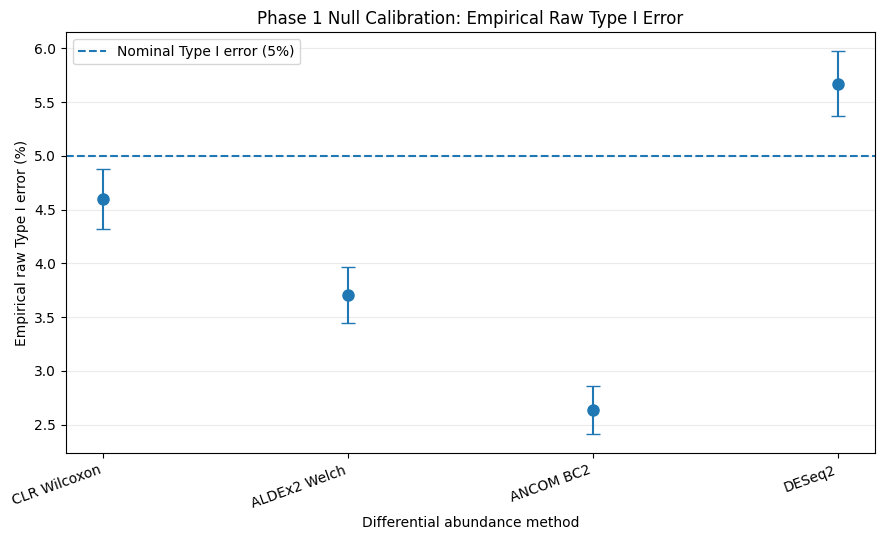

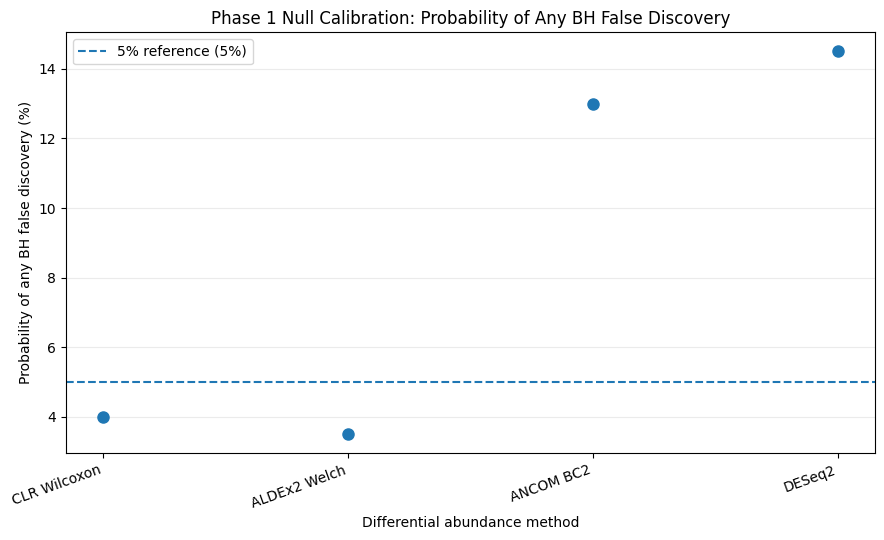

=== CELL 7F COMPLETE ===
Calibration summary loaded from: /content/drive/MyDrive/Microbiome_Group_Project/results/phase1_null_calibration_summary.csv
Figure 1 saved to: /content/drive/MyDrive/Microbiome_Group_Project/results/phase1_raw_type1_error.png
Figure 2 saved to: /content/drive/MyDrive/Microbiome_Group_Project/results/phase1_any_bh_false_discovery.png


In [20]:
# Cell 7F: Visualize Phase 1 Null Calibration Results
# Purpose:
#   1. Read the full-precision Phase 1 calibration summary saved by Cell 7D.
#   2. Plot empirical raw Type I error against the nominal 5% level.
#   3. Plot the probability of any BH false discovery against the 5% level.
#   4. Save both figures to the results directory.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Locate results generated by Cell 7D
results_dir = Path(project_dir) / "results"

summary_path = (
    results_dir /
    "phase1_null_calibration_summary.csv"
)

if not summary_path.exists():
    raise FileNotFoundError(
        "Phase 1 calibration summary was not found. "
        "Run Cell 7D before running Cell 7F."
    )

# 2. Load full-precision calibration statistics
plot_df = pd.read_csv(summary_path)

required_columns = [
    "Method",
    "Mean_Raw_Rejection_Prop",
    "Raw_95CI_Lower",
    "Raw_95CI_Upper",
    "Any_BH_Discovery_Rate"
]

missing_columns = [
    column
    for column in required_columns
    if column not in plot_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns in the Phase 1 "
        f"calibration summary: {missing_columns}"
    )

# 3. Determine nominal significance level
if "Nominal_Alpha" in plot_df.columns:
    alpha = float(
        plot_df["Nominal_Alpha"].iloc[0]
    )
else:
    # Backward-compatible fallback for summaries generated
    # before Nominal_Alpha was added in Cell 7D.
    alpha = 0.05

alpha_percent = alpha * 100

# 4. Prepare plotting values
method_labels = (
    plot_df["Method"]
    .astype(str)
    .str.replace("_", " ", regex=False)
)

x = np.arange(
    len(plot_df)
)

# Convert stored proportions to percentages
raw_type1 = (
    plot_df["Mean_Raw_Rejection_Prop"]
    .to_numpy() *
    100
)

raw_ci_lower = (
    plot_df["Raw_95CI_Lower"]
    .to_numpy() *
    100
)

raw_ci_upper = (
    plot_df["Raw_95CI_Upper"]
    .to_numpy() *
    100
)

any_bh_discovery = (
    plot_df["Any_BH_Discovery_Rate"]
    .to_numpy() *
    100
)

# Convert CI endpoints into distances required by matplotlib
lower_error = (
    raw_type1 -
    raw_ci_lower
)

upper_error = (
    raw_ci_upper -
    raw_type1
)

# Figure 1: Empirical raw Type I error
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.errorbar(
    x,
    raw_type1,
    yerr=[
        lower_error,
        upper_error
    ],
    fmt="o",
    markersize=8,
    capsize=5,
    linewidth=1.5
)

ax.axhline(
    y=alpha_percent,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Nominal Type I error "
        f"({alpha_percent:.0f}%)"
    )
)

ax.set_xticks(x)

ax.set_xticklabels(
    method_labels,
    rotation=20,
    ha="right"
)

ax.set_xlabel(
    "Differential abundance method"
)

ax.set_ylabel(
    "Empirical raw Type I error (%)"
)

ax.set_title(
    "Phase 1 Null Calibration: "
    "Empirical Raw Type I Error"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

figure1_path = (
    results_dir /
    "phase1_raw_type1_error.png"
)

plt.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Figure 2: Probability of any BH false discovery
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.errorbar(
    x,
    any_bh_discovery,
    fmt="o",
    markersize=8
)

ax.axhline(
    y=alpha_percent,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"5% reference "
        f"({alpha_percent:.0f}%)"
    )
)

ax.set_xticks(x)

ax.set_xticklabels(
    method_labels,
    rotation=20,
    ha="right"
)

ax.set_xlabel(
    "Differential abundance method"
)

ax.set_ylabel(
    "Probability of any BH false discovery (%)"
)

ax.set_title(
    "Phase 1 Null Calibration: "
    "Probability of Any BH False Discovery"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

figure2_path = (
    results_dir /
    "phase1_any_bh_false_discovery.png"
)

plt.savefig(
    figure2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Completion summary
print("=== CELL 7F COMPLETE ===")
print(f"Calibration summary loaded from: "f"{summary_path}")
print(f"Figure 1 saved to: "f"{figure1_path}")
print(f"Figure 2 saved to: "f"{figure2_path}")

In [21]:
%%R

# Cell 7G: Diagnose simulations producing BH false discoveries
# Purpose: Identify the individual null simulations in which each differential-abundance
#   method produced at least one BH-adjusted significant result.

# Under the global null, every BH-significant result is false.
# This cell does NOT rerun the simulations.
# It inspects the replicate-level results already generated in cell 7C

library(dplyr)

cat("=== PHASE 1 BH FALSE-DISCOVERY DIAGNOSTIC ===\n\n")

# 1. Confirm the required replicate-level object exists
stopifnot(
    exists("null_calibration_results")
)

required_cols <- c(
    "Simulation",
    "Seed",
    "Method",
    "Success",
    "Taxa_Raw_Tested",
    "Raw_Rejections",
    "Raw_Rejection_Prop",
    "Taxa_BH_Tested",
    "BH_Rejections",
    "BH_Rejection_Prop",
    "Any_BH_Discovery"
)

missing_cols <- setdiff(
    required_cols,
    names(null_calibration_results)
)

if (length(missing_cols) > 0) {
    stop(
        paste(
            "Missing required columns:",
            paste(missing_cols, collapse = ", ")
        )
    )
}

cat("Replicate-level results object verified.\n")
cat("Rows:", nrow(null_calibration_results), "\n\n")

# 2. Extract simulations containing >= 1 BH discovery
bh_positive_runs <- null_calibration_results %>%
    filter(
        Success == TRUE,
        Any_BH_Discovery == TRUE
    ) %>%
    select(
        Simulation,
        Seed,
        Method,
        Taxa_Raw_Tested,
        Raw_Rejections,
        Raw_Rejection_Prop,
        Taxa_BH_Tested,
        BH_Rejections,
        BH_Rejection_Prop
    ) %>%
    arrange(
        Method,
        Simulation
    )

# 3. Count BH-positive simulations by method
bh_positive_summary <- null_calibration_results %>%
    filter(Success == TRUE) %>%
    group_by(Method) %>%
    summarise(
        Successful_Simulations = n(),
        BH_Positive_Simulations = sum(
            Any_BH_Discovery,
            na.rm = TRUE
        ),
        BH_Positive_Percent = 100 *
            mean(
                Any_BH_Discovery,
                na.rm = TRUE
            ),
        Total_BH_Rejections = sum(
            BH_Rejections,
            na.rm = TRUE
        ),
        Max_BH_Rejections_In_One_Run = max(
            BH_Rejections,
            na.rm = TRUE
        ),
        .groups = "drop"
    )

# 4. Display summary
cat("=== BH-POSITIVE SIMULATIONS BY METHOD ===\n\n")

print(
    tibble::as_tibble(bh_positive_summary),
    n = nrow(bh_positive_summary),
    width = Inf
)

cat("\n")

cat(
    "Total BH-positive method/simulation combinations:",
    nrow(bh_positive_runs),
    "\n\n"
)

# 5. Display individual BH-positive runs
cat("=== INDIVIDUAL BH-POSITIVE RUNS ===\n\n")

print(
    tibble::as_tibble(bh_positive_runs),
    n = nrow(bh_positive_runs),
    width = Inf
)

# 6. Save diagnostic tables
dir.create(
    "results",
    showWarnings = FALSE,
    recursive = TRUE
)

write.csv(
    bh_positive_summary,
    "results/phase1_bh_positive_summary.csv",
    row.names = FALSE
)

write.csv(
    bh_positive_runs,
    "results/phase1_bh_positive_runs.csv",
    row.names = FALSE
)

cat("\nDiagnostic files saved:\n")
cat("  results/phase1_bh_positive_summary.csv\n")
cat("  results/phase1_bh_positive_runs.csv\n")


=== PHASE 1 BH FALSE-DISCOVERY DIAGNOSTIC ===

Replicate-level results object verified.
Rows: 800 

=== BH-POSITIVE SIMULATIONS BY METHOD ===

# A tibble: 4 × 6
  Method       Successful_Simulations BH_Positive_Simulations
  <fct>                         <int>                   <int>
1 CLR_Wilcoxon                    200                       8
2 ALDEx2_Welch                    200                       7
3 ANCOM_BC2                       200                      26
4 DESeq2                          200                      29
  BH_Positive_Percent Total_BH_Rejections Max_BH_Rejections_In_One_Run
                <dbl>               <int>                        <int>
1                 4                    10                            2
2                 3.5                   7                            1
3                13                    31                            2
4                14.5                  34                            2

Total BH-positive method/simulation comb

In [22]:
%%R

# Cell 7H: Inspect extreme p-values in BH-positive simulations
# Purpose:
#   1. Reproduce ONLY the method/simulation combinations that produced >= 1 BH discovery in Cell 7G.
#   2. Recover the underlying per-taxon raw p-values and BH-adjusted q-values.#
#   3. Record the minimum raw p-value and minimum BH q-value.
#   4. Verify that the diagnostic rerun reproduces the original BH rejection count from Cell 7G.

# IMPORTANT:
#   This cell does NOT change the Phase 1 results.
#   It is a diagnostic rerun of BH-positive cases only.

suppressPackageStartupMessages({
    library(dplyr)
    library(tibble)
    library(phyloseq)
    library(ALDEx2)
    library(ANCOMBC)
    library(DESeq2)
})

cat("=== PHASE 1 EXTREME P-VALUE DIAGNOSTIC ===\n\n")

# 1. Verify required objects from earlier cells
required_objects <- c(
    "bh_positive_runs",
    "simulate_null_R",
    "SIGNIFICANCE_LEVEL",
    "BASE_SEED_R",
    "ALDEX_MC_SAMPLES"
)

missing_objects <- required_objects[
    !vapply(
        required_objects,
        exists,
        logical(1),
        inherits = TRUE
    )
]

if (length(missing_objects) > 0) {
    stop(
        paste(
            "Missing required objects:",
            paste(missing_objects, collapse = ", ")
        )
    )
}

cat(
    "BH-positive method/simulation combinations to diagnose:",
    nrow(bh_positive_runs),
    "\n\n"
)

# 2. Helper: create one diagnostic summary from p/q vectors
summarize_tail <- function(
    simulation,
    seed,
    method,
    p_values,
    q_values,
    expected_bh
) {

    # Preserve taxon names BEFORE numeric conversion
    p_taxa <- names(p_values)
    q_taxa <- names(q_values)

    p_values <- as.numeric(p_values)
    q_values <- as.numeric(q_values)

    # Fallback labels if taxon names are unavailable
    if (
        is.null(p_taxa) ||
        length(p_taxa) != length(p_values)
    ) {

        p_taxa <- sprintf(
            "Taxon_%03d",
            seq_along(p_values)
        )
    }


    if (
        is.null(q_taxa) ||
        length(q_taxa) != length(q_values)
    ) {

        q_taxa <- sprintf(
            "Taxon_%03d",
            seq_along(q_values)
        )
    }

    # Identify valid p- and q-values
    valid_p <- is.finite(p_values)
    valid_q <- is.finite(q_values)

    # Identify taxon with smallest raw p-value
    if (any(valid_p)) {

        p_index <- which.min(
            replace(
                p_values,
                !valid_p,
                Inf
            )
        )

        min_p <- p_values[p_index]

        min_p_taxon <- p_taxa[p_index]

    } else {

        min_p <- NA_real_
        min_p_taxon <- NA_character_
    }

    # Identify taxon with smallest BH-adjusted q-value
    if (any(valid_q)) {

        q_index <- which.min(
            replace(
                q_values,
                !valid_q,
                Inf
            )
        )

        min_q <- q_values[q_index]

        min_q_taxon <- q_taxa[q_index]

    } else {

        min_q <- NA_real_
        min_q_taxon <- NA_character_
    }

    # Count reproduced BH discoveries
    reproduced_bh <- sum(
        q_values < SIGNIFICANCE_LEVEL,
        na.rm = TRUE
    )

    # Return one diagnostic row
    data.frame(
        Simulation = simulation,
        Seed = seed,
        Method = method,
        Taxa_Raw_Tested = sum(valid_p),
        Taxa_BH_Tested = sum(valid_q),
        Min_Raw_P = min_p,
        Taxon_Min_Raw_P = min_p_taxon,
        Min_BH_Q = min_q,
        Taxon_Min_BH_Q = min_q_taxon,

        Raw_P_Less_0_05 = sum(
            p_values < SIGNIFICANCE_LEVEL,
            na.rm = TRUE
        ),

        Expected_BH_Rejections = expected_bh,
        Reproduced_BH_Rejections = reproduced_bh,

        Reproduces_Cell7G =
            reproduced_bh == expected_bh,

        stringsAsFactors = FALSE
    )
}

# 3. Diagnostic versions of the four methods
diagnose_method <- function(
    method,
    counts_sim,
    meta_sim,
    simulation,
    seed,
    expected_bh
) {

    # Ensure group factor matches Phase 1
    meta_sim$Group <- factor(
        meta_sim$Group,
        levels = c("Control", "Case")
    )

    # CLR + Wilcoxon
    if (method == "CLR_Wilcoxon") {

        log_counts <- log2(
            counts_sim + 1
        )

        clr_counts <- apply(
            log_counts,
            2,
            function(x) {
                x - mean(x)
            }
        )

        p_values <- apply(
            clr_counts,
            1,
            function(x) {

                wilcox.test(
                    x ~ meta_sim$Group,
                    exact = FALSE
                )$p.value
            }
        )

        q_values <- p.adjust(
            p_values,
            method = "BH"
        )

        names(p_values) <- rownames(counts_sim)
        names(q_values) <- rownames(counts_sim)
    }

    # ALDEx2 Welch
    else if (method == "ALDEx2_Welch") {

        # Same deterministic Monte Carlo seed used in Cell 7B
        set.seed(
            BASE_SEED_R +
            100000L +
            simulation
        )

        aldex_out <- ALDEx2::aldex(
            reads = counts_sim,
            conditions = as.character(meta_sim$Group),
            mc.samples = ALDEX_MC_SAMPLES,
            test = "t",
            effect = FALSE,
            verbose = FALSE
        )

        p_values <- as.numeric(
            aldex_out$we.ep
        )

        q_values <- as.numeric(
            aldex_out$we.eBH
        )

        names(p_values) <- rownames(aldex_out)
        names(q_values) <- rownames(aldex_out)
    }

    # ANCOM-BC2
    else if (method == "ANCOM_BC2") {

        set.seed(
            BASE_SEED_R +
            200000L +
            simulation
        )

        ps_sim <- phyloseq::phyloseq(

            phyloseq::otu_table(
                counts_sim,
                taxa_are_rows = TRUE
            ),

            phyloseq::sample_data(
                meta_sim
            )
        )

        ancom_sim <- ANCOMBC::ancombc2(
            data = ps_sim,
            fix_formula = "Group",
            p_adj_method = "BH",
            pseudo_sens = TRUE,
            prv_cut = 0,
            lib_cut = 0,
            alpha = SIGNIFICANCE_LEVEL,
            n_cl = 1,
            verbose = FALSE,
            global = FALSE,
            pairwise = FALSE,
            dunnet = FALSE,
            trend = FALSE
        )

        ancom_res <- ancom_sim$res

        p_col <- grep(
            "^p_Group",
            colnames(ancom_res),
            value = TRUE
        )

        q_col <- grep(
            "^q_Group",
            colnames(ancom_res),
            value = TRUE
        )

        if (
            length(p_col) != 1 ||
            length(q_col) != 1
        ) {

            stop(
                paste(
                    "Could not uniquely identify",
                    "ANCOM-BC2 Group p/q columns."
                )
            )
        }

        p_values <- as.numeric(
            ancom_res[[p_col]]
        )

        q_values <- as.numeric(
            ancom_res[[q_col]]
        )

        names(p_values) <- rownames(ancom_res)
        names(q_values) <- rownames(ancom_res)
    }

    # DESeq2
    else if (method == "DESeq2") {

        dds_sim <- DESeq2::DESeqDataSetFromMatrix(

            countData = counts_sim,

            colData = meta_sim,

            design = ~ Group
        )

        dds_sim <- DESeq2::DESeq(
            dds_sim,
            quiet = TRUE
        )

        deseq_sim <- DESeq2::results(

            dds_sim,

            contrast = c(
                "Group",
                "Case",
                "Control"
            ),

            alpha = SIGNIFICANCE_LEVEL,

            pAdjustMethod = "BH"
        )

        p_values <- as.numeric(
            deseq_sim$pvalue
        )

        q_values <- as.numeric(
            deseq_sim$padj
        )

        names(p_values) <- rownames(deseq_sim)
        names(q_values) <- rownames(deseq_sim)
    }

    else {

        stop(
            paste(
                "Unknown method:",
                method
            )
        )
    }

    # Return diagnostic summary
    summarize_tail(

        simulation = simulation,

        seed = seed,

        method = method,

        p_values = p_values,

        q_values = q_values,

        expected_bh = expected_bh
    )
}

# 4. Reproduce only Cell 7G BH-positive runs
tail_diagnostics <- vector(
    "list",
    nrow(bh_positive_runs)
)

cat("Re-running BH-positive cases...\n\n")


for (i in seq_len(nrow(bh_positive_runs))) {

    diagnostic_row <- bh_positive_runs[i, ]

    sim_id <- as.integer(
        diagnostic_row$Simulation
    )

    sim_seed <- as.integer(
        diagnostic_row$Seed
    )

    method_name <- as.character(
        diagnostic_row$Method
    )

    expected_bh <- as.integer(
        diagnostic_row$BH_Rejections
    )

    # Regenerate exactly the same null dataset
    simulated_data <- simulate_null_R(
        seed = sim_seed
    )

    counts_sim <- simulated_data$counts
    meta_sim <- simulated_data$meta


    # Run the diagnostic version of the relevant method
    tail_diagnostics[[i]] <- diagnose_method(
        method = method_name,
        counts_sim = counts_sim,
        meta_sim = meta_sim,
        simulation = sim_id,
        seed = sim_seed,
        expected_bh = expected_bh
    )

    if (
        i %% 10 == 0 ||
        i == nrow(bh_positive_runs)
    ) {

        cat(
            "Completed",
            i,
            "of",
            nrow(bh_positive_runs),
            "diagnostic reruns\n"
        )
    }
}

tail_diagnostics <- bind_rows(
    tail_diagnostics
)

# 5. Verify reproduction of Cell 7G
cat("\n=== REPRODUCTION CHECK ===\n\n")

reproduction_summary <- tail_diagnostics %>%

    group_by(Method) %>%

    summarise(

        Diagnostic_Runs = n(),

        Reproduced_Correctly = sum(
            Reproduces_Cell7G,
            na.rm = TRUE
        ),

        Mismatched_Runs = sum(
            !Reproduces_Cell7G,
            na.rm = TRUE
        ),

        .groups = "drop"
    )

print(
    reproduction_summary,
    n = nrow(reproduction_summary),
    width = Inf
)

# 6. Summarize extreme p-value behavior by method
cat("\n=== EXTREME P-VALUE SUMMARY ===\n\n")

tail_summary <- tail_diagnostics %>%

    group_by(Method) %>%

    summarise(

        BH_Positive_Runs = n(),

        Median_Min_Raw_P = median(
            Min_Raw_P,
            na.rm = TRUE
        ),

        Smallest_Min_Raw_P = min(
            Min_Raw_P,
            na.rm = TRUE
        ),

        Median_Min_BH_Q = median(
            Min_BH_Q,
            na.rm = TRUE
        ),

        Smallest_Min_BH_Q = min(
            Min_BH_Q,
            na.rm = TRUE
        ),

        .groups = "drop"
    )

print(
    tail_summary,
    n = nrow(tail_summary),
    width = Inf
)

# 7. Show most extreme BH-positive runs
cat("\n=== MOST EXTREME BH-POSITIVE RUNS ===\n\n")

extreme_runs <- tail_diagnostics %>%

    arrange(
        Method,
        Min_Raw_P
    ) %>%

    select(
        Simulation,
        Seed,
        Method,
        Min_Raw_P,
        Taxon_Min_Raw_P,
        Min_BH_Q,
        Taxon_Min_BH_Q,
        Raw_P_Less_0_05,
        Expected_BH_Rejections,
        Reproduced_BH_Rejections,
        Reproduces_Cell7G
    )

print(
    tibble::as_tibble(extreme_runs),
    n = nrow(extreme_runs),
    width = Inf
)

# 8. Save diagnostic results
dir.create(
    "results",
    showWarnings = FALSE,
    recursive = TRUE
)

write.csv(
    tail_diagnostics,
    "results/phase1_bh_tail_diagnostics.csv",
    row.names = FALSE
)

write.csv(
    tail_summary,
    "results/phase1_bh_tail_summary.csv",
    row.names = FALSE
)

write.csv(
    reproduction_summary,
    "results/phase1_bh_tail_reproduction_check.csv",
    row.names = FALSE
)

cat("\nDiagnostic files saved:\n")
cat("  results/phase1_bh_tail_diagnostics.csv\n")
cat("  results/phase1_bh_tail_summary.csv\n")
cat("  results/phase1_bh_tail_reproduction_check.csv\n")
cat("\nCell 7H complete.\n")

=== PHASE 1 EXTREME P-VALUE DIAGNOSTIC ===

BH-positive method/simulation combinations to diagnose: 70 

Re-running BH-positive cases...

Completed 10 of 70 diagnostic reruns
Completed 20 of 70 diagnostic reruns
Completed 30 of 70 diagnostic reruns
Completed 40 of 70 diagnostic reruns
Completed 50 of 70 diagnostic reruns
Completed 60 of 70 diagnostic reruns
Completed 70 of 70 diagnostic reruns

=== REPRODUCTION CHECK ===

# A tibble: 4 × 4
  Method       Diagnostic_Runs Reproduced_Correctly Mismatched_Runs
  <chr>                  <int>                <int>           <int>
1 ALDEx2_Welch               7                    7               0
2 ANCOM_BC2                 26                   26               0
3 CLR_Wilcoxon               8                    8               0
4 DESeq2                    29                   29               0

=== EXTREME P-VALUE SUMMARY ===

# A tibble: 4 × 6
  Method       BH_Positive_Runs Median_Min_Raw_P Smallest_Min_Raw_P
  <chr>                   <i

aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all features
aldex.ttest: doing t-test
aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all features
aldex.ttest: doing t-test
aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all features
aldex.ttest: doing t-test
aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all features
aldex.ttest: doing t-test
aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all features
aldex.ttest: doing t-test
aldex.clr: generating Monte-Carlo instances and clr values
conditions vector supplied
operating in serial mode
computing center with all fea

In [23]:
%%R

# Cell 7I: ANCOM-BC2 pseudo-count robustness audit
# Purpose:
#   1. Re-run ONLY the ANCOM-BC2 simulations that produced >= 1 BH q-value < 0.05 in Phase 1.
#   2. Inspect ANCOM-BC2 pseudo-count sensitivity output.
#   3. Compare ordinary BH significance (q < 0.05) with ANCOM-BC2's robust
#      significance call.
#   4. Determine whether the apparent 13% null false-discovery rate changes when
#      pseudo-count robustness is required.

# IMPORTANT:
#   This is a diagnostic audit.
#   It does not overwrite the original Phase 1 results.

suppressPackageStartupMessages({
    library(dplyr)
    library(tibble)
    library(phyloseq)
    library(ANCOMBC)
})

cat("=== ANCOM-BC2 PSEUDO-COUNT ROBUSTNESS AUDIT ===\n\n")

# 1. Verify required objects
required_objects <- c(
    "bh_positive_runs",
    "simulate_null_R",
    "SIGNIFICANCE_LEVEL",
    "BASE_SEED_R"
)

missing_objects <- required_objects[
    !vapply(
        required_objects,
        exists,
        logical(1),
        inherits = TRUE
    )
]

if (length(missing_objects) > 0) {

    stop(
        paste(
            "Missing required objects:",
            paste(missing_objects, collapse = ", ")
        )
    )
}

# 2. Keep only ANCOM-BC2 BH-positive simulations
ancom_positive_runs <- bh_positive_runs %>%

    filter(
        as.character(Method) == "ANCOM_BC2"
    ) %>%

    arrange(Simulation)

cat(
    "ANCOM-BC2 BH-positive simulations to audit:",
    nrow(ancom_positive_runs),
    "\n"
)

cat(
    "Original ANCOM-BC2 BH discoveries across these runs:",
    sum(ancom_positive_runs$BH_Rejections),
    "\n\n"
)

# 3. Storage objects
ancom_robust_run_list <- vector(
    "list",
    nrow(ancom_positive_runs)
)

ancom_robust_taxon_list <- vector(
    "list",
    nrow(ancom_positive_runs)
)

reported_columns <- FALSE

# 4. Re-run the 26 ANCOM-BC2-positive simulations
for (i in seq_len(nrow(ancom_positive_runs))) {

    run_info <- ancom_positive_runs[i, ]

    sim_id <- as.integer(
        run_info$Simulation
    )

    sim_seed <- as.integer(
        run_info$Seed
    )

    expected_bh <- as.integer(
        run_info$BH_Rejections
    )

    # Regenerate the identical null dataset

    simulated_data <- simulate_null_R(
        seed = sim_seed
    )

    counts_sim <- simulated_data$counts
    meta_sim <- simulated_data$meta

    meta_sim$Group <- factor(
        meta_sim$Group,
        levels = c("Control", "Case")
    )

    # Construct phyloseq object
    ps_sim <- phyloseq::phyloseq(

        phyloseq::otu_table(
            counts_sim,
            taxa_are_rows = TRUE
        ),

        phyloseq::sample_data(
            meta_sim
        )
    )

    # Reproduce ANCOM-BC2 analysis
    set.seed(
        BASE_SEED_R +
        200000 +
        sim_id
    )

    ancom_fit <- ANCOMBC::ancombc2(

        data = ps_sim,
        fix_formula = "Group",
        p_adj_method = "BH",
        pseudo_sens = TRUE,
        prv_cut = 0,
        lib_cut = 0,
        alpha = SIGNIFICANCE_LEVEL,
        n_cl = 1,
        verbose = FALSE,
        global = FALSE,
        pairwise = FALSE,
        dunnet = FALSE,
        trend = FALSE
    )

    ancom_res <- ancom_fit$res

    # Show output structure once
    if (!reported_columns) {

        cat("ANCOM-BC2 result columns detected:\n")
        print(colnames(ancom_res))
        cat("\n")
        reported_columns <- TRUE
    }

    # Identify taxon IDs
    if ("taxon" %in% colnames(ancom_res)) {

        taxon_id <- as.character(
            ancom_res$taxon
        )

    } else {

        taxon_id <- rownames(
            ancom_res
        )
    }

    # Identify Group p- and q-value columns
    p_col <- grep(
        "^p_Group",
        colnames(ancom_res),
        value = TRUE
    )

    q_col <- grep(
        "^q_Group",
        colnames(ancom_res),
        value = TRUE
    )

    if (
        length(p_col) != 1 ||
        length(q_col) != 1
    ) {

        stop(
            paste(
                "Simulation",
                sim_id,
                ": could not uniquely identify Group p/q columns."
            )
        )
    }

    # Identify pseudo-count sensitivity columns
    passed_ss_cols <- grep(
        "passed_ss",
        colnames(ancom_res),
        value = TRUE,
        ignore.case = TRUE
    )

    diff_robust_cols <- grep(
        "diff_robust",
        colnames(ancom_res),
        value = TRUE,
        ignore.case = TRUE
    )

    if (length(passed_ss_cols) == 0) {

        stop(
            paste(
                "Simulation",
                sim_id,
                ": no passed_ss column found. Columns were:",
                paste(
                    colnames(ancom_res),
                    collapse = ", "
                )
            )
        )
    }

    # Prefer a Group-specific column if one exists.
    # Otherwise use the single returned passed_ss column.

    passed_ss_group <- grep(
        "Group",
        passed_ss_cols,
        value = TRUE
    )

    if (length(passed_ss_group) == 1) {

        passed_ss_col <- passed_ss_group

    } else if (length(passed_ss_cols) == 1) {

        passed_ss_col <- passed_ss_cols

    } else {

        stop(
            paste(
                "Simulation",
                sim_id,
                ": could not uniquely select passed_ss column:",
                paste(
                    passed_ss_cols,
                    collapse = ", "
                )
            )
        )
    }

    # Extract values
    p_value <- as.numeric(
        ancom_res[[p_col]]
    )

    q_value <- as.numeric(
        ancom_res[[q_col]]
    )

    passed_ss <- as.logical(
        ancom_res[[passed_ss_col]]
    )

    # Identify robust significance
    if (length(diff_robust_cols) > 0) {

        diff_robust_group <- grep(
            "Group",
            diff_robust_cols,
            value = TRUE
        )

        if (length(diff_robust_group) == 1) {

            diff_robust_col <- diff_robust_group

        } else if (length(diff_robust_cols) == 1) {

            diff_robust_col <- diff_robust_cols

        } else {

            stop(
                paste(
                    "Simulation",
                    sim_id,
                    ": could not uniquely select diff_robust column:",
                    paste(
                        diff_robust_cols,
                        collapse = ", "
                    )
                )
            )
        }

        robust_significant <- as.logical(
            ancom_res[[diff_robust_col]]
        )

    } else {

        # Fallback corresponding to the ANCOM-BC2 message:
        # significant q-value AND passes sensitivity analysis

        robust_significant <-
            !is.na(q_value) &
            q_value < SIGNIFICANCE_LEVEL &
            !is.na(passed_ss) &
            passed_ss

        diff_robust_col <- "derived_from_q_and_passed_ss"
    }

    # Define ordinary BH significance
    bh_significant <-
        !is.na(q_value) &
        q_value < SIGNIFICANCE_LEVEL

    # Taxon-level audit table
    taxon_audit <- data.frame(
        Simulation = sim_id,
        Seed = sim_seed,
        TaxonID = taxon_id,
        p_value = p_value,
        q_value = q_value,
        BH_Significant = bh_significant,
        Passed_Pseudocount_Sensitivity =
            passed_ss,

        Robust_Significant =
            robust_significant,

        stringsAsFactors = FALSE
    )

    # Keep only taxa that were BH-significant, because these are the taxa being audited.
    bh_taxa <- taxon_audit %>%

        filter(
            BH_Significant
        ) %>%

        arrange(
            q_value
        )

    ancom_robust_taxon_list[[i]] <- bh_taxa

    # Run-level summary
    reproduced_bh <- sum(
        bh_significant,
        na.rm = TRUE
    )

    robust_rejections <- sum(
        robust_significant,
        na.rm = TRUE
    )

    ancom_robust_run_list[[i]] <- data.frame(

        Simulation = sim_id,
        Seed = sim_seed,
        Expected_BH_Rejections = expected_bh,
        Reproduced_BH_Rejections = reproduced_bh,
        Reproduces_Cell7G = reproduced_bh == expected_bh,
        BH_Rejections = reproduced_bh,
        BH_Rejections_Passing_SS =
            sum(
                bh_significant &
                passed_ss,
                na.rm = TRUE
            ),

        Robust_Rejections = robust_rejections,

        Any_BH_Discovery = reproduced_bh > 0,

        Any_Robust_Discovery = robust_rejections > 0,

        stringsAsFactors = FALSE
    )


    if (
        i %% 5 == 0 ||
        i == nrow(ancom_positive_runs)
    ) {

        cat(
            "Completed",
            i,
            "of",
            nrow(ancom_positive_runs),
            "ANCOM-BC2 robustness audits\n"
        )
    }
}

# 5. Combine results
ancom_robust_runs <- bind_rows(
    ancom_robust_run_list
)

ancom_robust_taxa <- bind_rows(
    ancom_robust_taxon_list
)

# 6. Reproduction check
cat("\n=== ANCOM-BC2 REPRODUCTION CHECK ===\n\n")

reproduction_check <- data.frame(

    Runs_Audited =
        nrow(ancom_robust_runs),

    Correctly_Reproduced =
        sum(
            ancom_robust_runs$Reproduces_Cell7G
        ),

    Mismatched_Runs =
        sum(
            !ancom_robust_runs$Reproduces_Cell7G
        )
)

print(reproduction_check, row.names = FALSE)

# 7. Main robustness summary
total_bh_rejections <- sum(
    ancom_robust_runs$BH_Rejections
)

total_passed_ss <- sum(
    ancom_robust_runs$BH_Rejections_Passing_SS
)

total_robust_rejections <- sum(
    ancom_robust_runs$Robust_Rejections
)

runs_with_bh <- sum(
    ancom_robust_runs$Any_BH_Discovery
)

runs_with_robust <- sum(
    ancom_robust_runs$Any_Robust_Discovery
)

ancom_robust_summary <- data.frame(

    Total_Phase1_Simulations = 200,

    BH_Positive_Runs =
        runs_with_bh,

    BH_Positive_Percent =
        100 * runs_with_bh / 200,

    Total_BH_Rejections =
        total_bh_rejections,

    BH_Rejections_Passing_SS =
        total_passed_ss,

    Robust_Rejections =
        total_robust_rejections,

    Robust_Positive_Runs =
        runs_with_robust,

    Robust_Positive_Percent =
        100 * runs_with_robust / 200
)

cat("\n=== ANCOM-BC2 ROBUSTNESS SUMMARY ===\n\n")

print(
    tibble::as_tibble(
        ancom_robust_summary
    ),
    width = Inf
)

# 8. Show BH-significant taxa and robustness status
cat("\n=== ANCOM-BC2 BH-SIGNIFICANT TAXA AUDIT ===\n\n")

print(
    tibble::as_tibble(
        ancom_robust_taxa
    ),
    n = nrow(ancom_robust_taxa),
    width = Inf
)

# 9. Show runs where BH and robust conclusions differ
changed_runs <- ancom_robust_runs %>%

    filter(
        BH_Rejections != Robust_Rejections
    ) %>%

    arrange(
        Simulation
    )

cat("\n=== RUNS CHANGED BY PSEUDO-COUNT ROBUSTNESS ===\n\n")

if (nrow(changed_runs) == 0) {

    cat(
        "No ANCOM-BC2 BH-positive runs changed after ",
        "pseudo-count robustness assessment.\n",
        sep = ""
    )

} else {

    print(
        tibble::as_tibble(
            changed_runs
        ),
        n = nrow(changed_runs),
        width = Inf
    )
}

# 10. Save audit tables
dir.create(
    "results",
    showWarnings = FALSE,
    recursive = TRUE
)

write.csv(
    ancom_robust_summary,
    "results/phase1_ancombc2_robustness_summary.csv",
    row.names = FALSE
)

write.csv(
    ancom_robust_runs,
    "results/phase1_ancombc2_robustness_by_run.csv",
    row.names = FALSE
)

write.csv(
    ancom_robust_taxa,
    "results/phase1_ancombc2_bh_taxa_robustness.csv",
    row.names = FALSE
)

write.csv(
    changed_runs,
    "results/phase1_ancombc2_changed_runs.csv",
    row.names = FALSE
)

cat("\nAudit files saved:\n")
cat("  results/phase1_ancombc2_robustness_summary.csv\n")
cat("  results/phase1_ancombc2_robustness_by_run.csv\n")
cat("  results/phase1_ancombc2_bh_taxa_robustness.csv\n")
cat("  results/phase1_ancombc2_changed_runs.csv\n")
cat("\nCell 7I complete.\n")

=== ANCOM-BC2 PSEUDO-COUNT ROBUSTNESS AUDIT ===

ANCOM-BC2 BH-positive simulations to audit: 26 
Original ANCOM-BC2 BH discoveries across these runs: 31 

ANCOM-BC2 result columns detected:
 [1] "taxon"                   "lfc_(Intercept)"        
 [3] "lfc_GroupCase"           "se_(Intercept)"         
 [5] "se_GroupCase"            "W_(Intercept)"          
 [7] "W_GroupCase"             "p_(Intercept)"          
 [9] "p_GroupCase"             "q_(Intercept)"          
[11] "q_GroupCase"             "diff_(Intercept)"       
[13] "diff_GroupCase"          "passed_ss_(Intercept)"  
[15] "passed_ss_GroupCase"     "diff_robust_(Intercept)"
[17] "diff_robust_GroupCase"  

Completed 5 of 26 ANCOM-BC2 robustness audits
Completed 10 of 26 ANCOM-BC2 robustness audits
Completed 15 of 26 ANCOM-BC2 robustness audits
Completed 20 of 26 ANCOM-BC2 robustness audits
Completed 25 of 26 ANCOM-BC2 robustness audits
Completed 26 of 26 ANCOM-BC2 robustness audits

=== ANCOM-BC2 REPRODUCTION CHECK ===

 R

Conducting sensitivity analysis for pseudo-count addition to 0s ...
For taxa that are significant but do not pass the sensitivity analysis,
they are marked in the 'passed_ss' column and will be treated as non-significant in the 'diff_robust' column.
For detailed instructions on performing sensitivity analysis, please refer to the package vignette.
Conducting sensitivity analysis for pseudo-count addition to 0s ...
For taxa that are significant but do not pass the sensitivity analysis,
they are marked in the 'passed_ss' column and will be treated as non-significant in the 'diff_robust' column.
For detailed instructions on performing sensitivity analysis, please refer to the package vignette.
Conducting sensitivity analysis for pseudo-count addition to 0s ...
For taxa that are significant but do not pass the sensitivity analysis,
they are marked in the 'passed_ss' column and will be treated as non-significant in the 'diff_robust' column.
For detailed instructions on performing sensitivit

In [24]:
%%R

# Cell 7J: Final Phase 1 calibration summary
# Purpose:
#   1. Rebuild the Phase 1 summary directly from the replicate-level null-calibration results.
#   2. Use BH-adjusted q < 0.05 as the PRIMARY comparison for all four methods.
#   3. Retain ANCOM-BC2 diff_robust as a SECONDARY pseudo-count robustness diagnostic.
#   4. Align Phase 1 reporting with the Phase 2 BH-based evaluation framework.
#   5. Save a final phase 1 summary table for reporting.

# IMPORTANT:
#   The original BH results are NOT overwritten.
#   ANCOM-BC2 therefore retains:
#       Primary comparison = BH-adjusted q < 0.05
#       Secondary check    = diff_robust / pseudo-count sensitivity

suppressPackageStartupMessages({
    library(dplyr)
    library(tibble)
})

cat("=== FINAL PHASE 1 CALIBRATION SUMMARY ===\n\n")

# 1. Verify required objects
required_objects <- c(
    "null_calibration_results",
    "ancom_robust_summary"
)

missing_objects <- required_objects[
    !vapply(
        required_objects,
        exists,
        logical(1),
        inherits = TRUE
    )
]

if (length(missing_objects) > 0) {

    stop(
        paste(
            "Missing required objects:",
            paste(missing_objects, collapse = ", ")
        )
    )
}

# 2. Recalculate standardized Phase 1 statistics
#    Primary criterion for all methods: BH-adjusted q < 0.05
phase1_standardized <- null_calibration_results %>%

    filter(
        Success == TRUE
    ) %>%

    group_by(Method) %>%

    summarise(

        Simulations = n(),

        Mean_Raw_TypeI =
            mean(
                Raw_Rejection_Prop,
                na.rm = TRUE
            ),

        SD_Raw_TypeI =
            sd(
                Raw_Rejection_Prop,
                na.rm = TRUE
            ),

        SE_Raw_TypeI =
            SD_Raw_TypeI /
            sqrt(Simulations),

        Raw_95CI_Lower =
            Mean_Raw_TypeI -
            1.96 * SE_Raw_TypeI,

        Raw_95CI_Upper =
            Mean_Raw_TypeI +
            1.96 * SE_Raw_TypeI,

        Mean_BH_Rejections =
            mean(
                BH_Rejections,
                na.rm = TRUE
            ),

        Standardized_BH_Positive_Rate =
            mean(
                Any_BH_Discovery,
                na.rm = TRUE
            ),

        .groups = "drop"
    )

# 3. Extract ANCOM-BC2 robust rate from Cell 7I
if (
    !"Robust_Positive_Percent" %in%
    colnames(ancom_robust_summary)
) {

    stop(
        paste(
            "Robust_Positive_Percent was not found",
            "in ancom_robust_summary."
        )
    )
}

ancom_robust_rate <- as.numeric(
    ancom_robust_summary$Robust_Positive_Percent
) / 100


if (
    length(ancom_robust_rate) != 1 ||
    is.na(ancom_robust_rate)
) {

    stop(
        paste(
            "Expected exactly one valid",
            "ANCOM-BC2 robust-positive rate."
        )
    )
}

# 4. Define primary and secondary decision metrics
#    PRIMARY: BH-adjusted q < 0.05 for ALL methods
#    SECONDARY: ANCOM-BC2 diff_robust pseudo-count sensitivity
phase1_final_with_robustness <- phase1_standardized %>%

    mutate(

        # Primary metric is standardized across all methods
        Primary_Any_Discovery_Rate = Standardized_BH_Positive_Rate,

        Primary_Decision_Rule = "BH-adjusted q < 0.05",

        # Secondary ANCOM-BC2-specific robustness diagnostic
        ANCOM_Robust_Sensitivity_Rate =
            if_else(
                as.character(Method) == "ANCOM_BC2",
                ancom_robust_rate,
                NA_real_
            ),

        Secondary_Diagnostic =
            if_else(
                as.character(Method) == "ANCOM_BC2",
                "diff_robust (pseudo-count sensitivity)",
                NA_character_
            )
    )

    # 5. Create report-friendly percentage table
    phase1_final_display <- phase1_final_with_robustness %>%

    transmute(

        Method = as.character(Method),
        Simulations = Simulations,
        Raw_TypeI_Percent =
            round(
                Mean_Raw_TypeI * 100,
                2
            ),

        Raw_95CI_Lower_Percent =
            round(
                Raw_95CI_Lower * 100,
                2
            ),

        Raw_95CI_Upper_Percent =
            round(
                Raw_95CI_Upper * 100,
                2
            ),

        Mean_BH_Discoveries =
            round(
                Mean_BH_Rejections,
                3
            ),

        Standardized_BH_Positive_Percent =
            round(
                Standardized_BH_Positive_Rate * 100,
                2
            ),

        # Retained for compatibility with downstream cells
        Primary_Any_Discovery_Percent =
            round(
                Primary_Any_Discovery_Rate * 100,
                2
            ),

        Primary_Decision_Rule = Primary_Decision_Rule,

        ANCOM_Robust_Sensitivity_Percent =
            round(ANCOM_Robust_Sensitivity_Rate * 100,2),

        Secondary_Diagnostic = Secondary_Diagnostic
    )

# 6. Preserve method order
method_order <- c(
    "CLR_Wilcoxon",
    "ALDEx2_Welch",
    "ANCOM_BC2",
    "DESeq2"
)

phase1_final_display <- phase1_final_display %>%

    mutate(
        Method = factor(
            Method,
            levels = method_order
        )
    ) %>%

    arrange(Method)

# 7. Display final phase 1 comparison table
cat("=== PHASE 1 FINAL COMPARISON TABLE ===\n\n")

print(
    tibble::as_tibble(
        phase1_final_display
    ),
    n = nrow(phase1_final_display),
    width = Inf
)

# 8. Display primary BH comparison
cat("\n=== PRIMARY MULTIPLE-TESTING COMPARISON ===\n\n")

multiple_testing_comparison <- phase1_final_display %>%

    select(
        Method,
        Standardized_BH_Positive_Percent,
        Primary_Decision_Rule
    )

print(
    tibble::as_tibble(
        multiple_testing_comparison
    ),
    n = nrow(multiple_testing_comparison),
    width = Inf
)

# 9. Display ANCOM-BC2 secondary robustness result
cat("\n=== ANCOM-BC2 SECONDARY ROBUSTNESS CHECK ===\n\n")

ancom_robustness_display <- phase1_final_display %>%

    filter(
        as.character(Method) == "ANCOM_BC2"
    ) %>%

select(
        Method,
        Standardized_BH_Positive_Percent,
        ANCOM_Robust_Sensitivity_Percent,
        Secondary_Diagnostic
    )

print(
    tibble::as_tibble(ancom_robustness_display),
    n = nrow(ancom_robustness_display),
    width = Inf
)

# 10. Validation Checks
cat("\n=== VALIDATION CHECKS ===\n\n")

# Primary metric must equal standardized BH metric for every method.
stopifnot(
    all(
        abs(
            phase1_final_display$
                Primary_Any_Discovery_Percent -
            phase1_final_display$
                Standardized_BH_Positive_Percent
        ) < 0.001
    )
)

# All methods must use the same primary BH rule.
stopifnot(
    all(
        phase1_final_display$
            Primary_Decision_Rule ==
        "BH-adjusted q < 0.05"
    )
)

# Verify exactly one ANCOM-BC2 row.
ancom_row <- phase1_final_display %>%

    filter(
        as.character(Method) == "ANCOM_BC2"
    )

stopifnot(
    nrow(ancom_row) == 1
)

# ANCOM robustness result must be available.
stopifnot(
    !is.na(
        ancom_row$
            ANCOM_Robust_Sensitivity_Percent
    )
)

cat(
    "ANCOM-BC2 primary BH-positive rate: ",
    ancom_row$Standardized_BH_Positive_Percent,
    "%\n",
    sep = ""
)

cat(
    "ANCOM-BC2 secondary robust-positive rate: ",
    ancom_row$ANCOM_Robust_Sensitivity_Percent,
    "%\n",
    sep = ""
)

cat(
    "\nPrimary decision rule for ALL methods: ",
    "BH-adjusted q < 0.05\n",
    sep = ""
)

cat("\nValidation checks passed.\n")

#11 Save final summary tables
dir.create(
    "results",
    showWarnings = FALSE,
    recursive = TRUE
)

write.csv(
    phase1_final_display,
    "results/phase1_final_calibration_summary.csv",
    row.names = FALSE
)

write.csv(
    multiple_testing_comparison,
    "results/phase1_primary_BH_comparison.csv",
    row.names = FALSE
)

write.csv(
    ancom_robustness_display,
    "results/phase1_ANCOM_BC2_robustness_check.csv",
    row.names = FALSE
)

cat("\nFinal Phase 1 tables saved:\n")
cat("  results/phase1_final_calibration_summary.csv\n")
cat("  results/phase1_primary_BH_comparison.csv\n")
cat("  results/phase1_ANCOM_BC2_robustness_check.csv\n")
cat("\nCell 7J complete.\n")

=== FINAL PHASE 1 CALIBRATION SUMMARY ===

=== PHASE 1 FINAL COMPARISON TABLE ===

# A tibble: 4 × 11
  Method       Simulations Raw_TypeI_Percent Raw_95CI_Lower_Percent
  <fct>              <int>             <dbl>                  <dbl>
1 CLR_Wilcoxon         200              4.6                    4.32
2 ALDEx2_Welch         200              3.7                    3.45
3 ANCOM_BC2            200              2.64                   2.41
4 DESeq2               200              5.67                   5.37
  Raw_95CI_Upper_Percent Mean_BH_Discoveries Standardized_BH_Positive_Percent
                   <dbl>               <dbl>                            <dbl>
1                   4.88               0.05                               4  
2                   3.96               0.035                              3.5
3                   2.86               0.155                             13  
4                   5.97               0.17                              14.5
  Primary_Any_Discover

=== PHASE 1 FINAL VISUALIZATION AND COMPLETION CHECK ===

Validated Phase 1 summary table detected: 4 methods

Plotting table created successfully.


=== ANCOM-BC2 SECONDARY ROBUSTNESS DIAGNOSTIC ===

# A tibble: 1 × 4
  Method    Standardized_BH_Positive_Percent Robust_Sensitivity_Percent
  <fct>                                <dbl>                      <dbl>
1 ANCOM-BC2                               13                        0.5
  Interpretation                                                  
  <chr>                                                           
1 BH q < 0.05 = primary; diff_robust = secondary sensitivity check

Final figures saved successfully.

=== FINAL PHASE 1 CONSISTENCY CHECK ===

# A tibble: 4 × 5
  Method       Raw_TypeI_Percent Standardized_BH_Percent
  <chr>                    <dbl>                   <dbl>
1 CLR_Wilcoxon              4.6                      4  
2 ALDEx2_Welch              3.7                      3.5
3 ANCOM_BC2                 2.64         

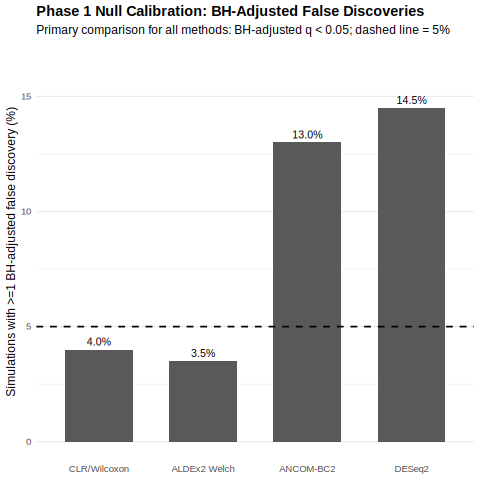

In [25]:
%%R

# Cell 7K: Final Phase 1 figures and completion checkpoint
# Purpose:
#   1. Use the validated Phase 1 summary from Cell 7J.
#   2. Create final Phase 1 figures.
#   3. Use BH-adjusted q < 0.05 as the PRIMARY multiple-testing comparison for all four methods.
#   4. Keep ANCOM-BC2 diff_robust as a SECONDARY pseudo-count robustness diagnostic.
#   5. Save final figures and confirm Phase 1 consistency.

# No new simulations are performed here.

suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(tibble)
})

cat("=== PHASE 1 FINAL VISUALIZATION AND COMPLETION CHECK ===\n\n")

# 1. Verify Cell 7J ouput
if (!exists("phase1_final_display")) {

    stop("phase1_final_display was not found. Run Cell 7J first.")
}

required_columns <- c(
    "Method",
    "Simulations",
    "Raw_TypeI_Percent",
    "Raw_95CI_Lower_Percent",
    "Raw_95CI_Upper_Percent",
    "Mean_BH_Discoveries",
    "Standardized_BH_Positive_Percent",
    "Primary_Any_Discovery_Percent",
    "Primary_Decision_Rule",
    "ANCOM_Robust_Sensitivity_Percent",
    "Secondary_Diagnostic"
)

missing_columns <- setdiff(
    required_columns,
    colnames(phase1_final_display)
)

if (length(missing_columns) > 0) {

    stop(
        paste("Missing required columns:",
            paste(missing_columns,collapse = ", ")
        )
    )
}

cat(
    "Validated Phase 1 summary table detected: ",
    nrow(phase1_final_display),
    " methods\n\n",
    sep = ""
)

# 2. DEFINE METHOD ORDER AND DISPLAY LABELS
method_order <- c(
    "CLR_Wilcoxon",
    "ALDEx2_Welch",
    "ANCOM_BC2",
    "DESeq2"
)

method_labels <- c(
    "CLR_Wilcoxon" = "CLR/Wilcoxon",
    "ALDEx2_Welch" = "ALDEx2 Welch",
    "ANCOM_BC2" = "ANCOM-BC2",
    "DESeq2" = "DESeq2"
)

observed_methods <- as.character(phase1_final_display$Method)

if (!setequal(observed_methods, method_order)) {

    stop(
        paste("Unexpected method set detected.","Expected:",
            paste(method_order,collapse = ", ")
        )
    )
}

# 3. Build final plotting table
plot_table <- phase1_final_display %>%

    mutate(
        Method = as.character(Method),

        Method_Label =
            unname(
                method_labels[Method]
            ),

        Method_Label =
            factor(
                Method_Label,
                levels =
                    unname(
                        method_labels[
                            method_order
                        ]
                    )
            ),

        Raw_TypeI_Percent = as.numeric(Raw_TypeI_Percent),

        Raw_95CI_Lower_Percent = as.numeric(Raw_95CI_Lower_Percent),

        Raw_95CI_Upper_Percent = as.numeric(Raw_95CI_Upper_Percent),

        Standardized_BH_Positive_Percent = as.numeric(Standardized_BH_Positive_Percent),

        Primary_Any_Discovery_Percent = as.numeric(Primary_Any_Discovery_Percent),

        ANCOM_Robust_Sensitivity_Percent = as.numeric(ANCOM_Robust_Sensitivity_Percent)

    ) %>%

    arrange(
        factor(Method,levels = method_order)
    )

stopifnot(
    nrow(plot_table) == 4
)

cat("Plotting table created successfully.\n\n")

# 4. FIGURE 1: Empirical raw Type I error
raw_upper_limit <- max(
    c(
        5,
        plot_table$Raw_95CI_Upper_Percent
    ),
    na.rm = TRUE
) + 1

raw_type1_plot <- ggplot(
    data = plot_table,
    aes(
        x = Method_Label,
        y = Raw_TypeI_Percent
    )
) +

    geom_col(
        width = 0.65
    ) +

    geom_errorbar(
        aes(
            ymin = Raw_95CI_Lower_Percent,
            ymax = Raw_95CI_Upper_Percent
        ),
        width = 0.15
    ) +

    geom_hline(
        yintercept = 5,
        linetype = "dashed",
        linewidth = 0.8
    ) +

    geom_text(
        aes(
            label = sprintf(
                "%.2f%%",
                Raw_TypeI_Percent
            )
        ),
        vjust = -1.2,
        size = 3.7
    ) +

    labs(
        title = "Phase 1 Null Calibration: Empirical Raw Type I Error",

        subtitle =
            paste(
                "200 global-null simulations;",
                "dashed line = nominal 5% level"
            ),

        x = NULL,
        y = "Empirical raw Type I error (%)") +

    coord_cartesian(
        ylim = c(0,raw_upper_limit)
    ) +

    theme_minimal(base_size = 12
    ) +

    theme(
        panel.grid.major.x = element_blank(),

        plot.title =
            element_text(
                face = "bold"
            )
    )

print(raw_type1_plot)

# 5. FIGURE 2: Standardized BH-positive rate
#    This is the PRIMARY cross-method comparison.
#    All four methods use BH-adjusted q < 0.05.
bh_upper_limit <- max(
    c(
        5,
        plot_table$
            Standardized_BH_Positive_Percent
    ),
    na.rm = TRUE
) + 2

bh_plot <- ggplot(
    data = plot_table,
    aes(
        x = Method_Label,
        y = Standardized_BH_Positive_Percent
    )
) +

    geom_col(
        width = 0.65
    ) +

    geom_hline(
        yintercept = 5,
        linetype = "dashed",
        linewidth = 0.8
    ) +

    geom_text(
        aes(
            label = sprintf(
                "%.1f%%",
                Standardized_BH_Positive_Percent
            )
        ),
        vjust = -0.5,
        size = 3.7
    ) +

    labs(
        title =
            paste(
                "Phase 1 Null Calibration:",
                "BH-Adjusted False Discoveries"
            ),

        subtitle =
            paste(
                "Primary comparison for all methods:",
                "BH-adjusted q < 0.05;",
                "dashed line = 5%"
            ),

        x = NULL,
        y =
            paste(
                "Simulations with >=1",
                "BH-adjusted false discovery (%)"
            )
    ) +

    coord_cartesian(
        ylim = c(
            0,
            bh_upper_limit
        )
    ) +

    theme_minimal(
        base_size = 12
    ) +

    theme(
        panel.grid.major.x =
            element_blank(),

        plot.title =
            element_text(
                face = "bold"
            )
    )

print(bh_plot)

# 6. ANCOM-BC2 SECONDARY ROBUSTNESS DIAGNOSTIC
ancom_diagnostic <- plot_table %>%

    filter(
        Method == "ANCOM_BC2"
    ) %>%

    transmute(
        Method = Method_Label,

        Standardized_BH_Positive_Percent = Standardized_BH_Positive_Percent,

        Robust_Sensitivity_Percent = ANCOM_Robust_Sensitivity_Percent,

        Interpretation =
            paste(
                "BH q < 0.05 = primary;",
                "diff_robust = secondary sensitivity check"
            )
    )

if (nrow(ancom_diagnostic) != 1) {
    stop("Expected exactly one ANCOM-BC2 row.")}

if (
    is.na(
        ancom_diagnostic$
            Robust_Sensitivity_Percent
    )
) {

    stop(
        paste(
            "ANCOM-BC2 robustness result",
            "is missing."
        )
    )
}

cat("\n=== ANCOM-BC2 SECONDARY ROBUSTNESS DIAGNOSTIC ===\n\n")

print(
    tibble::as_tibble(
        ancom_diagnostic
    ),
    width = Inf
)

# 7. Save final phase 1 figures
dir.create(
    "results",
    showWarnings = FALSE,
    recursive = TRUE
)

ggsave(
    filename = "results/phase1_final_raw_type1_error.png",
    plot = raw_type1_plot,
    width = 8,
    height = 5,
    dpi = 300
)

ggsave(
    filename = "results/phase1_final_BH_false_discovery.png",
    plot = bh_plot,
    width = 9,
    height = 5.5,
    dpi = 300
)

cat("\nFinal figures saved successfully.\n")

# 8. Final numerical consistency table
final_check <- plot_table %>%

    transmute(
        Method = Method,
        Raw_TypeI_Percent = Raw_TypeI_Percent,
        Standardized_BH_Percent = Standardized_BH_Positive_Percent,
        Primary_Discovery_Percent = Primary_Any_Discovery_Percent,
        ANCOM_Robust_Sensitivity_Percent = ANCOM_Robust_Sensitivity_Percent
    )

cat("\n=== FINAL PHASE 1 CONSISTENCY CHECK ===\n\n")

print(
    tibble::as_tibble(
        final_check
    ),
    n = nrow(final_check),
    width = Inf
)

# 9. Validate checks
# Every method must use standardized BH as its primary cross-method metric.
stopifnot(
    all(
        abs(
            final_check$
                Standardized_BH_Percent -
            final_check$
                Primary_Discovery_Percent
        ) < 0.001
    )
)

# Every method must have the same primary rule.
stopifnot(
    all(
        phase1_final_display$
            Primary_Decision_Rule ==
        "BH-adjusted q < 0.05"
    )
)

# Raw Type I error values should be valid proportions
# expressed as percentages.
stopifnot(
    all(
        final_check$
            Raw_TypeI_Percent >= 0 &
        final_check$
            Raw_TypeI_Percent <= 100
    )
)

# BH-positive percentages should also be valid.
stopifnot(
    all(
        final_check$
            Standardized_BH_Percent >= 0 &
        final_check$
            Standardized_BH_Percent <= 100
    )
)

cat("\nAll Phase 1 consistency checks passed.\n")

# 10. Final completion summary
cat("\n============================================================\n")
cat("PHASE 1 NULL CALIBRATION COMPLETE\n")
cat("============================================================\n\n")
cat(
    "Simulations: ",
    unique(phase1_final_display$Simulations),
    " global-null datasets\n",
    sep = ""
)

cat(
    "Methods: CLR/Wilcoxon, ALDEx2 Welch, ",
    "ANCOM-BC2, DESeq2\n",
    sep = ""
)

cat("True differentially abundant taxa: 0\n\n")

cat(
    "Primary cross-method decision rule:\n",
    "  BH-adjusted q < 0.05 for all four methods\n\n",
    sep = ""
)

cat("Raw Type I error:\n")

for (i in seq_len(nrow(plot_table))) {

    cat(
        "  ",
        as.character(
            plot_table$Method_Label[i]
        ),
        ": ",
        sprintf(
            "%.2f%%",
            plot_table$
                Raw_TypeI_Percent[i]
        ),
        "\n",
        sep = ""
    )
}

cat("\nStandardized BH-positive rate:\n")

for (i in seq_len(nrow(plot_table))) {

    cat(
        "  ",
        as.character(
            plot_table$Method_Label[i]
        ),
        ": ",
        sprintf(
            "%.1f%%",
            plot_table$
                Standardized_BH_Positive_Percent[i]
        ),
        "\n",
        sep = ""
    )
}

cat("\nANCOM-BC2 secondary robustness check:\n")

cat(
    "  Standardized BH-positive rate: ",
    sprintf(
        "%.1f%%",
        ancom_diagnostic$
            Standardized_BH_Positive_Percent
    ),
    "\n",
    sep = ""
)

cat(
    "  diff_robust sensitivity rate: ",
    sprintf(
        "%.1f%%",
        ancom_diagnostic$
            Robust_Sensitivity_Percent
    ),
    "\n\n",
    sep = ""
)

cat(
    "Final figures saved:\n",
    "  results/phase1_final_raw_type1_error.png\n",
    "  results/phase1_final_BH_false_discovery.png\n\n",
    sep = ""
)

cat(
    "Phase 1 analysis is complete and aligned ",
    "with the Phase 2 BH-based evaluation framework.\n",
    sep = ""
)

# Phase 2 — Signal Simulation and Power Analysis

In [ ]:
# Phase 2 — Signal Simulation and Power Analysis

# Objective
# Evaluate the performance of the differential abundance methods when true differential taxa are present.
# Phase 1 evaluated false-positive behavior under the global null.
# Phase 2 introduces known biological signal so that sensitivity, power, false discovery
#    behavior, and effect-size recovery can be evaluated.

In [26]:
%%R

# Cell 8A — Phase 2 configuration + signal simulation helper
# Phase 2 configuration

# Preserve Phase 1 simulation design
N_SIMULATIONS_PHASE2 <- N_SIMULATIONS

# Proportion of taxa intentionally assigned true DA signal
DA_PROPORTION_R <- 0.10

# Signal strengths to evaluate in Phase 2
# 1.5x = weak, 2x = moderate, 4x = strong
SIGNAL_FC_LEVELS_R <- c(1.5, 2.0, 4.0)

# Separate reproducible seed sequence for Phase 2
PHASE2_BASE_SEED_R <- BASE_SEED_R + 10000L

# Signal simulation function
simulate_signal_R <- function(
    seed,
    fold_change = 2.0,
    da_proportion = DA_PROPORTION_R,
    n_samples = N_SAMPLES_R,
    n_taxa = N_TAXA_R,
    sequencing_depth = SEQUENCING_DEPTH_R,
    alpha_low = ALPHA_LOW_R,
    alpha_high = ALPHA_HIGH_R
) {

   # Basic validation
   stopifnot(
    n_samples %% 2 == 0,
    n_taxa >= 2,
    sequencing_depth > 0,
    fold_change > 1,
    da_proportion > 0,
    da_proportion < 1
  )

  set.seed(seed)

  n_per_group <- n_samples / 2L

  taxa_ids <- sprintf("Taxon_%03d", seq_len(n_taxa))
  sample_ids <- sprintf("Sample_%03d", seq_len(n_samples))

  group <- factor(
    c(
      rep("Control", n_per_group),
      rep("Case", n_per_group)
    ),
    levels = c("Control", "Case")
  )

  # Generate baseline microbial composition
  base_alpha <- runif(
    n_taxa,
    min = alpha_low,
    max = alpha_high
  )

  base_mean <- base_alpha / sum(base_alpha)

  # Preserve the same total Dirichlet concentration
  # between Control and Case groups.
  total_concentration <- sum(base_alpha)

  # Select true DA taxa
  n_da <- as.integer(round(n_taxa * da_proportion))

  # Require at least two DA taxa
  n_da <- max(2L, n_da)

  # Make number of DA taxa even so that half can increase
  # and half can decrease.
  if (n_da %% 2 != 0) {
    n_da <- n_da + 1L
  }

  n_da <- min(n_da, n_taxa)

  da_idx <- sample(
    seq_len(n_taxa),
    size = n_da,
    replace = FALSE
  )

  n_up <- n_da / 2L

  up_idx <- da_idx[seq_len(n_up)]
  down_idx <- da_idx[(n_up + 1L):n_da]

  # Apply known signal
  signal_multiplier <- rep(1, n_taxa)

  # Increased abundance in Case
  signal_multiplier[up_idx] <- fold_change

  # Decreased abundance in Case
  signal_multiplier[down_idx] <- 1 / fold_change

  case_mean_raw <- base_mean * signal_multiplier

  # Renormalize to a valid composition
  case_mean <- case_mean_raw / sum(case_mean_raw)

  # Keep total concentration identical across groups
  alpha_control <- base_mean * total_concentration
  alpha_case <- case_mean * total_concentration

  # Helper to generate one multinomial sample
  draw_sample <- function(alpha_vector) {

    dirichlet_draw <- rgamma(
      length(alpha_vector),
      shape = alpha_vector,
      rate = 1
    )

    relative_abundance <-
      dirichlet_draw / sum(dirichlet_draw)

    as.integer(
      rmultinom(
        n = 1,
        size = sequencing_depth,
        prob = relative_abundance
      )[, 1]
    )
  }

  # Generate Control and Case samples
  counts <- sapply(
    seq_len(n_samples),
    function(i) {

      if (group[i] == "Control") {
        draw_sample(alpha_control)
      } else {
        draw_sample(alpha_case)
      }

    }
  )

  rownames(counts) <- taxa_ids
  colnames(counts) <- sample_ids

  counts_df <- as.data.frame(
    counts,
    check.names = FALSE
  )

  # Metadata
  metadata_df <- data.frame(
    Group = group,
    row.names = sample_ids
  )

  # Ground-truth table
  true_da <- rep(FALSE, n_taxa)
  true_da[da_idx] <- TRUE

  direction <- rep("Null", n_taxa)
  direction[up_idx] <- "Up"
  direction[down_idx] <- "Down"

  intended_log2fc <- rep(0, n_taxa)
  intended_log2fc[up_idx] <- log2(fold_change)
  intended_log2fc[down_idx] <- -log2(fold_change)

  truth_df <- data.frame(
    True_DA = true_da,
    Direction = direction,
    Signal_Multiplier = signal_multiplier,
    Intended_Log2FC = intended_log2fc,
    Base_Mean = base_mean,
    Case_Mean = case_mean,
    row.names = taxa_ids
  )

 # Return complete simulated dataset
 return(
    list(
      counts = counts_df,
      metadata = metadata_df,
      truth = truth_df,
      alpha_control = alpha_control,
      alpha_case = alpha_case,
      fold_change = fold_change,
      n_true_da = n_da
    )
  )
}

# Smoke test: generate one moderate-signal dataset
phase2_example <- simulate_signal_R(
  seed = PHASE2_BASE_SEED_R,
  fold_change = 2.0
)

# Validation checks
stopifnot(
  nrow(phase2_example$counts) == N_TAXA_R,
  ncol(phase2_example$counts) == N_SAMPLES_R,

  all(
    colSums(phase2_example$counts) ==
      SEQUENCING_DEPTH_R
  ),

  sum(phase2_example$truth$True_DA) ==
    phase2_example$n_true_da,

  sum(
    phase2_example$truth$Direction == "Up"
  ) ==
    phase2_example$n_true_da / 2,

  sum(
    phase2_example$truth$Direction == "Down"
  ) ==
    phase2_example$n_true_da / 2
)

# Display simulation configuration
cat("Phase 2 signal simulator initialized successfully.\n\n")

cat("Samples:", N_SAMPLES_R, "\n")
cat("Control:", N_SAMPLES_R / 2, "\n")
cat("Case:", N_SAMPLES_R / 2, "\n")
cat("Taxa:", N_TAXA_R, "\n")
cat("Sequencing depth:", SEQUENCING_DEPTH_R, "\n")
cat("True DA proportion:", DA_PROPORTION_R, "\n")
cat("True DA taxa:", phase2_example$n_true_da, "\n")
cat(
  "Signal levels:",
  paste(SIGNAL_FC_LEVELS_R, collapse = ", "),
  "\n"
)

cat("\nDirection of true signals:\n")
print(table(phase2_example$truth$Direction))

cat("\nExample true DA taxa:\n")
print(
  phase2_example$truth[
    phase2_example$truth$True_DA,
    c(
      "True_DA",
      "Direction",
      "Signal_Multiplier",
      "Intended_Log2FC"
    )
  ]
)

Phase 2 signal simulator initialized successfully.

Samples: 50 
Control: 25 
Case: 25 
Taxa: 100 
Sequencing depth: 10000 
True DA proportion: 0.1 
True DA taxa: 10 
Signal levels: 1.5, 2, 4 

Direction of true signals:

Down Null   Up 
   5   90    5 

Example true DA taxa:
          True_DA Direction Signal_Multiplier Intended_Log2FC
Taxon_004    TRUE      Down               0.5              -1
Taxon_011    TRUE      Down               0.5              -1
Taxon_031    TRUE      Down               0.5              -1
Taxon_032    TRUE        Up               2.0               1
Taxon_047    TRUE        Up               2.0               1
Taxon_054    TRUE      Down               0.5              -1
Taxon_058    TRUE        Up               2.0               1
Taxon_062    TRUE      Down               0.5              -1
Taxon_064    TRUE        Up               2.0               1
Taxon_087    TRUE        Up               2.0               1


In [28]:
%%R

# Cell 8B — Validate planted Phase 2 signal
# Purpose:
#   1. Confirm dimensions, group balance, and sequencing depth.
#   2. Calculate mean relative abundance in Control and Case.
#   3. Compare observed Case-vs-Control fold change with the known ground truth created in Cell 8A.
#   4. Confirm that the planted Up and Down taxa generally move in the intended direction.

# No differential-abundance method is run in this cell.

# 1. Extract example dataset created in Cell 8A
counts_8B <- as.matrix(
  phase2_example$counts
)

metadata_8B <- phase2_example$metadata

truth_8B <- phase2_example$truth

# Ensure group order is consistent throughout Phase 2
metadata_8B$Group <- factor(
  metadata_8B$Group,
  levels = c(
    "Control",
    "Case"
  )
)

# 2. Basic dataset validation
cat("=== PHASE 2 SIGNAL VALIDATION ===\n\n")

cat(
  "Count matrix:",
  nrow(counts_8B),
  "taxa x",
  ncol(counts_8B),
  "samples\n"
)

cat("\nSamples per group:\n")
print(
  table(metadata_8B$Group)
)

cat("\nSequencing depth:\n")

sample_depths_8B <- colSums(
  counts_8B
)

cat(
  "Minimum:",
  min(sample_depths_8B),
  "\n"
)

cat(
  "Maximum:",
  max(sample_depths_8B),
  "\n"
)

cat(
  "Mean:",
  mean(sample_depths_8B),
  "\n"
)

# 3. Confirm ground-truth structure
cat("\nGround-truth categories:\n")

print(
  table(truth_8B$Direction)
)

cat(
  "\nTotal true DA taxa:",
  sum(truth_8B$True_DA),
  "\n"
)

# 4. Convert counts to relative abundance
relative_abundance_8B <- sweep(
  counts_8B,
  2,
  colSums(counts_8B),
  FUN = "/"
)

# Identify Control and Case samples
control_samples_8B <-
  metadata_8B$Group == "Control"

case_samples_8B <-
  metadata_8B$Group == "Case"


# Mean relative abundance by group
control_mean_8B <- rowMeans(
  relative_abundance_8B[
    ,
    control_samples_8B,
    drop = FALSE
  ]
)

case_mean_8B <- rowMeans(
  relative_abundance_8B[
    ,
    case_samples_8B,
    drop = FALSE
  ]
)

# 5. Calculate observed Case vs Control log2 fold change
# Very small constant protects against division by zero
epsilon_8B <- 1e-12

observed_log2fc_8B <- log2(
  (case_mean_8B + epsilon_8B) /
    (control_mean_8B + epsilon_8B)
)

# 6. Build validation table
phase2_signal_check_8B <- data.frame(

  Taxon = rownames(counts_8B),

  True_DA = truth_8B$True_DA,

  Direction = truth_8B$Direction,

  Signal_Multiplier = truth_8B$Signal_Multiplier,

  Intended_Log2FC = truth_8B$Intended_Log2FC,

  Control_Mean_RelAbund = control_mean_8B,

  Case_Mean_RelAbund = case_mean_8B,

  Observed_Log2FC = observed_log2fc_8B,

  stringsAsFactors = FALSE
)

# 7. Determine whether observed direction agrees with truth
phase2_signal_check_8B$Observed_Direction <-
  ifelse(
    phase2_signal_check_8B$Observed_Log2FC > 0,
    "Up",
    ifelse(
      phase2_signal_check_8B$Observed_Log2FC < 0,
      "Down",
      "No_change"
    )
  )

phase2_signal_check_8B$Direction_Match <-
  ifelse(

    phase2_signal_check_8B$Direction == "Up",

    phase2_signal_check_8B$Observed_Log2FC > 0,

    ifelse(

      phase2_signal_check_8B$Direction == "Down",

      phase2_signal_check_8B$Observed_Log2FC < 0,

      NA
    )
  )

# 8. Display only the 10 true DA taxa
phase2_true_da_check_8B <-
  phase2_signal_check_8B[
    phase2_signal_check_8B$True_DA,
    c(
      "Taxon",
      "Direction",
      "Signal_Multiplier",
      "Intended_Log2FC",
      "Control_Mean_RelAbund",
      "Case_Mean_RelAbund",
      "Observed_Log2FC",
      "Observed_Direction",
      "Direction_Match"
    )
  ]

phase2_true_da_check_8B <-
  phase2_true_da_check_8B[
    order(
      phase2_true_da_check_8B$Direction,
      phase2_true_da_check_8B$Taxon
    ),
  ]

cat("\n=== TRUE DA TAXA: EXPECTED VS OBSERVED ===\n\n")

print(
  phase2_true_da_check_8B,
  row.names = FALSE,
  digits = 4
)

# 9. Direction-agreement summary
n_true_da_8B <-
  nrow(phase2_true_da_check_8B)

n_direction_match_8B <-
  sum(
    phase2_true_da_check_8B$Direction_Match,
    na.rm = TRUE
  )

cat("\n=== SIGNAL DIRECTION CHECK ===\n")

cat(
  "True DA taxa:",
  n_true_da_8B,
  "\n"
)

cat(
  "Observed in intended direction:",
  n_direction_match_8B,
  "of",
  n_true_da_8B,
  "\n"
)

cat(
  sprintf(
    "Direction agreement: %.1f%%\n",
    100 *
      n_direction_match_8B /
      n_true_da_8B
  )
)

# 10. Separate Up and Down summaries
cat("\nMean observed log2 fold change by planted direction:\n")

direction_summary_8B <-
  aggregate(
    Observed_Log2FC ~ Direction,
    data =
      phase2_signal_check_8B[
        phase2_signal_check_8B$True_DA,
      ],
    FUN = mean
  )

print(
  direction_summary_8B,
  row.names = FALSE
)

# 11. Diagnostic warning only
# Because these data are stochastic, a rare taxon could
# occasionally move opposite to the intended direction.
# Therefore this is a warning rather than a hard stop.

if (
  n_direction_match_8B <
    n_true_da_8B
) {

  warning(
    paste(
      n_true_da_8B -
        n_direction_match_8B,
      "true DA taxa did not show the intended",
      "observed direction in this realization."
    )
  )

} else {

  cat(
    "\nAll planted DA taxa moved in the intended direction.\n"
  )
}

cat("\nCell 8B completed successfully.\n")

=== PHASE 2 SIGNAL VALIDATION ===

Count matrix: 100 taxa x 50 samples

Samples per group:

Control    Case 
     25      25 

Sequencing depth:
Minimum: 10000 
Maximum: 10000 
Mean: 10000 

Ground-truth categories:

Down Null   Up 
   5   90    5 

Total true DA taxa: 10 

=== TRUE DA TAXA: EXPECTED VS OBSERVED ===

     Taxon Direction Signal_Multiplier Intended_Log2FC Control_Mean_RelAbund
 Taxon_004      Down               0.5              -1              0.020364
 Taxon_011      Down               0.5              -1              0.016068
 Taxon_031      Down               0.5              -1              0.005244
 Taxon_054      Down               0.5              -1              0.004288
 Taxon_062      Down               0.5              -1              0.014972
 Taxon_032        Up               2.0               1              0.008860
 Taxon_047        Up               2.0               1              0.002712
 Taxon_058        Up               2.0               1           

In [30]:
%%R

# Cell 8C — Run four DA methods on one Phase 2 signal dataset
# Purpose:
#   1. Run CLR + Wilcoxon, ALDEx2 Welch, ANCOM-BC2, and DESeq2 on the SAME 2x signal
#      dataset validated in Cell 8B.
#   2. Standardize each method to:
#         Taxon
#         P_Value
#         Q_Value
#   3. Compare raw and BH-adjusted discovery counts.

# Ground truth is NOT used for scoring in this cell.
# TP / FP / FN / TN evaluation will be performed in Cell 8D.

# 1. Prepare shared inputs
counts_8C <- as.matrix(
  phase2_example$counts
)

mode(counts_8C) <- "integer"

metadata_8C <- phase2_example$metadata

metadata_8C$Group <- factor(
  metadata_8C$Group,
  levels = c(
    "Control",
    "Case"
  )
)

alpha_8C <- SIGNIFICANCE_LEVEL
seed_8C <- PHASE2_BASE_SEED_R


# Confirm sample alignment
stopifnot(
  identical(
    colnames(counts_8C),
    rownames(metadata_8C)
  )
)

cat("=== PHASE 2 SINGLE-DATASET METHOD CHECK ===\n\n")

cat(
  "Dataset:",
  nrow(counts_8C),
  "taxa x",
  ncol(counts_8C),
  "samples\n"
)

cat(
  "Signal strength:",
  phase2_example$fold_change,
  "x\n"
)

cat(
  "Significance threshold:",
  alpha_8C,
  "\n\n"
)

# 2. METHOD 1 — CLR + Wilcoxon
# Match Phase 1 transformation:
# log2(count + 1), then CLR within each sample
log_counts_8C <- log2(
  counts_8C + 1
)

clr_counts_8C <- apply(
  log_counts_8C,
  2,
  function(x) {
    x - mean(x)
  }
)

rownames(clr_counts_8C) <-
  rownames(counts_8C)

colnames(clr_counts_8C) <-
  colnames(counts_8C)


clr_p_8C <- apply(
  clr_counts_8C,
  1,
  function(x) {

    tryCatch(

      stats::wilcox.test(
        x ~ metadata_8C$Group,
        exact = FALSE
      )$p.value,

      error = function(e) {
        NA_real_
      }
    )
  }
)

clr_q_8C <- stats::p.adjust(
  clr_p_8C,
  method = "BH"
)


clr_results_8C <- data.frame(
  Taxon = rownames(counts_8C),
  Method = "CLR_Wilcoxon",
  P_Value = as.numeric(clr_p_8C),
  Q_Value = as.numeric(clr_q_8C),
  stringsAsFactors = FALSE
)

cat("CLR + Wilcoxon complete.\n")

# 3. METHOD 2 — ALDEx2 Welch
# Separate ALDEx2 Monte Carlo randomness from
# the dataset-generation seed.

set.seed(
  seed_8C + 100000L
)

aldex_fit_8C <- suppressMessages(

  ALDEx2::aldex(
    reads = counts_8C,

    conditions =
      as.character(
        metadata_8C$Group
      ),

    mc.samples =
      ALDEX_MC_SAMPLES,

    test = "t",

    effect = FALSE,

    verbose = FALSE
  )
)

# Welch output:
#   we.ep  = expected Welch raw p-value
#   we.eBH = BH-adjusted expected Welch p-value

aldex_results_8C <- data.frame(
  Taxon = rownames(aldex_fit_8C),
  Method = "ALDEx2_Welch",
  P_Value =
    as.numeric(
      aldex_fit_8C$we.ep
    ),
  Q_Value =
    as.numeric(
      aldex_fit_8C$we.eBH
    ),
  stringsAsFactors = FALSE
)

cat("ALDEx2 Welch complete.\n")

# 4. METHOD 3 — ANCOM-BC2
set.seed(
  seed_8C + 200000L
)

metadata_ancom_8C <- metadata_8C

metadata_ancom_8C$Group <- factor(
  metadata_ancom_8C$Group,
  levels = c(
    "Control",
    "Case"
  )
)

ps_8C <- phyloseq::phyloseq(

  phyloseq::otu_table(
    counts_8C,
    taxa_are_rows = TRUE
  ),

  phyloseq::sample_data(
    metadata_ancom_8C
  )
)

ancom_fit_8C <- suppressMessages(

  ANCOMBC::ancombc2(
    data = ps_8C,

    fix_formula = "Group",
    p_adj_method = "BH",
    prv_cut = 0,
    lib_cut = 0,

    # Keep consistent with the Phase 1/Phase 2 framework.
    pseudo_sens = TRUE,
    alpha = alpha_8C,
    n_cl = 1,
    verbose = FALSE,
    global = FALSE,
    pairwise = FALSE,
    dunnet = FALSE,
    trend = FALSE
  )
)

ancom_df_8C <- as.data.frame(
  ancom_fit_8C$res
)

# Explicit Case vs Control columns
ancom_p_col_8C <- "p_GroupCase"
ancom_q_col_8C <- "q_GroupCase"

if (
  !ancom_p_col_8C %in%
    colnames(ancom_df_8C)
) {

  stop(
    "ANCOM-BC2 p_GroupCase column not found."
  )
}


if (
  !ancom_q_col_8C %in%
    colnames(ancom_df_8C)
) {

  stop(
    "ANCOM-BC2 q_GroupCase column not found."
  )
}

# ANCOM-BC2 normally stores taxa in a column named "taxon".
# Fall back to row names if needed.
if (
  "taxon" %in%
    colnames(ancom_df_8C)
) {

  ancom_taxa_8C <-
    as.character(
      ancom_df_8C$taxon
    )

} else {

  ancom_taxa_8C <-
    rownames(ancom_df_8C)
}

ancom_results_8C <- data.frame(
  Taxon = ancom_taxa_8C,
  Method = "ANCOM_BC2",

  P_Value =
    as.numeric(
      ancom_df_8C[[ancom_p_col_8C]]
    ),

  Q_Value =
    as.numeric(
      ancom_df_8C[[ancom_q_col_8C]]
    ),

  stringsAsFactors = FALSE
)

cat("ANCOM-BC2 complete.\n")

# 5. METHOD 4 — DESeq2
dds_8C <- DESeq2::DESeqDataSetFromMatrix(
  countData = counts_8C,
  colData = metadata_8C,
  design = ~ Group
)

dds_8C <- suppressMessages(
  DESeq2::DESeq(
    dds_8C,
    quiet = TRUE
  )
)

deseq_fit_8C <- DESeq2::results(
  dds_8C,

  contrast = c(
    "Group",
    "Case",
    "Control"
  ),

  alpha = alpha_8C
)

deseq_results_8C <- data.frame(
  Taxon =
    rownames(deseq_fit_8C),

  Method =
    "DESeq2",

  P_Value =
    as.numeric(
      deseq_fit_8C$pvalue
    ),

  Q_Value =
    as.numeric(
      deseq_fit_8C$padj
    ),

  stringsAsFactors = FALSE
)

cat("DESeq2 complete.\n")

# 6. Standardize and combine taxon-level results
phase2_taxon_results_8C <- rbind(
  clr_results_8C,
  aldex_results_8C,
  ancom_results_8C,
  deseq_results_8C
)

method_order_8C <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

phase2_taxon_results_8C$Method <- factor(
  phase2_taxon_results_8C$Method,
  levels = method_order_8C
)

# 7. Add significance indicators
phase2_taxon_results_8C$Raw_Significant <-
  !is.na(
    phase2_taxon_results_8C$P_Value
  ) &
  phase2_taxon_results_8C$P_Value <
    alpha_8C

phase2_taxon_results_8C$BH_Significant <-
  !is.na(
    phase2_taxon_results_8C$Q_Value
  ) &
  phase2_taxon_results_8C$Q_Value <
    alpha_8C

# 8. Confirm number of taxon-level rows
cat("\nTaxon-level rows by method:\n")

print(
  table(
    phase2_taxon_results_8C$Method
  )
)

# 9. Create method-level discovery summary
phase2_method_summary_8C <-
  do.call(
    rbind,

    lapply(
      method_order_8C,

      function(method_name) {

        tmp <-
          phase2_taxon_results_8C[
            phase2_taxon_results_8C$Method ==
              method_name,
          ]

        raw_tested <-
          sum(
            !is.na(tmp$P_Value)
          )

        bh_tested <-
          sum(
            !is.na(tmp$Q_Value)
          )

        raw_discoveries <-
          sum(
            tmp$Raw_Significant,
            na.rm = TRUE
          )

        bh_discoveries <-
          sum(
            tmp$BH_Significant,
            na.rm = TRUE
          )


        data.frame(

          Method = method_name,

          Raw_Taxa_Tested =
            raw_tested,

          Raw_Discoveries =
            raw_discoveries,

          Raw_Rejection_Prop =
            ifelse(
              raw_tested > 0,
              raw_discoveries /
                raw_tested,
              NA_real_
            ),

          BH_Taxa_Tested =
            bh_tested,

          BH_Discoveries =
            bh_discoveries,

          BH_Rejection_Prop =
            ifelse(
              bh_tested > 0,
              bh_discoveries /
                bh_tested,
              NA_real_
            ),

          stringsAsFactors = FALSE
        )
      }
    )
  )

rownames(
  phase2_method_summary_8C
) <- NULL

# 10. Display summary
cat("\n=== PHASE 2 SINGLE-DATASET DA SUMMARY ===\n\n")

print(
  phase2_method_summary_8C,
  row.names = FALSE,
  digits = 4
)

# 11. Display BH-significant taxa
cat("\n=== BH-SIGNIFICANT TAXA BY METHOD ===\n")

for (
  method_name in method_order_8C
) {

  cat(
    "\nMethod:",
    method_name,
    "\n"
  )

  significant_tmp <-
    phase2_taxon_results_8C[
      phase2_taxon_results_8C$Method ==
        method_name &
        phase2_taxon_results_8C$BH_Significant,
      c(
        "Taxon",
        "P_Value",
        "Q_Value"
      )
    ]

  significant_tmp <-
    significant_tmp[
      order(
        significant_tmp$Q_Value
      ),
    ]

  if (
    nrow(significant_tmp) == 0
  ) {

    cat("No BH-significant taxa.\n")

  } else {

    print(
      significant_tmp,
      row.names = FALSE,
      digits = 4
    )
  }
}

cat("\nCell 8C completed successfully.\n")

=== PHASE 2 SINGLE-DATASET METHOD CHECK ===

Dataset: 100 taxa x 50 samples
Signal strength: 2 x
Significance threshold: 0.05 

CLR + Wilcoxon complete.
ALDEx2 Welch complete.
ANCOM-BC2 complete.
DESeq2 complete.

Taxon-level rows by method:

CLR_Wilcoxon ALDEx2_Welch    ANCOM_BC2       DESeq2 
         100          100          100          100 

=== PHASE 2 SINGLE-DATASET DA SUMMARY ===

       Method Raw_Taxa_Tested Raw_Discoveries Raw_Rejection_Prop BH_Taxa_Tested
 CLR_Wilcoxon             100              12               0.12            100
 ALDEx2_Welch             100              11               0.11            100
    ANCOM_BC2             100              15               0.15            100
       DESeq2             100              14               0.14            100
 BH_Discoveries BH_Rejection_Prop
              5              0.05
              6              0.06
              4              0.04
              9              0.09

=== BH-SIGNIFICANT TAXA BY METHOD ==

In [31]:
%%R

# Cell 8D — Ground-truth performance evaluation

# Purpose:
#   1. Use the standardized taxon-level results from Cell 8C.
#   2. Join each method's discoveries to the known ground truth generated in Cell 8A.
#   3. Calculate:
#         TP, FP, FN, TN
#         Sensitivity
#         Empirical FDR
#         Precision
#         Specificity
#   4. Confirm that BH discovery counts agree with Cell 8C.

# IMPORTANT:
#   No DA method is rerun here.

# 1. Required objects
if (!exists("phase2_taxon_results_8C")) {
  stop(
    "phase2_taxon_results_8C not found. Run Cell 8C first."
  )
}

if (!exists("phase2_method_summary_8C")) {
  stop(
    "phase2_method_summary_8C not found. Run Cell 8C first."
  )
}

if (!exists("phase2_example")) {
  stop(
    "phase2_example not found. Run Cell 8A first."
  )
}

# 2. Extract ground truth
truth_8D <- phase2_example$truth

truth_8D$Taxon <- rownames(
  truth_8D
)

required_truth_cols_8D <- c(
  "Taxon",
  "True_DA",
  "Direction",
  "Intended_Log2FC"
)

missing_truth_cols_8D <- setdiff(
  required_truth_cols_8D,
  colnames(truth_8D)
)

if (length(missing_truth_cols_8D) > 0) {

  stop(
    paste(
      "Missing ground-truth columns:",
      paste(
        missing_truth_cols_8D,
        collapse = ", "
      )
    )
  )
}

# 3. Join Cell 8C results to ground truth
phase2_taxon_eval_8D <- merge(

  phase2_taxon_results_8C,

  truth_8D[
    ,
    required_truth_cols_8D
  ],

  by = "Taxon",
  all.x = TRUE,
  sort = FALSE
)

# Restore method order
method_order_8D <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

phase2_taxon_eval_8D$Method <- factor(
  phase2_taxon_eval_8D$Method,
  levels = method_order_8D
)

# 4. Validate merge
if (
  any(
    is.na(
      phase2_taxon_eval_8D$True_DA
    )
  )
) {

  stop(
    "Some Cell 8C taxa did not match the Phase 2 ground truth."
  )
}


cat("Phase 2 single-dataset ground-truth evaluation\n")

cat("==============================================\n\n")

cat("Taxon-level rows by method:\n")

print(
  table(
    phase2_taxon_eval_8D$Method
  )
)

# 5. Classify each BH-adjusted result
phase2_taxon_eval_8D$Classification <-
  ifelse(

    phase2_taxon_eval_8D$BH_Significant &
      phase2_taxon_eval_8D$True_DA,

    "TP",

    ifelse(

      phase2_taxon_eval_8D$BH_Significant &
        !phase2_taxon_eval_8D$True_DA,

      "FP",

      ifelse(

        !phase2_taxon_eval_8D$BH_Significant &
          phase2_taxon_eval_8D$True_DA,

        "FN",

        "TN"
      )
    )
  )

# 6. Calculate method-level performance
phase2_performance_8D <- do.call(

  rbind,

  lapply(

    method_order_8D,

    function(method_name) {

      tmp <- phase2_taxon_eval_8D[
        phase2_taxon_eval_8D$Method ==
          method_name,
      ]

      tp <- sum(tmp$Classification == "TP")

      fp <- sum(tmp$Classification == "FP")

      fn <- sum(tmp$Classification == "FN")

      tn <- sum(tmp$Classification == "TN")

      sensitivity <- ifelse(
        (tp + fn) > 0,
        tp / (tp + fn),
        NA_real_
      )

      empirical_fdr <- ifelse(
        (tp + fp) > 0,
        fp / (tp + fp),
        0
      )

      precision <- ifelse(
        (tp + fp) > 0,
        tp / (tp + fp),
        NA_real_
      )

      specificity <- ifelse(
        (tn + fp) > 0,
        tn / (tn + fp),
        NA_real_
      )

      data.frame(

        Method = method_name,

        TP = tp,
        FP = fp,
        FN = fn,
        TN = tn,

        BH_Discoveries = tp + fp,

        Sensitivity = sensitivity,

        Empirical_FDR = empirical_fdr,

        Precision = precision,

        Specificity = specificity,

        stringsAsFactors = FALSE
      )
    }
  )
)

rownames(
  phase2_performance_8D
) <- NULL

# 7. Display performance summary
cat("\n=== GROUND-TRUTH PERFORMANCE SUMMARY ===\n\n")

print(
  phase2_performance_8D,
  row.names = FALSE,
  digits = 3
)

# 8. Verify confusion-matrix totals

# Expected:
#   TP + FN = 10 true DA taxa
#   FP + TN = 90 null taxa
cat("\n=== CONFUSION-MATRIX CHECK ===\n")

confusion_check_8D <- data.frame(

  Method =
    phase2_performance_8D$Method,

  True_DA_Total =
    phase2_performance_8D$TP +
    phase2_performance_8D$FN,

  Null_Total =
    phase2_performance_8D$FP +
    phase2_performance_8D$TN,

  Total_Taxa =
    phase2_performance_8D$TP +
    phase2_performance_8D$FP +
    phase2_performance_8D$FN +
    phase2_performance_8D$TN,

  stringsAsFactors = FALSE
)

print(
  confusion_check_8D,
  row.names = FALSE
)

if (
  all(
    confusion_check_8D$True_DA_Total == 10
  ) &&
  all(
    confusion_check_8D$Null_Total == 90
  ) &&
  all(
    confusion_check_8D$Total_Taxa == 100
  )
) {

  cat("\nAll confusion-matrix totals are correct.\n")

} else {

  warning("One or more confusion-matrix totals are incorrect.")
}

# 9. Compare BH discovery counts with Cell 8C
cat("\n=== BH DISCOVERY-COUNT CONSISTENCY CHECK ===\n")

for (
  method_name in method_order_8D
) {

  count_8D <-
    phase2_performance_8D$BH_Discoveries[
      phase2_performance_8D$Method ==
        method_name
    ]

  count_8C <-
    phase2_method_summary_8C$BH_Discoveries[
      phase2_method_summary_8C$Method ==
        method_name
    ]

  cat(
    sprintf(
      "%-16s  8D = %d   8C = %d\n",
      method_name,
      count_8D,
      count_8C
    )
  )
}

# 10. Display BH-significant taxa and classifications
cat("\n=== BH-SIGNIFICANT TAXA BY METHOD ===\n")

for (
  method_name in method_order_8D
) {

  cat(
    "\nMethod:",
    method_name,
    "\n"
  )

  significant_8D <-
    phase2_taxon_eval_8D[

      phase2_taxon_eval_8D$Method ==
        method_name &

        phase2_taxon_eval_8D$BH_Significant,

      c(
        "Taxon",
        "Direction",
        "Intended_Log2FC",
        "Q_Value",
        "Classification"
      )
    ]

  significant_8D <-
    significant_8D[
      order(
        significant_8D$Q_Value
      ),
    ]

  if (
    nrow(significant_8D) == 0
  ) {

    cat(
      "No BH-significant taxa.\n"
    )

  } else {

    print(
      significant_8D,
      row.names = FALSE,
      digits = 4
    )
  }
}

# 11. Final validation
bh_8C <- phase2_method_summary_8C[
  match(
    method_order_8D,
    phase2_method_summary_8C$Method
  ),
  "BH_Discoveries"
]

bh_8D <- phase2_performance_8D[
  match(
    method_order_8D,
    phase2_performance_8D$Method
  ),
  "BH_Discoveries"
]

if (
  identical(
    as.integer(bh_8C),
    as.integer(bh_8D)
  )
) {

  cat("\nCell 8C and Cell 8D discovery counts agree.\n")

} else {

  warning("Cell 8C and Cell 8D discovery counts do not agree.")
}

cat("\nCell 8D completed successfully.\n")

Phase 2 single-dataset ground-truth evaluation

Taxon-level rows by method:

CLR_Wilcoxon ALDEx2_Welch    ANCOM_BC2       DESeq2 
         100          100          100          100 

=== GROUND-TRUTH PERFORMANCE SUMMARY ===

       Method TP FP FN TN BH_Discoveries Sensitivity Empirical_FDR Precision
 CLR_Wilcoxon  5  0  5 90              5         0.5         0.000     1.000
 ALDEx2_Welch  6  0  4 90              6         0.6         0.000     1.000
    ANCOM_BC2  4  0  6 90              4         0.4         0.000     1.000
       DESeq2  7  2  3 88              9         0.7         0.222     0.778
 Specificity
       1.000
       1.000
       1.000
       0.978

=== CONFUSION-MATRIX CHECK ===
       Method True_DA_Total Null_Total Total_Taxa
 CLR_Wilcoxon            10         90        100
 ALDEx2_Welch            10         90        100
    ANCOM_BC2            10         90        100
       DESeq2            10         90        100

All confusion-matrix totals are correct.


In [32]:
# Preflight before Cell 8E — Verify persistent Drive storage

from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount("/content/drive")

# Create a persistent folder for Phase 2 results
phase2_dir = Path("/content/drive/MyDrive/BIOT670I/Phase2")

phase2_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Test that Colab can write to and read from the folder
test_file = phase2_dir / "checkpoint_write_test.txt"

test_file.write_text("Phase 2 checkpoint storage is working.")

test_contents = test_file.read_text()

print("=== PHASE 2 STORAGE PREFLIGHT ===")
print(f"Directory: {phase2_dir}")
print(f"Directory exists: {phase2_dir.exists()}")
print(f"Write test exists: {test_file.exists()}")
print(f"Read-back test: {test_contents}")

if (
    phase2_dir.exists()
    and test_file.exists()
    and test_contents
        == "Phase 2 checkpoint storage is working."
):
    print("\nPASS: Google Drive checkpoint storage is ready.")
else:
    raise RuntimeError(
        "Google Drive checkpoint storage test failed."
    )

# Remove only the temporary test file
test_file.unlink()

print("Temporary test file removed.")
print("Ready to rebuild Cell 8E.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== PHASE 2 STORAGE PREFLIGHT ===
Directory: /content/drive/MyDrive/BIOT670I/Phase2
Directory exists: True
Write test exists: True
Read-back test: Phase 2 checkpoint storage is working.

PASS: Google Drive checkpoint storage is ready.
Temporary test file removed.
Ready to rebuild Cell 8E.


In [ ]:
%%R

# Cell 8E — Repeated Phase 2 signal simulations
# Design:
#   Signal strengths: 1.5x, 2x, 4x
#   Simulations per signal: 200
#   Methods:
#       CLR + Wilcoxon
#       ALDEx2 Welch
#       ANCOM-BC2
#       DESeq2

# Primary significance criterion: BH-adjusted q < 0.05

# Output: One row per method per simulation

# Persistence:
#   Checkpoint to Google Drive every 25 simulations
#   Automatically resume after Colab disconnection

# 1. Validate required Phase 2 objects/settings
required_objects_8E <- c(
  "simulate_signal_R",
  "SIGNAL_FC_LEVELS_R",
  "N_SIMULATIONS_PHASE2",
  "SIGNIFICANCE_LEVEL",
  "PHASE2_BASE_SEED_R",
  "ALDEX_MC_SAMPLES"
)

missing_objects_8E <- required_objects_8E[
  !vapply(
    required_objects_8E,
    exists,
    logical(1)
  )
]

if (length(missing_objects_8E) > 0) {

  stop(
    paste(
      "Missing required objects:",
      paste(
        missing_objects_8E,
        collapse = ", "
      )
    )
  )
}

# 2. Phase 2 settings
phase2_signal_levels_8E <-
  SIGNAL_FC_LEVELS_R

phase2_nsim_8E <-
  N_SIMULATIONS_PHASE2

alpha_8E <-
  SIGNIFICANCE_LEVEL

method_order_8E <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

checkpoint_every_8E <- 25L

# 3. Persistent Google Drive storage
phase2_drive_dir_8E <-
  "/content/drive/MyDrive/BIOT670I/Phase2"

if (!dir.exists("/content/drive/MyDrive")) {

  stop(
    paste(
      "Google Drive is not mounted.",
      "Run the Drive preflight before Cell 8E."
    )
  )
}

dir.create(
  phase2_drive_dir_8E,
  recursive = TRUE,
  showWarnings = FALSE
)

phase2_output_file_8E <- file.path(
  phase2_drive_dir_8E,
  "phase2_simulation_results_8E.csv"
)

phase2_output_rds_8E <- file.path(
  phase2_drive_dir_8E,
  "phase2_simulation_results_8E.rds"
)

cat("Phase 2 repeated simulation design\n")
cat("==================================\n")

cat(
  "Simulations per signal:",
  phase2_nsim_8E,
  "\n"
)

cat(
  "Signal strengths:",
  paste(
    phase2_signal_levels_8E,
    collapse = ", "
  ),
  "\n"
)

cat(
  "Methods:",
  length(method_order_8E),
  "\n"
)

cat(
  "Expected total method runs:",
  phase2_nsim_8E *
    length(phase2_signal_levels_8E) *
    length(method_order_8E),
  "\n"
)

cat(
  "Checkpoint interval:",
  checkpoint_every_8E,
  "simulations\n"
)

cat(
  "Persistent directory:",
  phase2_drive_dir_8E,
  "\n\n"
)

# 4. Performance-scoring helper
score_phase2_8E <- function(
  method_name,
  p_values,
  q_values,
  truth_df,
  signal_fc,
  simulation,
  seed
) {

  taxa <- rownames(
    truth_df
  )

  # Ensure vectors are named
  if (is.null(names(p_values))) {
    stop(
      paste(
        method_name,
        "returned unnamed p-values."
      )
    )
  }

  if (is.null(names(q_values))) {
    stop(
      paste(
        method_name,
        "returned unnamed q-values."
      )
    )
  }

  # Align results exactly to truth table
  p_values <- p_values[taxa]
  q_values <- q_values[taxa]

  true_da <-
    as.logical(
      truth_df$True_DA
    )

  raw_detected <-
    !is.na(p_values) &
    p_values < alpha_8E

  bh_detected <-
    !is.na(q_values) &
    q_values < alpha_8E

  tp <- sum(
    bh_detected &
      true_da,
    na.rm = TRUE
  )

  fp <- sum(
    bh_detected &
      !true_da,
    na.rm = TRUE
  )

  fn <- sum(
    !bh_detected &
      true_da,
    na.rm = TRUE
  )

  tn <- sum(
    !bh_detected &
      !true_da,
    na.rm = TRUE
  )

  sensitivity <- ifelse(
    (tp + fn) > 0,
    tp / (tp + fn),
    NA_real_
  )

  empirical_fdr <- ifelse(
    (tp + fp) > 0,
    fp / (tp + fp),
    0
  )

  precision <- ifelse(
    (tp + fp) > 0,
    tp / (tp + fp),
    NA_real_
  )

  specificity <- ifelse(
    (tn + fp) > 0,
    tn / (tn + fp),
    NA_real_
  )

  data.frame(

    Signal_FC = signal_fc,

    Simulation = simulation,

    Seed = seed,

    Method = method_name,

    Success = TRUE,

    True_DA_Taxa = sum(true_da),

    Raw_Taxa_Tested =
      sum(
        !is.na(p_values)
      ),

    Raw_Discoveries =
      sum(
        raw_detected,
        na.rm = TRUE
      ),

    BH_Taxa_Tested =
      sum(
        !is.na(q_values)
      ),

    BH_Discoveries =
      sum(
        bh_detected,
        na.rm = TRUE
      ),

    TP = tp,
    FP = fp,
    FN = fn,
    TN = tn,

    Sensitivity = sensitivity,

    Empirical_FDR = empirical_fdr,

    Precision = precision,

    Specificity = specificity,

    Error_Message = NA_character_,

    stringsAsFactors = FALSE
  )
}

# 5. Failed-method result helper
failed_phase2_8E <- function(
  method_name,
  truth_df,
  signal_fc,
  simulation,
  seed,
  error_message
) {

  data.frame(

    Signal_FC = signal_fc,

    Simulation = simulation,

    Seed = seed,

    Method = method_name,

    Success = FALSE,

    True_DA_Taxa =
      sum(
        truth_df$True_DA
      ),

    Raw_Taxa_Tested =  NA_integer_,

    Raw_Discoveries = NA_integer_,

    BH_Taxa_Tested = NA_integer_,

    BH_Discoveries = NA_integer_,

    TP = NA_integer_,

    FP = NA_integer_,

    FN = NA_integer_,

    TN = NA_integer_,

    Sensitivity = NA_real_,

    Empirical_FDR = NA_real_,

    Precision = NA_real_,

    Specificity = NA_real_,

    Error_Message =
      as.character(
        error_message
      ),

    stringsAsFactors = FALSE
  )
}

# 6. Run all four methods on one simulated dataset
run_phase2_dataset_8E <- function(
  signal_fc,
  simulation,
  seed
) {

  # 6A. Generate dataset with known truth
  sim_data <- simulate_signal_R(

    seed = seed,

    fold_change = signal_fc

  )

  counts <- as.matrix(
    sim_data$counts
  )

  mode(counts) <-
    "integer"

  metadata <-
    sim_data$metadata

  metadata$Group <- factor(
    metadata$Group,
    levels = c(
      "Control",
      "Case"
    )
  )

  truth <-
    sim_data$truth

  stopifnot(
    identical(
      colnames(counts),
      rownames(metadata)
    )
  )

  method_results <- list()

  # METHOD 1 — CLR + Wilcoxon
  method_results["CLR_Wilcoxon"] <- list(

    tryCatch({

      log_counts <-
        log2(
          counts + 1
        )

      clr_counts <- apply(
        log_counts,
        2,
        function(x) {
          x - mean(x)
        }
      )

      rownames(clr_counts) <-
        rownames(counts)

      colnames(clr_counts) <-
        colnames(counts)

      clr_p <- apply(
        clr_counts,
        1,
        function(x) {

          tryCatch(

            stats::wilcox.test(
              x ~ metadata$Group,
              exact = FALSE
            )$p.value,

            error = function(e) {
              NA_real_
            }
          )
        }
      )

      clr_q <- stats::p.adjust(
        clr_p,
        method = "BH"
      )

      names(clr_p) <-
        rownames(counts)

      names(clr_q) <-
        rownames(counts)

      score_phase2_8E(
        method_name =
          "CLR_Wilcoxon",

        p_values = clr_p,

        q_values = clr_q,

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed

      )

    },

    error = function(e) {

      failed_phase2_8E(
        method_name =
          "CLR_Wilcoxon",

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed,

        error_message =
          conditionMessage(e)
      )
    })
  )

  # METHOD 2 — ALDEx2 Welch
  method_results["ALDEx2_Welch"] <- list(

    tryCatch({

      set.seed(seed + 100000L)

      aldex_fit <- suppressMessages(

        ALDEx2::aldex(

          reads = counts,

          conditions =
            as.character(
              metadata$Group
            ),

          mc.samples = ALDEX_MC_SAMPLES,

          test = "t",

          effect = FALSE,

          verbose = FALSE

        )
      )

      aldex_p <-
        as.numeric(
          aldex_fit$we.ep
        )

      aldex_q <-
        as.numeric(
          aldex_fit$we.eBH
        )

      names(aldex_p) <-
        rownames(aldex_fit)

      names(aldex_q) <-
        rownames(aldex_fit)

      score_phase2_8E(
        method_name =
          "ALDEx2_Welch",

        p_values = aldex_p,

        q_values = aldex_q,

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed

      )

    },

    error = function(e) {

      failed_phase2_8E(
        method_name =
          "ALDEx2_Welch",

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed =seed,

        error_message =
          conditionMessage(e)
      )
    })
  )

  # METHOD 3 — ANCOM-BC2
  method_results["ANCOM_BC2"] <- list(

    tryCatch({

      set.seed(
        seed + 200000L
      )

      metadata_ancom <-
        metadata

      metadata_ancom$Group <- factor(
        metadata_ancom$Group,
        levels = c(
          "Control",
          "Case"
        )
      )

      ps <- phyloseq::phyloseq(

        phyloseq::otu_table(
          counts,
          taxa_are_rows = TRUE
        ),

        phyloseq::sample_data(
          metadata_ancom
        )
      )

      ancom_fit <- suppressMessages(

        ANCOMBC::ancombc2(

          data = ps,

          fix_formula = "Group",

          p_adj_method = "BH",

          prv_cut = 0,

          lib_cut = 0,

          pseudo_sens = TRUE,

          alpha = alpha_8E,

          n_cl = 1,

          verbose = FALSE,

          global = FALSE,

          pairwise = FALSE,

          dunnet = FALSE,

          trend = FALSE

        )
      )

      ancom_df <- as.data.frame(
        ancom_fit$res
      )

      ancom_p_col <-
        "p_GroupCase"

      ancom_q_col <-
        "q_GroupCase"

      if (
        !ancom_p_col %in%
          colnames(ancom_df)
      ) {

        stop("ANCOM-BC2 p_GroupCase column not found.")
      }

      if (
        !ancom_q_col %in%
          colnames(ancom_df)
      ) {

        stop("ANCOM-BC2 q_GroupCase column not found.")
      }

      if (
        "taxon" %in%
          colnames(ancom_df)
      ) {

        ancom_taxa <-
          as.character(
            ancom_df$taxon
          )

      } else {

        ancom_taxa <-
          rownames(ancom_df)
      }

      ancom_p <-
        as.numeric(
            ancom_df[[ancom_p_col]]
        )

      ancom_q <-
        as.numeric(
          ancom_df[[ancom_q_col]]
        )

      names(ancom_p) <-
        ancom_taxa

      names(ancom_q) <-
        ancom_taxa

      score_phase2_8E(
        method_name =
          "ANCOM_BC2",

        p_values = ancom_p,

        q_values = ancom_q,

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed

      )

    },

    error = function(e) {

      failed_phase2_8E(
        method_name =
          "ANCOM_BC2",

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed,

        error_message = conditionMessage(e)
      )
    })
  )

  # METHOD 4 — DESeq2
  method_results["DESeq2"] <- list(

    tryCatch({

      dds <- DESeq2::DESeqDataSetFromMatrix(

        countData = counts,

        colData = metadata,

        design = ~ Group

      )

      dds <- suppressMessages(

        DESeq2::DESeq(
          dds,
          quiet = TRUE
        )
      )

      deseq_fit <- DESeq2::results(

        dds,

        contrast = c(
          "Group",
          "Case",
          "Control"
        ),

        alpha = alpha_8E
      )

      deseq_p <-
        as.numeric(
          deseq_fit$pvalue
        )

      deseq_q <-
        as.numeric(
          deseq_fit$padj
        )

      names(deseq_p) <-
        rownames(
          deseq_fit
        )

      names(deseq_q) <-
        rownames(
          deseq_fit
        )

      score_phase2_8E(
        method_name =
          "DESeq2",

        p_values = deseq_p,

        q_values = deseq_q,

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed

      )

    },

    error = function(e) {

      failed_phase2_8E(
        method_name =
          "DESeq2",

        truth_df = truth,

        signal_fc = signal_fc,

        simulation = simulation,

        seed = seed,

        error_message = conditionMessage(e)

      )
    })
  )

  do.call(
    rbind,
    method_results
  )
}

# 7. Helper for safe checkpoint filenames
signal_file_label_8E <- function(fc) {

  gsub(
    "\\.",
    "_",
    format(
      fc,
      trim = TRUE,
      scientific = FALSE
    )
  )
}

# 8. Repeated simulation loop with resume support
all_signal_results_8E <- list()

for (
  fc_index_8E in
  seq_along(
    phase2_signal_levels_8E
  )
) {

  signal_fc_8E <-
    phase2_signal_levels_8E[
      fc_index_8E
    ]


  signal_label_8E <-
    signal_file_label_8E(
      signal_fc_8E
    )

  checkpoint_csv_8E <- file.path(
    phase2_drive_dir_8E,
    paste0(
      "phase2_checkpoint_FC_",
      signal_label_8E,
      ".csv"
    )
  )

  checkpoint_rds_8E <- file.path(
    phase2_drive_dir_8E,
    paste0(
      "phase2_checkpoint_FC_",
      signal_label_8E,
      ".rds"
    )
  )

  cat("\n----------------------------------------\n")

  cat(
    "Starting signal strength:",
    signal_fc_8E,
    "x\n"
  )

  cat("----------------------------------------\n")

  # 8A. Recover existing checkpoint if present
  existing_results_8E <- NULL

  if (
    file.exists(
      checkpoint_rds_8E
    )
  ) {

    existing_results_8E <-
      readRDS(
        checkpoint_rds_8E
      )

    cat("RDS checkpoint found.\n")

  } else if (
    file.exists(
      checkpoint_csv_8E
    )
  ) {

    existing_results_8E <-
      read.csv(
        checkpoint_csv_8E,
        stringsAsFactors = FALSE,
        check.names = FALSE
      )

    cat("CSV checkpoint found.\n")
  }

  if (
    !is.null(
      existing_results_8E
    )
  ) {

    # Restore logical field if loaded from CSV
    if (
      is.character(
        existing_results_8E$Success
      )
    ) {

      existing_results_8E$Success <-
        existing_results_8E$Success ==
        "TRUE"
    }

    # Keep only expected methods
    if (
      any(
        !existing_results_8E$Method %in%
          method_order_8E
      )
    ) {

      stop(
        paste(
          "Unexpected method found in checkpoint for",
          signal_fc_8E,
          "x."
        )
      )
    }

    # Check signal identity
    if (
      any(
        existing_results_8E$Signal_FC !=
          signal_fc_8E
      )
    ) {

      stop(
        paste(
          "Checkpoint signal strength does not match",
          signal_fc_8E,
          "x."
        )
      )
    }

    # Remove accidental duplicate method rows
    duplicate_key_8E <- duplicated(
      existing_results_8E[
        c(
          "Signal_FC",
          "Simulation",
          "Method"
        )
      ]
    )

    if (
      any(
        duplicate_key_8E
      )
    ) {

      existing_results_8E <-
        existing_results_8E[
          !duplicate_key_8E,
        ]
    }

    # Only count a simulation as completed if all four
    # expected methods are present.
    simulation_method_count_8E <- aggregate(

      Method ~ Simulation,

      data = existing_results_8E,

      FUN = function(x) {
        length(
          unique(
            as.character(x)
          )
        )
      }
    )

    completed_sims_8E <-
      simulation_method_count_8E$Simulation[
        simulation_method_count_8E$Method ==
          length(
            method_order_8E
          )
      ]

    # Remove partial simulations, if any.
    existing_results_8E <-
      existing_results_8E[
        existing_results_8E$Simulation %in%
          completed_sims_8E,
      ]

    cat(
      "Recovered",
      length(
        completed_sims_8E
      ),
      "complete simulations from Drive.\n"
    )

  } else {

    completed_sims_8E <-
      integer(0)

    existing_results_8E <-
      NULL

    cat("No prior checkpoint found.\n")
  }

  # 8B. Determine missing simulations
    simulations_needed_8E <- setdiff(

    seq_len(
      phase2_nsim_8E
    ),

    completed_sims_8E
  )

  if (
    length(
      simulations_needed_8E
    ) == 0
  ) {

    cat(
      "All",
      phase2_nsim_8E,
      "simulations already complete for",
      signal_fc_8E,
      "x. Skipping computation.\n"
    )

  } else {

    cat(
      "Simulations remaining:",
      length(
        simulations_needed_8E
      ),
      "\n"
    )

    pending_results_8E <-
      list()

    pending_count_8E <-
      0L

    # 8C. Run missing simulations
    for (
      sim_8E in
      simulations_needed_8E
    ) {

      # Separate deterministic seed block for each
      # signal strength.
      sim_seed_8E <-
        PHASE2_BASE_SEED_R +
        fc_index_8E * 100000L +
        sim_8E

      sim_results_8E <-
        run_phase2_dataset_8E(

          signal_fc = signal_fc_8E,

          simulation = sim_8E,

          seed = sim_seed_8E

        )

      pending_count_8E <-
        pending_count_8E + 1L

      pending_results_8E[pending_count_8E] <-
        list(
          sim_results_8E
         )

      # Save every 25 simulations, plus final simulation
      save_checkpoint_8E <-
        (
          sim_8E %%
            checkpoint_every_8E ==
            0
        ) ||
        (
          sim_8E ==
            max(
              simulations_needed_8E
            )
        )

      if (
        save_checkpoint_8E
      ) {

        new_results_8E <-
          do.call(
            rbind,
            pending_results_8E
          )

        if (
          is.null(
            existing_results_8E
          )
        ) {

          checkpoint_results_8E <-
            new_results_8E

        } else {

          checkpoint_results_8E <-
            rbind(
              existing_results_8E,
              new_results_8E
            )
        }

        # Defensive duplicate removal
        checkpoint_results_8E <-
          checkpoint_results_8E[
            !duplicated(
              checkpoint_results_8E[
                c(
                  "Signal_FC",
                  "Simulation",
                  "Method"
                )
              ]
            ),
          ]

        # Sort for easy inspection
        checkpoint_results_8E <-
          checkpoint_results_8E[
            order(
              checkpoint_results_8E$Simulation,
              match(
                checkpoint_results_8E$Method,
                method_order_8E
              )
            ),
        ]

        rownames(
          checkpoint_results_8E
        ) <- NULL

        # Save both RDS and CSV permanently
        saveRDS(
          checkpoint_results_8E,
          checkpoint_rds_8E
        )

        write.csv(
          checkpoint_results_8E,
          checkpoint_csv_8E,
          row.names = FALSE
        )

        # Update in-memory persisted results
        existing_results_8E <-
          checkpoint_results_8E

        # Reset pending block
        pending_results_8E <-
          list()

        pending_count_8E <-
          0L


        completed_now_8E <-
          length(
            unique(
              existing_results_8E$Simulation
            )
          )


        cat(
          "Completed",
          completed_now_8E,
          "of",
          phase2_nsim_8E,
          "simulations for",
          signal_fc_8E,
          "x signal\n"
        )

        cat(
          "Checkpoint saved to Drive:",
          checkpoint_csv_8E,
          "\n"
        )
      }
    }
  }

  # 8D. Validate completed signal block
  signal_results_8E <-
    existing_results_8E

  signal_completed_8E <-
    length(
      unique(
        signal_results_8E$Simulation
      )
    )

  signal_expected_rows_8E <-
    phase2_nsim_8E *
    length(
      method_order_8E
    )

  signal_observed_rows_8E <-
    nrow(
      signal_results_8E
    )

  if (
    signal_completed_8E !=
      phase2_nsim_8E
  ) {

    stop(
      paste(
        "Signal",
        signal_fc_8E,
        "x ended with only",
        signal_completed_8E,
        "complete simulations."
      )
    )
  }

  if (
    signal_observed_rows_8E !=
      signal_expected_rows_8E
  ) {

    stop(
      paste(
        "Signal",
        signal_fc_8E,
        "x has",
        signal_observed_rows_8E,
        "rows; expected",
        signal_expected_rows_8E
      )
    )
  }

  cat(
    "Signal",
    signal_fc_8E,
    "x complete:",
    signal_observed_rows_8E,
    "method-run rows saved.\n"
  )


  all_signal_results_8E[[signal_label_8E]] <-
    signal_results_8E
}


# 9. Combine all three signal strengths
phase2_sim_results_8E <-
  do.call(
    rbind,
    all_signal_results_8E
  )

rownames(
  phase2_sim_results_8E
) <- NULL

phase2_sim_results_8E <-
  phase2_sim_results_8E[
    order(
      phase2_sim_results_8E$Signal_FC,
      phase2_sim_results_8E$Simulation,
      match(
        phase2_sim_results_8E$Method,
        method_order_8E
      )
    ),
  ]

rownames(
  phase2_sim_results_8E
) <- NULL

# 10. Final integrity checks
expected_rows_8E <-
  phase2_nsim_8E *
  length(
    phase2_signal_levels_8E
  ) *
  length(
    method_order_8E
  )

observed_rows_8E <-
  nrow(
    phase2_sim_results_8E
  )

duplicate_final_8E <-
  duplicated(
    phase2_sim_results_8E[
      c(
        "Signal_FC",
        "Simulation",
        "Method"
      )
    ]
  )

if (
  any(
    duplicate_final_8E
  )
) {

  stop("Duplicate Signal_FC / Simulation / Method rows detected.")}


cat("\n========================================\n")
cat("Phase 2 repeated simulations complete\n")
cat("========================================\n\n")

cat(
  "Expected result rows:",
  expected_rows_8E,
  "\n"
)

cat(
  "Observed result rows:",
  observed_rows_8E,
  "\n"
)

if (
  observed_rows_8E !=
    expected_rows_8E
) {

  stop(
    paste(
      "Final row-count mismatch:",
      observed_rows_8E,
      "observed vs",
      expected_rows_8E,
      "expected."
    )
  )
}

# 11. Method-run success summary
cat("\nMethod-run success counts:\n")

print(
  with(
    phase2_sim_results_8E,
    table(
      Signal_FC,
      Method,
      Success
    )
  )
)

failed_runs_8E <-
  sum(
    !phase2_sim_results_8E$Success,
    na.rm = TRUE
  )

cat(
  "\nFailed method runs:",
  failed_runs_8E,
  "\n"
)

if (
  failed_runs_8E > 0
) {

  cat("\nFailed runs:\n"  )

  print(
    phase2_sim_results_8E[
      !phase2_sim_results_8E$Success,
      c(
        "Signal_FC",
        "Simulation",
        "Seed",
        "Method",
        "Error_Message"
      )
    ],
    row.names = FALSE
  )
}

# 12. Save final combined results permanently
saveRDS(
  phase2_sim_results_8E,
  phase2_output_rds_8E
)

write.csv(
  phase2_sim_results_8E,
  phase2_output_file_8E,
  row.names = FALSE
)

cat(
  "\nFinal CSV saved to:\n",
  phase2_output_file_8E,
  "\n"
)

cat(
  "\nFinal RDS saved to:\n",
  phase2_output_rds_8E,
  "\n"
)

cat(
  "\nAll",
  expected_rows_8E,
  "expected Phase 2 method-run rows are present.\n"
)

cat("\nCell 8E completed successfully.\n")

Phase 2 repeated simulation design
Simulations per signal: 200 
Signal strengths: 1.5, 2, 4 
Methods: 4 
Expected total method runs: 2400 
Checkpoint interval: 25 simulations
Persistent directory: /content/drive/MyDrive/BIOT670I/Phase2 


----------------------------------------
Starting signal strength: 1.5 x
----------------------------------------
No prior checkpoint found.
Simulations remaining: 200 
Completed 25 of 200 simulations for 1.5 x signal
Checkpoint saved to Drive: /content/drive/MyDrive/BIOT670I/Phase2/phase2_checkpoint_FC_1_5.csv 
Completed 50 of 200 simulations for 1.5 x signal
Checkpoint saved to Drive: /content/drive/MyDrive/BIOT670I/Phase2/phase2_checkpoint_FC_1_5.csv 
Completed 75 of 200 simulations for 1.5 x signal
Checkpoint saved to Drive: /content/drive/MyDrive/BIOT670I/Phase2/phase2_checkpoint_FC_1_5.csv 
Completed 100 of 200 simulations for 1.5 x signal
Checkpoint saved to Drive: /content/drive/MyDrive/BIOT670I/Phase2/phase2_checkpoint_FC_1_5.csv 
Completed 1

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Error in phase2_sim_results_8E$Signal_FC : 
  $ operator is invalid for atomic vectors
In addition: Warning messages:
1: In all_signal_results_8E[signal_label_8E] <- signal_results_8E :
  number of items to replace is not a multiple of replacement length
2: In all_signal_results_8E[signal_label_8E] <- signal_results_8E :
  number of items to replace is not a multiple of replacement length
3: In all_signal_results_8E[signal_label_8E] <- signal_results_8E :
  number of items to replace is not a multiple of replacement length
Error in phase2_sim_results_8E$Signal_FC : 
  $ operator is invalid for atomic vectors
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/rpy2/ipython/rmagic.py", line 407, in eval
    value, visible = ri.evalr_expr_with_visible(
                     ~~~~~~~~~~~~~~~~~~~~~~~~~~^
        r_expr
        ^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/rpy2/rinterface.py", line 194, in evalr_expr_with_visible
    raise em

In [34]:
from pathlib import Path

phase2_dir = Path(
    "/content/drive/MyDrive/BIOT670I/Phase2"
)

checkpoint_files = [
    phase2_dir / "phase2_checkpoint_FC_1_5.csv",
    phase2_dir / "phase2_checkpoint_FC_2.csv",
    phase2_dir / "phase2_checkpoint_FC_4.csv",
]

print("=== PHASE 2 CHECKPOINT VERIFICATION ===\n")

for f in checkpoint_files:
    print(f.name)
    print("  Exists:", f.exists())

    if f.exists():
        print("  Size:", f.stat().st_size, "bytes")

    print()

=== PHASE 2 CHECKPOINT VERIFICATION ===

phase2_checkpoint_FC_1_5.csv
  Exists: True
  Size: 58208 bytes

phase2_checkpoint_FC_2.csv
  Exists: True
  Size: 62441 bytes

phase2_checkpoint_FC_4.csv
  Exists: True
  Size: 67616 bytes



In [35]:
%%R

# Cell 8E-Recovery — Combine completed Phase 2 checkpoints

# Purpose:
#   Recover the three completed signal-strength checkpoints, combine them into the
#   final 2,400-row Phase 2 dataset, validate the result, and save the final CSV/RDS.

# IMPORTANT: This cell DOES NOT rerun any simulations.


# 1. Define persistent Phase 2 directory
phase2_drive_dir_8E <-
  "/content/drive/MyDrive/BIOT670I/Phase2"

checkpoint_files_8E <- c(

  file.path(
    phase2_drive_dir_8E,
    "phase2_checkpoint_FC_1_5.csv"
  ),

  file.path(
    phase2_drive_dir_8E,
    "phase2_checkpoint_FC_2.csv"
  ),

  file.path(
    phase2_drive_dir_8E,
    "phase2_checkpoint_FC_4.csv"
  )
)

# 2. Confirm all three checkpoint files exist
if (!all(file.exists(checkpoint_files_8E))) {

  stop(
    "One or more Phase 2 checkpoint files are missing."
  )
}

cat("=== PHASE 2 CHECKPOINT RECOVERY ===\n\n")

cat("All three checkpoint files found.\n\n")

# 3. Read each completed checkpoint
results_1_5_8E <- read.csv(
  checkpoint_files_8E[1],
  stringsAsFactors = FALSE,
  check.names = FALSE
)

results_2_8E <- read.csv(
  checkpoint_files_8E[2],
  stringsAsFactors = FALSE,
  check.names = FALSE
)

results_4_8E <- read.csv(
  checkpoint_files_8E[3],
  stringsAsFactors = FALSE,
  check.names = FALSE
)

cat(
  "Rows in 1.5x checkpoint:",
  nrow(results_1_5_8E),
  "\n"
)

cat(
  "Rows in 2x checkpoint:",
  nrow(results_2_8E),
  "\n"
)

cat(
  "Rows in 4x checkpoint:",
  nrow(results_4_8E),
  "\n"
)

# Each signal should contain:
# 200 simulations × 4 methods = 800 rows
if (
  nrow(results_1_5_8E) != 800 ||
  nrow(results_2_8E) != 800 ||
  nrow(results_4_8E) != 800
) {

  stop("At least one checkpoint does not contain exactly 800 rows.")
}

# 4. Combine checkpoints
phase2_sim_results_8E <- rbind(

  results_1_5_8E,
  results_2_8E,
  results_4_8E
)

rownames(
  phase2_sim_results_8E
) <- NULL

# 5. Standardize important data types
phase2_sim_results_8E$Signal_FC <-
  as.numeric(
    phase2_sim_results_8E$Signal_FC
  )

phase2_sim_results_8E$Simulation <-
  as.integer(
    phase2_sim_results_8E$Simulation
  )

if (
  is.character(
    phase2_sim_results_8E$Success
  )
) {

  phase2_sim_results_8E$Success <-
    phase2_sim_results_8E$Success ==
    "TRUE"
}

# 6. Define expected methods
method_order_8E <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

# 7. Sort final results
phase2_sim_results_8E <-
  phase2_sim_results_8E[
    order(
      phase2_sim_results_8E$Signal_FC,
      phase2_sim_results_8E$Simulation,
      match(
        phase2_sim_results_8E$Method,
        method_order_8E
      )
    ),
  ]

rownames(
  phase2_sim_results_8E
) <- NULL

# 8. Final row-count check
expected_rows_8E <-
  200 *
  3 *
  4

observed_rows_8E <-
  nrow(
    phase2_sim_results_8E
  )

cat(
  "\nExpected total rows:",
  expected_rows_8E,
  "\n"
)

cat(
  "Observed total rows:",
  observed_rows_8E,
  "\n"
)

if (
  observed_rows_8E !=
    expected_rows_8E
) {

  stop("Final Phase 2 dataset does not contain exactly 2400 rows.")
}

# 9. Check duplicates
duplicate_rows_8E <- duplicated(

  phase2_sim_results_8E[
    c(
      "Signal_FC",
      "Simulation",
      "Method"
    )
  ]
)

cat(
  "Duplicate rows:",
  sum(
    duplicate_rows_8E
  ),
  "\n"
)

if (
  any(
    duplicate_rows_8E
  )
) {

  stop("Duplicate Signal_FC / Simulation / Method rows detected.")
}

# 10. Verify 200 runs per signal × method
cat("\n=== RUN COUNTS BY SIGNAL AND METHOD ===\n")

run_count_8E <- with(

  phase2_sim_results_8E,

  table(
    Signal_FC,
    Method
  )
)

print(run_count_8E)

if (
  !all(
    run_count_8E == 200
  )
) {

  stop("At least one signal × method combination does not have 200 runs.")
}

# 11. Check method-run success
cat("\n=== METHOD-RUN SUCCESS ===\n")

print(

  with(
    phase2_sim_results_8E,
    table(
      Signal_FC,
      Method,
      Success
    )
  )
)

failed_runs_8E <-
  sum(
    !phase2_sim_results_8E$Success,
    na.rm = TRUE
  )

cat(
  "\nFailed method runs:",
  failed_runs_8E,
  "\n"
)

# 12. Save final combined Phase 2 results
phase2_output_file_8E <- file.path(
  phase2_drive_dir_8E,
  "phase2_simulation_results_8E.csv"
)

phase2_output_rds_8E <- file.path(
  phase2_drive_dir_8E,
  "phase2_simulation_results_8E.rds"
)

write.csv(
  phase2_sim_results_8E,
  phase2_output_file_8E,
  row.names = FALSE
)

saveRDS(
  phase2_sim_results_8E,
  phase2_output_rds_8E
)

cat(
  "\nFinal CSV saved to:\n",
  phase2_output_file_8E,
  "\n"
)

cat(
  "\nFinal RDS saved to:\n",
  phase2_output_rds_8E,
  "\n"
)

cat("\nCell 8E recovery completed successfully.\n")

=== PHASE 2 CHECKPOINT RECOVERY ===

All three checkpoint files found.

Rows in 1.5x checkpoint: 800 
Rows in 2x checkpoint: 800 
Rows in 4x checkpoint: 800 

Expected total rows: 2400 
Observed total rows: 2400 
Duplicate rows: 0 

=== RUN COUNTS BY SIGNAL AND METHOD ===
         Method
Signal_FC ALDEx2_Welch ANCOM_BC2 CLR_Wilcoxon DESeq2
      1.5          200       200          200    200
      2            200       200          200    200
      4            200       200          200    200

=== METHOD-RUN SUCCESS ===
, , Success = TRUE

         Method
Signal_FC ALDEx2_Welch ANCOM_BC2 CLR_Wilcoxon DESeq2
      1.5          200       200          200    200
      2            200       200          200    200
      4            200       200          200    200


Failed method runs: 0 

Final CSV saved to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_simulation_results_8E.csv 

Final RDS saved to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_simulation_results_8E.rds 

Cell 8E

In [4]:
# When session timeout

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# New Python Cell
%load_ext rpy2.ipython

In [7]:
%%R

cat("R magic is working.\n")
R.version.string

R magic is working.
[1] "R version 4.6.1 (2026-06-24)"


In [5]:
# Verify R or rpy2 survived the reset
import shutil

print("R location:", shutil.which("R"))

try:
    import rpy2
    print("rpy2 version:", rpy2.__version__)
except Exception as e:
    print("rpy2 not available:", e)

R location: /usr/local/bin/R
rpy2 version: 3.5.17


In [8]:
%%R

# Cell 8F — Validate and summarize repeated Phase 2 results

# Purpose:
#   1. Confirm that Cell 8E produced the complete expected simulation dataset.
#   2. Verify method success and confusion-matrix integrity.
#   3. Calculate F1 score.
#   4. Summarize sensitivity, empirical FDR, precision, specificity, and F1 across repeated simulations.
#   5. Check whether sensitivity generally increases as the planted signal becomes stronger.

# IMPORTANT: No simulations or DA methods are rerun here.


# 1. Load Phase 2 results if needed
phase2_drive_dir_8F <-
  "/content/drive/MyDrive/BIOT670I/Phase2"

phase2_rds_file_8F <- file.path(
  phase2_drive_dir_8F,
  "phase2_simulation_results_8E.rds"
)

phase2_csv_file_8F <- file.path(
  phase2_drive_dir_8F,
  "phase2_simulation_results_8E.csv"
)

if (!exists("phase2_sim_results_8E")) {

  if (file.exists(phase2_rds_file_8F)) {

    phase2_sim_results_8E <-
      readRDS(
        phase2_rds_file_8F
      )

    cat("Loaded final Phase 2 results from RDS.\n")

  } else if (file.exists(phase2_csv_file_8F)) {

    phase2_sim_results_8E <-
      read.csv(
        phase2_csv_file_8F,
        stringsAsFactors = FALSE,
        check.names = FALSE
      )

    cat("Loaded final Phase 2 results from CSV.\n")

  } else {

    stop(
      paste(
        "Final Cell 8E result file was not found.",
        "Wait until Cell 8E finishes all signal strengths."
      )
    )
  }
}

# 2. Validate required columns
required_columns_8F <- c(
  "Signal_FC",
  "Simulation",
  "Seed",
  "Method",
  "Success",
  "True_DA_Taxa",
  "Raw_Taxa_Tested",
  "Raw_Discoveries",
  "BH_Taxa_Tested",
  "BH_Discoveries",
  "TP",
  "FP",
  "FN",
  "TN",
  "Sensitivity",
  "Empirical_FDR",
  "Precision",
  "Specificity",
  "Error_Message"
)

missing_columns_8F <- setdiff(
  required_columns_8F,
  colnames(
    phase2_sim_results_8E
  )
)

if (
  length(
    missing_columns_8F
  ) > 0
) {

  stop(
    paste(
      "Missing required Cell 8E columns:",
      paste(
        missing_columns_8F,
        collapse = ", "
      )
    )
  )
}

# 3. Standardize data types after CSV reload if necessary
if (
  is.character(
    phase2_sim_results_8E$Success
  )
) {

  phase2_sim_results_8E$Success <-
    phase2_sim_results_8E$Success ==
    "TRUE"
}

phase2_sim_results_8E$Signal_FC <-
  as.numeric(
    phase2_sim_results_8E$Signal_FC
  )

phase2_sim_results_8E$Simulation <-
  as.integer(
    phase2_sim_results_8E$Simulation
  )

# 4. Basic completeness checks
method_order_8F <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

signal_order_8F <- c(
  1.5,
  2,
  4
)

expected_simulations_8F <- 200L

expected_rows_8F <-
  length(method_order_8F) *
  length(signal_order_8F) *
  expected_simulations_8F

cat("=== PHASE 2 REPEATED-SIMULATION VALIDATION ===\n\n")

cat(
  "Expected rows:",
  expected_rows_8F,
  "\n"
)

cat(
  "Observed rows:",
  nrow(
    phase2_sim_results_8E
  ),
  "\n"
)

if (
  nrow(
    phase2_sim_results_8E
  ) !=
    expected_rows_8F
) {

  stop("Phase 2 result row count is not 2400.")
}

# 5. Check for duplicate signal/simulation/method rows
duplicate_rows_8F <- duplicated(

  phase2_sim_results_8E[
    c(
      "Signal_FC",
      "Simulation",
      "Method"
    )
  ]
)

cat(
  "Duplicate result rows:",
  sum(
    duplicate_rows_8F
  ),
  "\n"
)

if (
  any(
    duplicate_rows_8F
  )
) {

  stop("Duplicate Signal_FC / Simulation / Method rows detected.")
}

# 6. Completion and failure summary
cat("\n=== METHOD-RUN COMPLETION SUMMARY ===\n")

completion_summary_8F <- aggregate(

  Success ~ Signal_FC + Method,

  data = phase2_sim_results_8E,

  FUN = function(x) {
    c(
      Successful =
        sum(
          x,
          na.rm = TRUE
        ),

      Failed =
        sum(
          !x,
          na.rm = TRUE
        )
    )
  }
)

completion_display_8F <- data.frame(

  Signal_FC = completion_summary_8F$Signal_FC,

  Method = completion_summary_8F$Method,

  Successful_Runs =
    completion_summary_8F$Success[
      ,
      "Successful"
    ],

  Failed_Runs =
    completion_summary_8F$Success[
      ,
      "Failed"
    ],

  row.names = NULL
)

print(
  completion_display_8F,
  row.names = FALSE
)

total_failed_8F <-
  sum(
    !phase2_sim_results_8E$Success,
    na.rm = TRUE
  )

cat(
  "\nTotal failed method runs:",
  total_failed_8F,
  "\n"
)

# 7. Work with successful runs for performance summaries
successful_results_8F <-
  phase2_sim_results_8E[
    phase2_sim_results_8E$Success,
  ]

# 8. Confusion-matrix integrity checks
successful_results_8F$True_DA_Check <-
  successful_results_8F$TP +
  successful_results_8F$FN

successful_results_8F$Null_Check <-
  successful_results_8F$FP +
  successful_results_8F$TN

successful_results_8F$Discovery_Check <-
  successful_results_8F$TP +
  successful_results_8F$FP

true_da_errors_8F <-
  sum(
    successful_results_8F$True_DA_Check !=
      successful_results_8F$True_DA_Taxa
  )

null_errors_8F <-
  sum(
    successful_results_8F$Null_Check !=
      (
        100 -
          successful_results_8F$True_DA_Taxa
      )
  )

discovery_errors_8F <-
  sum(
    successful_results_8F$Discovery_Check !=
      successful_results_8F$BH_Discoveries
  )


cat("\n=== CONFUSION-MATRIX INTEGRITY ===\n")

cat(
  "TP + FN errors:",
  true_da_errors_8F,
  "\n"
)

cat(
  "FP + TN errors:",
  null_errors_8F,
  "\n"
)

cat(
  "TP + FP vs BH discoveries errors:",
  discovery_errors_8F,
  "\n"
)

if (
  true_da_errors_8F == 0 &&
  null_errors_8F == 0 &&
  discovery_errors_8F == 0
) {

  cat("All confusion-matrix checks passed.\n")

} else {

  warning(
    "One or more confusion-matrix integrity checks failed."
  )
}

# 9. Calculate F1 score
# Directly from TP / FP / FN so runs with zero discoveries
# are handled consistently.
successful_results_8F$F1 <-
  ifelse(

    (
      2 *
        successful_results_8F$TP +
        successful_results_8F$FP +
        successful_results_8F$FN
    ) > 0,

    (
      2 *
        successful_results_8F$TP
    ) /
      (
        2 *
          successful_results_8F$TP +
          successful_results_8F$FP +
          successful_results_8F$FN
      ),

    NA_real_
  )

# 10. Summary helper
summary_metric_8F <- function(x) {

  x <- x[
    !is.na(x)
  ]

  if (
    length(x) == 0
  ) {

    return(
      c(
        N = 0,
        Mean = NA,
        SD = NA,
        P2.5 = NA,
        P97.5 = NA
      )
    )
  }

  c(
    N =
      length(x),

    Mean =
      mean(x),

    SD =
      sd(x),

    P2.5 =
      as.numeric(
        quantile(
          x,
          0.025,
          names = FALSE
        )
      ),

    P97.5 =
      as.numeric(
        quantile(
          x,
          0.975,
          names = FALSE
        )
      )
  )
}

# 11. Summarize each signal × method combination
summary_rows_8F <- list()

summary_counter_8F <- 0L

for (
  fc_8F in
  signal_order_8F
) {

  for (
    method_8F in
    method_order_8F
  ) {

    tmp_8F <-
      successful_results_8F[
        successful_results_8F$Signal_FC ==
          fc_8F &
          successful_results_8F$Method ==
          method_8F,
      ]

    sensitivity_stats_8F <-
      summary_metric_8F(
        tmp_8F$Sensitivity
      )

    fdr_stats_8F <-
      summary_metric_8F(
        tmp_8F$Empirical_FDR
      )

    precision_stats_8F <-
      summary_metric_8F(
        tmp_8F$Precision
      )

    specificity_stats_8F <-
      summary_metric_8F(
        tmp_8F$Specificity
      )

    f1_stats_8F <-
      summary_metric_8F(
        tmp_8F$F1
      )

    summary_counter_8F <-
      summary_counter_8F + 1L

    summary_rows_8F[[summary_counter_8F]] <- data.frame(

      Signal_FC = fc_8F,

      Method = method_8F,

      Successful_Runs =
        nrow(
          tmp_8F
        ),

      Mean_TP =
        mean(
          tmp_8F$TP,
          na.rm = TRUE
        ),

      Mean_FP =
        mean(
          tmp_8F$FP,
          na.rm = TRUE
        ),

      Mean_FN =
        mean(
          tmp_8F$FN,
          na.rm = TRUE
        ),

      Mean_TN =
        mean(
          tmp_8F$TN,
          na.rm = TRUE
        ),

      Sensitivity_Mean =
        sensitivity_stats_8F["Mean"],

      Sensitivity_SD =
        sensitivity_stats_8F["SD"],

      Sensitivity_P2.5 =
        sensitivity_stats_8F["P2.5"],

      Sensitivity_P97.5 =
        sensitivity_stats_8F["P97.5"],

      FDR_Mean =
        fdr_stats_8F["Mean"],

      FDR_SD =
        fdr_stats_8F["SD"],

      FDR_P2.5 =
        fdr_stats_8F["P2.5"],

      FDR_P97.5 =
        fdr_stats_8F["P97.5"],

      Precision_N =
        precision_stats_8F["N"],

      Precision_Mean =
        precision_stats_8F["Mean"],

      Precision_SD =
        precision_stats_8F["SD"],

      Specificity_Mean =
        specificity_stats_8F["Mean"],

      Specificity_SD =
        specificity_stats_8F["SD"],

      F1_Mean =
        f1_stats_8F["Mean"],

      F1_SD =
        f1_stats_8F["SD"],

      stringsAsFactors = FALSE
    )
  }
}

phase2_summary_8F <-
  do.call(
    rbind,
    summary_rows_8F
  )

rownames(
  phase2_summary_8F
) <- NULL

# 12. Display compact performance summary
cat("\n=== PHASE 2 PERFORMANCE SUMMARY ===\n\n")

compact_summary_8F <-
  phase2_summary_8F[
    ,
    c(
      "Signal_FC",
      "Method",
      "Successful_Runs",
      "Mean_TP",
      "Mean_FP",
      "Sensitivity_Mean",
      "Sensitivity_SD",
      "FDR_Mean",
      "FDR_SD",
      "Precision_Mean",
      "Specificity_Mean",
      "F1_Mean"
    )
  ]

print(
  compact_summary_8F,
  row.names = FALSE,
  digits = 4
)

# 13. Sensitivity trend diagnostic

# This is descriptive only.
# We are not treating monotonicity as a formal pass/fail test.
cat("\n=== SENSITIVITY TREND CHECK ===\n")

for (
  method_8F in
  method_order_8F
) {

  tmp_8F <-
    phase2_summary_8F[
      phase2_summary_8F$Method ==
        method_8F,
    ]

  tmp_8F <-
    tmp_8F[
      order(
        tmp_8F$Signal_FC
      ),
    ]

  sensitivity_values_8F <-
    tmp_8F$Sensitivity_Mean

  monotonic_8F <-
    all(
      diff(
        sensitivity_values_8F
      ) >= 0
    )

  cat(
    sprintf(
      "%-16s  1.5x = %.3f   2x = %.3f   4x = %.3f   Nondecreasing = %s\n",
      method_8F,
      sensitivity_values_8F[1],
      sensitivity_values_8F[2],
      sensitivity_values_8F[3],
      monotonic_8F
    )
  )
}

# 14. Mean empirical FDR relative to nominal 0.05
cat("\n=== EMPIRICAL FDR VS 0.05 REFERENCE ===\n")

fdr_reference_8F <-
  phase2_summary_8F[
    ,
    c(
      "Signal_FC",
      "Method",
      "FDR_Mean"
    )
  ]

fdr_reference_8F$Nominal_FDR <-
  0.05

fdr_reference_8F$Difference_From_0.05 <-
  fdr_reference_8F$FDR_Mean -
  0.05

print(
  fdr_reference_8F,
  row.names = FALSE,
  digits = 4
)

cat("\nCell 8F completed successfully.\n")

Loaded final Phase 2 results from RDS.
=== PHASE 2 REPEATED-SIMULATION VALIDATION ===

Expected rows: 2400 
Observed rows: 2400 
Duplicate result rows: 0 

=== METHOD-RUN COMPLETION SUMMARY ===
 Signal_FC       Method Successful_Runs Failed_Runs
       1.5 ALDEx2_Welch             200           0
       2.0 ALDEx2_Welch             200           0
       4.0 ALDEx2_Welch             200           0
       1.5    ANCOM_BC2             200           0
       2.0    ANCOM_BC2             200           0
       4.0    ANCOM_BC2             200           0
       1.5 CLR_Wilcoxon             200           0
       2.0 CLR_Wilcoxon             200           0
       4.0 CLR_Wilcoxon             200           0
       1.5       DESeq2             200           0
       2.0       DESeq2             200           0
       4.0       DESeq2             200           0

Total failed method runs: 0 

=== CONFUSION-MATRIX INTEGRITY ===
TP + FN errors: 0 
FP + TN errors: 0 
TP + FP vs BH discoveries 

In [10]:
%%R

# Save Phase 2 summary for later plotting and reporting

phase2_summary_file_8F <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_performance_summary_8F.csv"
)

write.csv(
  phase2_summary_8F,
  phase2_summary_file_8F,
  row.names = FALSE
)

saveRDS(
  phase2_summary_8F,
  file.path(
    "/content/drive/MyDrive/BIOT670I/Phase2",
    "phase2_performance_summary_8F.rds"
  )
)

cat(
  "\nPhase 2 summary saved permanently to Drive.\n"
)


Phase 2 summary saved permanently to Drive.



Cell 8G completed successfully.
Saved PNG to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_sensitivity_plot_8G.png 
Saved PDF to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_sensitivity_plot_8G.pdf 


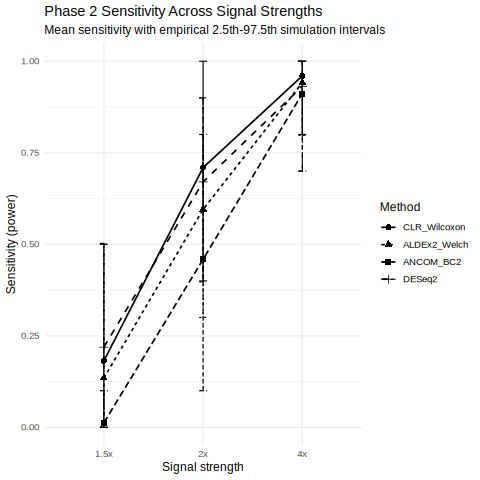

In [12]:
%%R

# Cell 8G — Sensitivity / power figure across signal strength

# Purpose:
#   Plot mean sensitivity versus signal strength for the four DA methods using
#   the Phase 2 repeated-simulation summary.

# Error bars:
#   Empirical 2.5th and 97.5th percentiles across simulations
#   (simulation interval, not a confidence interval).

# 1. Load summary table if needed
if (!exists("phase2_summary_8F")) {

  phase2_summary_rds_8G <- file.path(
    "/content/drive/MyDrive/BIOT670I/Phase2",
    "phase2_performance_summary_8F.rds"
  )

  if (!file.exists(phase2_summary_rds_8G)) {
    stop(
      "phase2_performance_summary_8F.rds not found. Run/save Cell 8F first."
    )
  }

  phase2_summary_8F <- readRDS(
    phase2_summary_rds_8G
  )

  cat("Loaded phase2_summary_8F from Drive.\n")
}

# 2. Load plotting package
library(ggplot2)

# 3. Prepare plotting data
sensitivity_plot_data_8G <- phase2_summary_8F

sensitivity_plot_data_8G$Method <- factor(
  sensitivity_plot_data_8G$Method,
  levels = c(
    "CLR_Wilcoxon",
    "ALDEx2_Welch",
    "ANCOM_BC2",
    "DESeq2"
  )
)

sensitivity_plot_data_8G$Signal_Label <- factor(
  paste0(sensitivity_plot_data_8G$Signal_FC, "x"),
  levels = c("1.5x", "2x", "4x")
)

# 4. Create sensitivity plot
phase2_sensitivity_plot_8G <- ggplot(
  sensitivity_plot_data_8G,
  aes(
    x = Signal_Label,
    y = Sensitivity_Mean,
    group = Method,
    linetype = Method,
    shape = Method
  )
) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2.5) +
  geom_errorbar(
    aes(
      ymin = Sensitivity_P2.5,
      ymax = Sensitivity_P97.5
    ),
    width = 0.08
  ) +
  labs(
    title = "Phase 2 Sensitivity Across Signal Strengths",
    subtitle = "Mean sensitivity with empirical 2.5th-97.5th simulation intervals",
    x = "Signal strength",
    y = "Sensitivity (power)",
    linetype = "Method",
    shape = "Method"
  ) +
  coord_cartesian(
    ylim = c(0, 1)
  ) +
  theme_minimal(base_size = 12)

# 5. Display plot
print(phase2_sensitivity_plot_8G)

# 6. Save figure to Google Drive
phase2_sensitivity_png_8G <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_sensitivity_plot_8G.png"
)

phase2_sensitivity_pdf_8G <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_sensitivity_plot_8G.pdf"
)

ggsave(
  filename = phase2_sensitivity_png_8G,
  plot = phase2_sensitivity_plot_8G,
  width = 8,
  height = 5,
  dpi = 300
)

ggsave(
  filename = phase2_sensitivity_pdf_8G,
  plot = phase2_sensitivity_plot_8G,
  width = 8,
  height = 5
)

cat("\nCell 8G completed successfully.\n")
cat("Saved PNG to:\n", phase2_sensitivity_png_8G, "\n")
cat("Saved PDF to:\n", phase2_sensitivity_pdf_8G, "\n")


=== EMPIRICAL FDR VALUES USED IN FIGURE ===

 Signal_FC       Method FDR_Mean
       1.5 CLR_Wilcoxon  0.02450
       1.5 ALDEx2_Welch  0.01558
       1.5    ANCOM_BC2  0.06333
       1.5       DESeq2  0.06644
       2.0 CLR_Wilcoxon  0.04396
       2.0 ALDEx2_Welch  0.01318
       2.0    ANCOM_BC2  0.05220
       2.0       DESeq2  0.06955
       4.0 CLR_Wilcoxon  0.06130
       4.0 ALDEx2_Welch  0.01293
       4.0    ANCOM_BC2  0.04739
       4.0       DESeq2  0.08400

Cell 8H completed successfully.
Saved PNG to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_empirical_FDR_plot_8H.png 
Saved PDF to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_empirical_FDR_plot_8H.pdf 


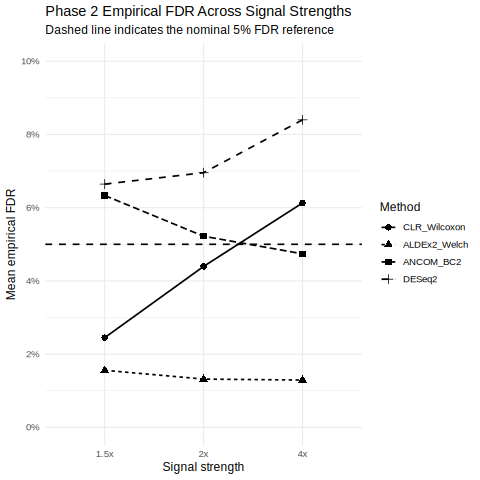

In [13]:
%%R

# Cell 8H — Empirical FDR across signal strength

# Purpose:
#   Plot mean empirical false discovery rate (FDR) for each differential-abundance
#   method across the three planted signal strengths.

# Reference: Horizontal dashed line at nominal FDR = 0.05.

# IMPORTANT: No simulations or DA methods are rerun here.

# 1. Load Phase 2 summary if needed
if (!exists("phase2_summary_8F")) {

  phase2_summary_rds_8H <- file.path(
    "/content/drive/MyDrive/BIOT670I/Phase2",
    "phase2_performance_summary_8F.rds"
  )

  if (!file.exists(phase2_summary_rds_8H)) {
    stop(
      "phase2_performance_summary_8F.rds not found. Run/save Cell 8F first."
    )
  }

  phase2_summary_8F <- readRDS(
    phase2_summary_rds_8H
  )

  cat("Loaded phase2_summary_8F from Drive.\n")
}

# 2. Load plotting package
library(ggplot2)

# 3. Prepare plotting data
fdr_plot_data_8H <- phase2_summary_8F

fdr_plot_data_8H$Method <- factor(
  fdr_plot_data_8H$Method,
  levels = c(
    "CLR_Wilcoxon",
    "ALDEx2_Welch",
    "ANCOM_BC2",
    "DESeq2"
  )
)

fdr_plot_data_8H$Signal_Label <- factor(
  paste0(fdr_plot_data_8H$Signal_FC, "x"),
  levels = c(
    "1.5x",
    "2x",
    "4x"
  )
)

# 4. Create empirical FDR plot
phase2_fdr_plot_8H <- ggplot(
  fdr_plot_data_8H,
  aes(
    x = Signal_Label,
    y = FDR_Mean,
    group = Method,
    linetype = Method,
    shape = Method
  )
) +

  # Nominal 5% FDR reference
  geom_hline(
    yintercept = 0.05,
    linetype = "dashed",
    linewidth = 0.8
  ) +

  # Method trajectories
  geom_line(
    linewidth = 0.8
  ) +

  geom_point(
    size = 2.7
  ) +

  # Show FDR as percentages
  scale_y_continuous(
    limits = c(0, 0.10),
    breaks = seq(
      0,
      0.10,
      by = 0.02
    ),
    labels = function(x) {
      paste0(
        round(
          x * 100
        ),
        "%"
      )
    }
  ) +

  labs(
    title = "Phase 2 Empirical FDR Across Signal Strengths",
    subtitle = "Dashed line indicates the nominal 5% FDR reference",
    x = "Signal strength",
    y = "Mean empirical FDR",
    linetype = "Method",
    shape = "Method"
  ) +

  theme_minimal(
    base_size = 12
  )

# 5. Display figure
print(phase2_fdr_plot_8H)

# 6. Save figure to Google Drive
phase2_fdr_png_8H <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_empirical_FDR_plot_8H.png"
)

phase2_fdr_pdf_8H <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_empirical_FDR_plot_8H.pdf"
)

ggsave(
  filename = phase2_fdr_png_8H,
  plot = phase2_fdr_plot_8H,
  width = 8,
  height = 5,
  dpi = 300
)

ggsave(
  filename = phase2_fdr_pdf_8H,
  plot = phase2_fdr_plot_8H,
  width = 8,
  height = 5
)

# 7. Print numerical values used in the figure
cat("\n=== EMPIRICAL FDR VALUES USED IN FIGURE ===\n\n")

fdr_display_8H <- fdr_plot_data_8H[
  ,
  c(
    "Signal_FC",
    "Method",
    "FDR_Mean"
  )
]

fdr_display_8H <- fdr_display_8H[
  order(
    fdr_display_8H$Signal_FC,
    fdr_display_8H$Method
  ),
]

print(
  fdr_display_8H,
  row.names = FALSE,
  digits = 4
)

cat("\nCell 8H completed successfully.\n")

cat(
  "Saved PNG to:\n",
  phase2_fdr_png_8H,
  "\n"
)

cat(
  "Saved PDF to:\n",
  phase2_fdr_pdf_8H,
  "\n"
)


=== COMBINED PHASE 2 VALUES USED IN FIGURE ===

 Signal_FC       Method Sensitivity_Mean FDR_Mean
       1.5 CLR_Wilcoxon           0.1815  0.02450
       1.5 ALDEx2_Welch           0.1345  0.01558
       1.5    ANCOM_BC2           0.0125  0.06333
       1.5       DESeq2           0.2190  0.06644
       2.0 CLR_Wilcoxon           0.7095  0.04396
       2.0 ALDEx2_Welch           0.5955  0.01318
       2.0    ANCOM_BC2           0.4590  0.05220
       2.0       DESeq2           0.6705  0.06955
       4.0 CLR_Wilcoxon           0.9600  0.06130
       4.0 ALDEx2_Welch           0.9415  0.01293
       4.0    ANCOM_BC2           0.9115  0.04739
       4.0       DESeq2           0.9315  0.08400

Cell 8I completed successfully.
Saved PNG to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_combined_performance_plot_8I.png 
Saved PDF to:
 /content/drive/MyDrive/BIOT670I/Phase2/phase2_combined_performance_plot_8I.pdf 


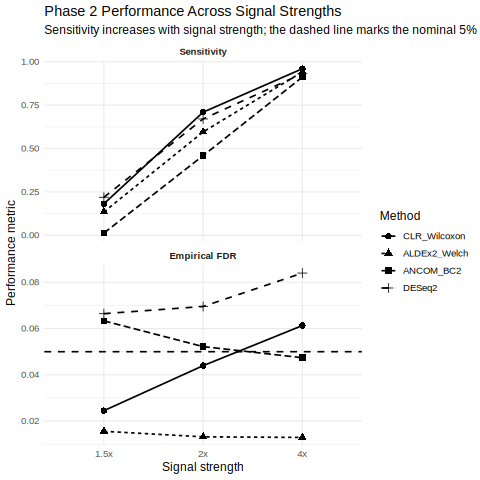

In [14]:
%%R

# Cell 8I — Combined Phase 2 performance figure

# Purpose:
#   Combine the two primary Phase 2 performance metrics into
#   one figure:
#     1. Mean sensitivity (power)
#     2. Mean empirical FDR

#   The empirical FDR panel includes the nominal 0.05 reference line.

# IMPORTANT: No simulations or DA methods are rerun here.

# 1. Load Phase 2 summary if needed
if (!exists("phase2_summary_8F")) {

  phase2_summary_rds_8I <- file.path(
    "/content/drive/MyDrive/BIOT670I/Phase2",
    "phase2_performance_summary_8F.rds"
  )

  if (!file.exists(phase2_summary_rds_8I)) {
    stop(
      "phase2_performance_summary_8F.rds not found. Run/save Cell 8F first."
    )
  }

  phase2_summary_8F <- readRDS(
    phase2_summary_rds_8I
  )

  cat("Loaded phase2_summary_8F from Drive.\n")
}

# 2. Load plotting package
library(ggplot2)

# 3. Standardize method order
method_order_8I <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

phase2_summary_8F$Method <- factor(
  phase2_summary_8F$Method,
  levels = method_order_8I
)

# 4. Build long-format plotting table
sensitivity_data_8I <- data.frame(
  Signal_FC = phase2_summary_8F$Signal_FC,
  Method = phase2_summary_8F$Method,
  Metric = "Sensitivity",
  Value = phase2_summary_8F$Sensitivity_Mean,
  stringsAsFactors = FALSE
)

fdr_data_8I <- data.frame(
  Signal_FC = phase2_summary_8F$Signal_FC,
  Method = phase2_summary_8F$Method,
  Metric = "Empirical FDR",
  Value = phase2_summary_8F$FDR_Mean,
  stringsAsFactors = FALSE
)

combined_plot_data_8I <- rbind(
  sensitivity_data_8I,
  fdr_data_8I
)

combined_plot_data_8I$Method <- factor(
  combined_plot_data_8I$Method,
  levels = method_order_8I
)

combined_plot_data_8I$Metric <- factor(
  combined_plot_data_8I$Metric,
  levels = c(
    "Sensitivity",
    "Empirical FDR"
  )
)

combined_plot_data_8I$Signal_Label <- factor(
  paste0(
    combined_plot_data_8I$Signal_FC,
    "x"
  ),
  levels = c(
    "1.5x",
    "2x",
    "4x"
  )
)

# 5. Data for FDR reference line
fdr_reference_data_8I <- data.frame(
  Metric = factor(
    "Empirical FDR",
    levels = c(
      "Sensitivity",
      "Empirical FDR"
    )
  ),
  Reference = 0.05
)

# 6. Create combined figure
phase2_combined_plot_8I <- ggplot(
  combined_plot_data_8I,
  aes(
    x = Signal_Label,
    y = Value,
    group = Method,
    linetype = Method,
    shape = Method
  )
) +

  # Method trajectories
  geom_line(
    linewidth = 0.8
  ) +

  geom_point(
    size = 2.7
  ) +

  # 5% reference line only in the empirical FDR panel
  geom_hline(
    data = fdr_reference_data_8I,
    aes(
      yintercept = Reference
    ),
    inherit.aes = FALSE,
    linetype = "dashed",
    linewidth = 0.8
  ) +

  # Separate panels with their own y-axis scales
  facet_wrap(
    ~ Metric,
    ncol = 1,
    scales = "free_y"
  ) +

  labs(
    title = "Phase 2 Performance Across Signal Strengths",
    subtitle = paste(
      "Sensitivity increases with signal strength;",
      "the dashed line marks the nominal 5% FDR reference"
    ),
    x = "Signal strength",
    y = "Performance metric",
    linetype = "Method",
    shape = "Method"
  ) +

  theme_minimal(
    base_size = 12
  ) +

  theme(
    strip.text = element_text(
      face = "bold"
    ),
    legend.position = "right"
  )

# 7. Display figure
print(phase2_combined_plot_8I)

# 8. Save figure to Google Drive
phase2_combined_png_8I <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_combined_performance_plot_8I.png"
)

phase2_combined_pdf_8I <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_combined_performance_plot_8I.pdf"
)

ggsave(
  filename = phase2_combined_png_8I,
  plot = phase2_combined_plot_8I,
  width = 8,
  height = 8,
  dpi = 300
)

ggsave(
  filename = phase2_combined_pdf_8I,
  plot = phase2_combined_plot_8I,
  width = 8,
  height = 8
)

# 9. Print combined values used in figure
cat("\n=== COMBINED PHASE 2 VALUES USED IN FIGURE ===\n\n")

combined_display_8I <- phase2_summary_8F[
  ,
  c(
    "Signal_FC",
    "Method",
    "Sensitivity_Mean",
    "FDR_Mean"
  )
]

combined_display_8I <- combined_display_8I[
  order(
    combined_display_8I$Signal_FC,
    combined_display_8I$Method
  ),
]

print(
  combined_display_8I,
  row.names = FALSE,
  digits = 4
)

cat("\nCell 8I completed successfully.\n")

cat(
  "Saved PNG to:\n",
  phase2_combined_png_8I,
  "\n"
)

cat(
  "Saved PDF to:\n",
  phase2_combined_pdf_8I,
  "\n"
)

In [15]:
%%R

# Cell 8J - Phase 2 interpretation and final summary

# Purpose:
#   1. Summarize the main Phase 2 findings.
#   2. Compare sensitivity, empirical FDR, and F1 across signal strengths.
#   3. Generate a concise report-ready interpretation.
#   4. Save the interpretation to Google Drive.
#
# IMPORTANT: No simulations or DA methods are rerun here.

# 1. Load Phase 2 summary if needed
if (!exists("phase2_summary_8F")) {

  phase2_summary_rds_8J <- file.path(
    "/content/drive/MyDrive/BIOT670I/Phase2",
    "phase2_performance_summary_8F.rds"
  )

  if (!file.exists(phase2_summary_rds_8J)) {
    stop(
      "phase2_performance_summary_8F.rds not found. Run/save Cell 8F first."
    )
  }

  phase2_summary_8F <- readRDS(
    phase2_summary_rds_8J
  )

  cat("Loaded phase2_summary_8F from Drive.\n")
}

# 2. Validate columns needed for interpretation
required_columns_8J <- c(
  "Signal_FC",
  "Method",
  "Successful_Runs",
  "Mean_TP",
  "Mean_FP",
  "Sensitivity_Mean",
  "FDR_Mean",
  "Precision_Mean",
  "Specificity_Mean",
  "F1_Mean"
)

missing_columns_8J <- setdiff(
  required_columns_8J,
  colnames(phase2_summary_8F)
)

if (length(missing_columns_8J) > 0) {
  stop(
    paste(
      "Missing required columns:",
      paste(
        missing_columns_8J,
        collapse = ", "
      )
    )
  )
}

# 3. Method and signal order
method_order_8J <- c(
  "CLR_Wilcoxon",
  "ALDEx2_Welch",
  "ANCOM_BC2",
  "DESeq2"
)

signal_order_8J <- c(
  1.5,
  2,
  4
)

phase2_summary_8J <- phase2_summary_8F

phase2_summary_8J$Method <- factor(
  phase2_summary_8J$Method,
  levels = method_order_8J
)

phase2_summary_8J <- phase2_summary_8J[
  order(
    phase2_summary_8J$Signal_FC,
    phase2_summary_8J$Method
  ),
]

# 4. Display final numerical summary
cat("=== PHASE 2 FINAL PERFORMANCE SUMMARY ===\n\n")

final_display_8J <- phase2_summary_8J[
  ,
  c(
    "Signal_FC",
    "Method",
    "Sensitivity_Mean",
    "FDR_Mean",
    "Precision_Mean",
    "Specificity_Mean",
    "F1_Mean"
  )
]

print(
  final_display_8J,
  row.names = FALSE,
  digits = 4
)

# 5. Identify descriptive highlights
# These are descriptive summaries only.
# They are not intended to identify a universal best method.
# ------------------------------------------------------------
cat("\n=== DESCRIPTIVE HIGHLIGHTS BY SIGNAL STRENGTH ===\n\n")

highlight_rows_8J <- list()

for (fc_8J in signal_order_8J) {

  tmp_8J <- phase2_summary_8J[
    phase2_summary_8J$Signal_FC == fc_8J,
  ]

  highest_sensitivity_8J <-
    as.character(
      tmp_8J$Method[
        which.max(
          tmp_8J$Sensitivity_Mean
        )
      ]
    )

  lowest_fdr_8J <-
    as.character(
      tmp_8J$Method[
        which.min(
          tmp_8J$FDR_Mean
        )
      ]
    )

  highest_f1_8J <-
    as.character(
      tmp_8J$Method[
        which.max(
          tmp_8J$F1_Mean
        )
      ]
    )

  highlight_rows_8J[[length(highlight_rows_8J) + 1L]] <-
    data.frame(
      Signal_FC = fc_8J,
      Highest_Sensitivity = highest_sensitivity_8J,
      Lowest_Mean_FDR = lowest_fdr_8J,
      Highest_F1 = highest_f1_8J,
      stringsAsFactors = FALSE
    )
}

phase2_highlights_8J <- do.call(
  rbind,
  highlight_rows_8J
)

print(
  phase2_highlights_8J,
  row.names = FALSE
)

# 6. Extract exact values for report-ready interpretation
get_metric_8J <- function(
  signal,
  method,
  metric
) {

  value_8J <- phase2_summary_8J[
    phase2_summary_8J$Signal_FC == signal &
      as.character(
        phase2_summary_8J$Method
      ) == method,
    metric
  ]

  as.numeric(
    value_8J[1]
  )
}

# Sensitivity values
clr_sens_1_5_8J <-
  get_metric_8J(
    1.5,
    "CLR_Wilcoxon",
    "Sensitivity_Mean"
  )

clr_sens_2_8J <-
  get_metric_8J(
    2,
    "CLR_Wilcoxon",
    "Sensitivity_Mean"
  )

clr_sens_4_8J <-
  get_metric_8J(
    4,
    "CLR_Wilcoxon",
    "Sensitivity_Mean"
  )

aldex_sens_1_5_8J <-
  get_metric_8J(
    1.5,
    "ALDEx2_Welch",
    "Sensitivity_Mean"
  )

aldex_sens_2_8J <-
  get_metric_8J(
    2,
    "ALDEx2_Welch",
    "Sensitivity_Mean"
  )

aldex_sens_4_8J <-
  get_metric_8J(
    4,
    "ALDEx2_Welch",
    "Sensitivity_Mean"
  )


ancom_sens_1_5_8J <-
  get_metric_8J(
    1.5,
    "ANCOM_BC2",
    "Sensitivity_Mean"
  )

ancom_sens_2_8J <-
  get_metric_8J(
    2,
    "ANCOM_BC2",
    "Sensitivity_Mean"
  )

ancom_sens_4_8J <-
  get_metric_8J(
    4,
    "ANCOM_BC2",
    "Sensitivity_Mean"
  )


deseq_sens_1_5_8J <-
  get_metric_8J(
    1.5,
    "DESeq2",
    "Sensitivity_Mean"
  )

deseq_sens_2_8J <-
  get_metric_8J(
    2,
    "DESeq2",
    "Sensitivity_Mean"
  )

deseq_sens_4_8J <-
  get_metric_8J(
    4,
    "DESeq2",
    "Sensitivity_Mean"
  )

# FDR values
clr_fdr_1_5_8J <-
  get_metric_8J(
    1.5,
    "CLR_Wilcoxon",
    "FDR_Mean"
  )

clr_fdr_2_8J <-
  get_metric_8J(
    2,
    "CLR_Wilcoxon",
    "FDR_Mean"
  )

clr_fdr_4_8J <-
  get_metric_8J(
    4,
    "CLR_Wilcoxon",
    "FDR_Mean"
  )

aldex_fdr_1_5_8J <-
  get_metric_8J(
    1.5,
    "ALDEx2_Welch",
    "FDR_Mean"
  )

aldex_fdr_2_8J <-
  get_metric_8J(
    2,
    "ALDEx2_Welch",
    "FDR_Mean"
  )

aldex_fdr_4_8J <-
  get_metric_8J(
    4,
    "ALDEx2_Welch",
    "FDR_Mean"
  )

ancom_fdr_1_5_8J <-
  get_metric_8J(
    1.5,
    "ANCOM_BC2",
    "FDR_Mean"
  )

ancom_fdr_2_8J <-
  get_metric_8J(
    2,
    "ANCOM_BC2",
    "FDR_Mean"
  )

ancom_fdr_4_8J <-
  get_metric_8J(
    4,
    "ANCOM_BC2",
    "FDR_Mean"
  )

deseq_fdr_1_5_8J <-
  get_metric_8J(
    1.5,
    "DESeq2",
    "FDR_Mean"
  )

deseq_fdr_2_8J <-
  get_metric_8J(
    2,
    "DESeq2",
    "FDR_Mean"
  )

deseq_fdr_4_8J <-
  get_metric_8J(
    4,
    "DESeq2",
    "FDR_Mean"
  )

# 7. Generate report-ready interpretation
interpretation_8J <- sprintf(
paste0(
"PHASE 2 INTERPRETATION\n\n",

"Repeated simulations showed that signal strength had a strong ",
"effect on differential-abundance detection. Mean sensitivity ",
"increased from the 1.5x condition to the 2x condition and again ",
"to the 4x condition for all four methods. CLR/Wilcoxon increased ",
"from %.3f to %.3f to %.3f, ALDEx2 Welch increased from %.3f to ",
"%.3f to %.3f, ANCOM-BC2 increased from %.3f to %.3f to %.3f, ",
"and DESeq2 increased from %.3f to %.3f to %.3f. At the strongest ",
"4x signal, all four methods achieved mean sensitivity above 0.90.\n\n",

"The methods differed more clearly in their false-discovery ",
"behavior. ALDEx2 Welch had mean empirical FDR values of %.3f, ",
"%.3f, and %.3f at 1.5x, 2x, and 4x, respectively, remaining ",
"below the nominal 0.05 reference in all three conditions. ",
"CLR/Wilcoxon had corresponding mean FDR values of %.3f, %.3f, ",
"and %.3f, with the 4x condition modestly above 0.05. ANCOM-BC2 ",
"had mean FDR values of %.3f, %.3f, and %.3f and remained close ",
"to the 0.05 reference overall. DESeq2 had mean FDR values of ",
"%.3f, %.3f, and %.3f, which were above 0.05 at each signal ",
"strength in these simulations.\n\n",

"The combined results illustrate a sensitivity versus ",
"false-discovery trade-off rather than a single method dominating ",
"under every condition. At weak signal, DESeq2 showed relatively ",
"high sensitivity but also higher mean empirical FDR, while ",
"ALDEx2 was more conservative and had lower sensitivity. ",
"ANCOM-BC2 showed very low sensitivity at the weakest 1.5x signal ",
"but improved substantially as the planted effect increased. ",
"CLR/Wilcoxon showed strong sensitivity at moderate and strong ",
"signals, while its mean empirical FDR increased with signal ",
"strength. These findings emphasize that method performance ",
"depends on signal strength and on the balance between detecting ",
"true differential taxa and limiting false discoveries.\n\n",

"These comparisons are descriptive summaries of the simulated ",
"conditions used in this project and should not be interpreted ",
"as evidence that one method is universally superior."
),
clr_sens_1_5_8J,
clr_sens_2_8J,
clr_sens_4_8J,

aldex_sens_1_5_8J,
aldex_sens_2_8J,
aldex_sens_4_8J,

ancom_sens_1_5_8J,
ancom_sens_2_8J,
ancom_sens_4_8J,

deseq_sens_1_5_8J,
deseq_sens_2_8J,
deseq_sens_4_8J,

aldex_fdr_1_5_8J,
aldex_fdr_2_8J,
aldex_fdr_4_8J,

clr_fdr_1_5_8J,
clr_fdr_2_8J,
clr_fdr_4_8J,

ancom_fdr_1_5_8J,
ancom_fdr_2_8J,
ancom_fdr_4_8J,

deseq_fdr_1_5_8J,
deseq_fdr_2_8J,
deseq_fdr_4_8J
)

# 8. Print interpretation
cat("\n=== REPORT-READY PHASE 2 INTERPRETATION ===\n\n")

cat(
  interpretation_8J,
  "\n"
)

# 9. Save interpretation to Google Drive
phase2_interpretation_file_8J <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_interpretation_8J.txt"
)

writeLines(
  interpretation_8J,
  con = phase2_interpretation_file_8J
)

# 10. Save descriptive highlights
phase2_highlights_file_8J <- file.path(
  "/content/drive/MyDrive/BIOT670I/Phase2",
  "phase2_descriptive_highlights_8J.csv"
)

write.csv(
  phase2_highlights_8J,
  phase2_highlights_file_8J,
  row.names = FALSE
)

# 11. Completion message
cat("\n\nCell 8J completed successfully.\n")

cat(
  "Interpretation saved to:\n",
  phase2_interpretation_file_8J,
  "\n"
)

cat(
  "Descriptive highlights saved to:\n",
  phase2_highlights_file_8J,
  "\n"
)

cat("\nSection 8 is complete.\n")

=== PHASE 2 FINAL PERFORMANCE SUMMARY ===

 Signal_FC       Method Sensitivity_Mean FDR_Mean Precision_Mean
       1.5 CLR_Wilcoxon           0.1815  0.02450         0.9657
       1.5 ALDEx2_Welch           0.1345  0.01558         0.9779
       1.5    ANCOM_BC2           0.0125  0.06333         0.6162
       1.5       DESeq2           0.2190  0.06644         0.9209
       2.0 CLR_Wilcoxon           0.7095  0.04396         0.9560
       2.0 ALDEx2_Welch           0.5955  0.01318         0.9868
       2.0    ANCOM_BC2           0.4590  0.05220         0.9470
       2.0       DESeq2           0.6705  0.06955         0.9304
       4.0 CLR_Wilcoxon           0.9600  0.06130         0.9387
       4.0 ALDEx2_Welch           0.9415  0.01293         0.9871
       4.0    ANCOM_BC2           0.9115  0.04739         0.9526
       4.0       DESeq2           0.9315  0.08400         0.9160
 Specificity_Mean F1_Mean
           0.9990 0.27330
           0.9996 0.21525
           0.9991 0.02198
        